In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import os
from matplotlib.ticker import FuncFormatter
from scipy.stats import skew, kurtosis
from sklearn.metrics import r2_score
import seaborn as sns

In [5]:


# Define the file path pattern (adjust if needed)
base_path = r"C:\Users\phani\Desktop\Gamma Capture\Data"

# List to store DataFrames
data_frames = []

# Loop through years 2012 to 2021
for year in range(2012, 2022):
    file_path = os.path.join(base_path, f'DAT_ASCII_EURUSD_M1_{year}.csv')
    
    # Read CSV file (adjust parameters if needed)
    df = pd.read_csv(file_path, header=None, sep=';')
    
    # Append to list
    data_frames.append(df)

# Concatenate all DataFrames into one
data = pd.concat(data_frames, ignore_index=True)

# Display first few rows to confirm
print(data.head())

                 0        1        2        3        4  5
0  20120102 020000  1.29324  1.29381  1.29324  1.29332  0
1  20120102 020100  1.29326  1.29345  1.29275  1.29341  0
2  20120102 020200  1.29342  1.29344  1.29341  1.29343  0
3  20120102 020300  1.29342  1.29342  1.29335  1.29336  0
4  20120102 020400  1.29324  1.29347  1.29320  1.29346  0


In [6]:
print(data.tail())

                       0        1        2        3        4  5
3712742  20211231 165400  1.13797  1.13797  1.13774  1.13774  0
3712743  20211231 165500  1.13775  1.13781  1.13748  1.13748  0
3712744  20211231 165600  1.13749  1.13765  1.13704  1.13707  0
3712745  20211231 165700  1.13709  1.13740  1.13679  1.13740  0
3712746  20211231 165800  1.13740  1.13740  1.13681  1.13686  0


In [7]:
data.shape

(3712747, 6)

In [8]:
# Rename columns for clarity
data.columns = ['DateTime', 'Open', 'High', 'Low', 'Close', 'Volume']
print(data.head())

          DateTime     Open     High      Low    Close  Volume
0  20120102 020000  1.29324  1.29381  1.29324  1.29332       0
1  20120102 020100  1.29326  1.29345  1.29275  1.29341       0
2  20120102 020200  1.29342  1.29344  1.29341  1.29343       0
3  20120102 020300  1.29342  1.29342  1.29335  1.29336       0
4  20120102 020400  1.29324  1.29347  1.29320  1.29346       0


In [9]:
# Convert 'DateTime' to datetime format
data['DateTime'] = pd.to_datetime(data['DateTime'], format='%Y%m%d %H%M%S')
print(data.head())

             DateTime     Open     High      Low    Close  Volume
0 2012-01-02 02:00:00  1.29324  1.29381  1.29324  1.29332       0
1 2012-01-02 02:01:00  1.29326  1.29345  1.29275  1.29341       0
2 2012-01-02 02:02:00  1.29342  1.29344  1.29341  1.29343       0
3 2012-01-02 02:03:00  1.29342  1.29342  1.29335  1.29336       0
4 2012-01-02 02:04:00  1.29324  1.29347  1.29320  1.29346       0


In [10]:
#Checking for duplicate timestamps
counts = data['DateTime'].value_counts()
print(counts[counts > 1])

DateTime
2019-10-27 19:00:00    2
2019-10-27 19:01:00    2
2019-10-27 19:02:00    2
2019-10-27 19:03:00    2
2019-10-27 19:04:00    2
                      ..
2021-10-31 19:55:00    2
2021-10-31 19:56:00    2
2021-10-31 19:57:00    2
2021-10-31 19:58:00    2
2021-10-31 19:59:00    2
Name: count, Length: 180, dtype: int64


In [11]:
# 1) Make a boolean mask for every duplicated timestamp (marking all occurrences)
dup_mask = data['DateTime'].duplicated(keep=False)

# 2) Subset and sort so we see each duplicated group in one place
dupe_rows = data.loc[dup_mask].sort_values('DateTime')

print(dupe_rows)

                   DateTime     Open     High      Low    Close  Volume
2904338 2019-10-27 19:00:00  1.10839  1.10844  1.10836  1.10836       0
2904398 2019-10-27 19:00:00  1.10839  1.10844  1.10836  1.10836       0
2904339 2019-10-27 19:01:00  1.10837  1.10837  1.10826  1.10826       0
2904399 2019-10-27 19:01:00  1.10837  1.10837  1.10826  1.10826       0
2904340 2019-10-27 19:02:00  1.10826  1.10826  1.10822  1.10822       0
...                     ...      ...      ...      ...      ...     ...
3648533 2021-10-31 19:57:00  1.15526  1.15526  1.15518  1.15520       0
3648594 2021-10-31 19:58:00  1.15520  1.15545  1.15518  1.15545       0
3648534 2021-10-31 19:58:00  1.15520  1.15545  1.15518  1.15545       0
3648535 2021-10-31 19:59:00  1.15545  1.15555  1.15543  1.15551       0
3648595 2021-10-31 19:59:00  1.15545  1.15555  1.15543  1.15551       0

[360 rows x 6 columns]


In [12]:
# Setting DateTime to index
data.set_index('DateTime', inplace=True)
print(data.head())

                        Open     High      Low    Close  Volume
DateTime                                                       
2012-01-02 02:00:00  1.29324  1.29381  1.29324  1.29332       0
2012-01-02 02:01:00  1.29326  1.29345  1.29275  1.29341       0
2012-01-02 02:02:00  1.29342  1.29344  1.29341  1.29343       0
2012-01-02 02:03:00  1.29342  1.29342  1.29335  1.29336       0
2012-01-02 02:04:00  1.29324  1.29347  1.29320  1.29346       0


In [13]:
# Ensure 'DateTime' is the index
data.index = pd.to_datetime(data.index)

# Generate a full range of 1-minute timestamps
full_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='1min')
full_range

DatetimeIndex(['2012-01-02 02:00:00', '2012-01-02 02:01:00',
               '2012-01-02 02:02:00', '2012-01-02 02:03:00',
               '2012-01-02 02:04:00', '2012-01-02 02:05:00',
               '2012-01-02 02:06:00', '2012-01-02 02:07:00',
               '2012-01-02 02:08:00', '2012-01-02 02:09:00',
               ...
               '2021-12-31 16:49:00', '2021-12-31 16:50:00',
               '2021-12-31 16:51:00', '2021-12-31 16:52:00',
               '2021-12-31 16:53:00', '2021-12-31 16:54:00',
               '2021-12-31 16:55:00', '2021-12-31 16:56:00',
               '2021-12-31 16:57:00', '2021-12-31 16:58:00'],
              dtype='datetime64[ns]', length=5258339, freq='min')

In [14]:
# Find missing timestamps
missing_timestamps = full_range.difference(data.index)   # Identifies missing timestamps

# Display missing timestamps
print(f"Missing Timestamps:\n{missing_timestamps}")

Missing Timestamps:
DatetimeIndex(['2012-01-02 09:24:00', '2012-01-02 10:41:00',
               '2012-01-02 12:29:00', '2012-01-02 12:32:00',
               '2012-01-02 12:34:00', '2012-01-02 12:36:00',
               '2012-01-02 12:45:00', '2012-01-02 13:08:00',
               '2012-01-02 13:15:00', '2012-01-02 13:16:00',
               ...
               '2021-12-30 23:48:00', '2021-12-31 00:25:00',
               '2021-12-31 00:43:00', '2021-12-31 00:48:00',
               '2021-12-31 00:52:00', '2021-12-31 01:58:00',
               '2021-12-31 02:17:00', '2021-12-31 13:43:00',
               '2021-12-31 14:07:00', '2021-12-31 14:36:00'],
              dtype='datetime64[ns]', length=1545772, freq=None)


In [15]:
# All missing timestamps (including weekends)
missing_timestamps.shape   

(1545772,)

In [16]:
# Convert missing timestamps to a DataFrame
missing_df = pd.DataFrame(missing_timestamps, columns=['DateTime'])

#marking every row as 1 by creating new column - indicator
missing_df['indicator'] = 1
missing_df

,DateTime,indicator
0,2012-01-02 09:24:00,1
1,2012-01-02 10:41:00,1
2,2012-01-02 12:29:00,1
3,2012-01-02 12:32:00,1
4,2012-01-02 12:34:00,1
...,...,...
1545767,2021-12-31 01:58:00,1
1545768,2021-12-31 02:17:00,1
1545769,2021-12-31 13:43:00,1
1545770,2021-12-31 14:07:00,1


In [17]:
# Generate a complete time range with 1-minute frequency
# Instead of data['DateTime'], use data.index to access the DateTime values
full_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='min')

In [18]:
# Create a dataframe from the complete time range
complete_df = pd.DataFrame(full_range, columns=['DateTime'])

# Merge the original dataframe with the complete time range
combined_df = pd.merge(complete_df, data, on='DateTime', how='left')
combined_df['indicator'] = pd.NA
combined_df

,DateTime,Open,High,Low,Close,Volume,indicator
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,<NA>
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,<NA>
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,<NA>
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,<NA>
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,<NA>
...,...,...,...,...,...,...,...
5258514,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,<NA>
5258515,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,<NA>
5258516,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,<NA>
5258517,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,<NA>


In [19]:
# Fill the 'indicator' column: 0 for non-missing, 1 for missing
combined_df['indicator'] = combined_df['Close'].isna().astype(int)

# Sort by DateTime (optional)
combined_df = combined_df.sort_values(by='DateTime').reset_index(drop=True)
combined_df

,DateTime,Open,High,Low,Close,Volume,indicator
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,0
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,0
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,0
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,0
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,0
...,...,...,...,...,...,...,...
5258514,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,0
5258515,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,0
5258516,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,0
5258517,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,0


In [20]:
# Count 1's in indicator column
count_ones = combined_df['indicator'].sum()
print(f"Number of 1's in indicator column: {count_ones}")


Number of 1's in indicator column: 1545772


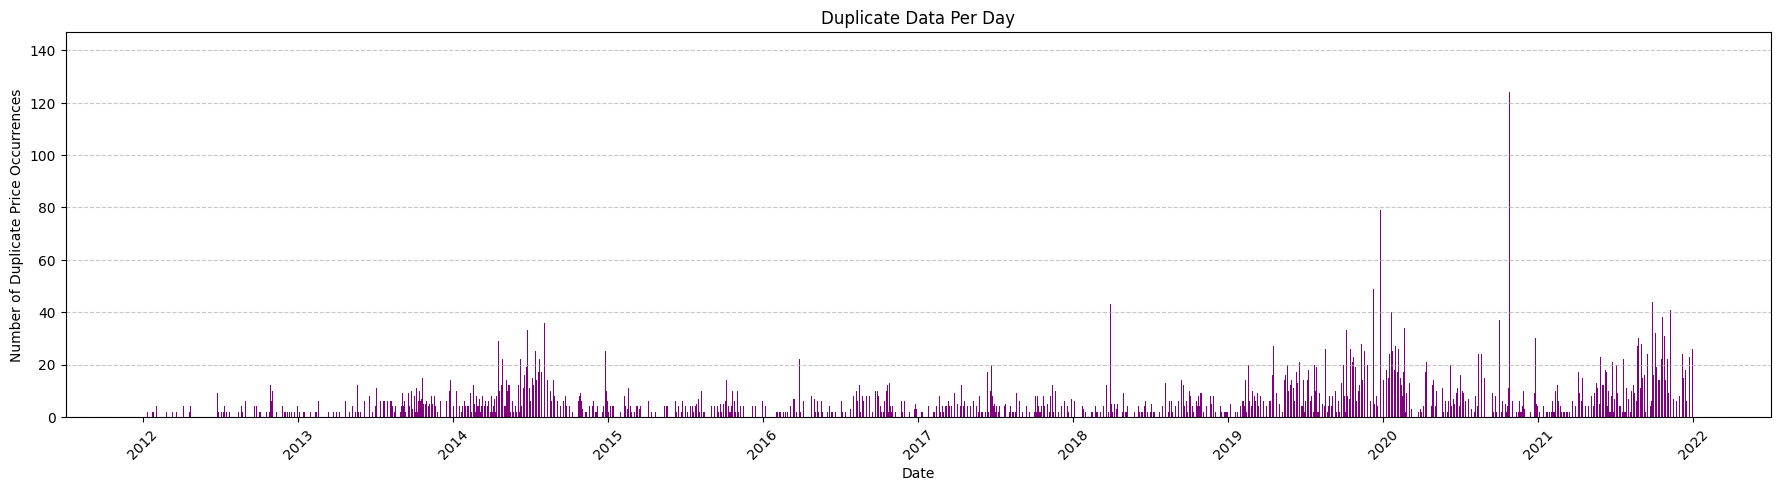

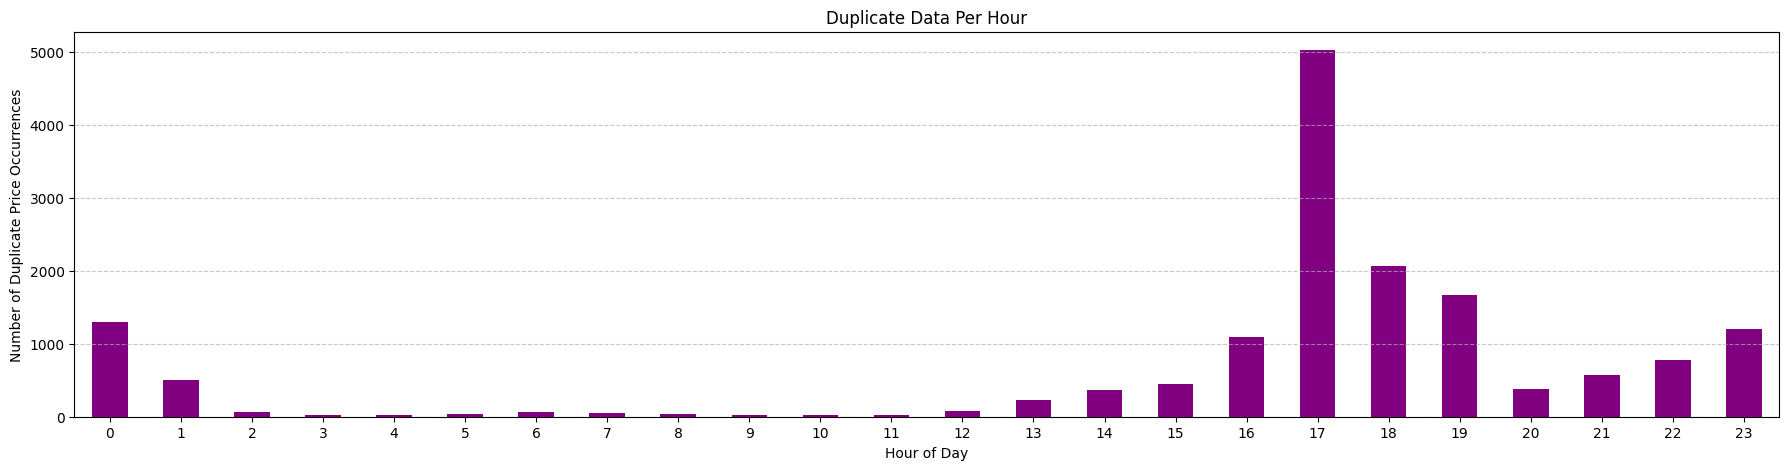

In [21]:
# Ensure DateTime is in datetime format
combined_df['DateTime'] = pd.to_datetime(combined_df['DateTime'])

# Identify duplicated consecutive OHLC prices
dup_consecutive = combined_df[['Open', 'High', 'Low', 'Close']].eq(combined_df[['Open', 'High', 'Low', 'Close']].shift(-1)).all(axis=1) | \
                  combined_df[['Open', 'High', 'Low', 'Close']].eq(combined_df[['Open', 'High', 'Low', 'Close']].shift(1)).all(axis=1)

dup_df = combined_df[dup_consecutive]

# Group duplicate occurrences by date
dup_per_day = dup_df.groupby(dup_df['DateTime'].dt.date).size()

#  Group by hour and count occurrences of duplicate data
dup_per_hour = dup_df.groupby(dup_df['DateTime'].dt.hour).size()

# 
plt.figure(figsize=(22, 5))
plt.bar(dup_per_day.index, dup_per_day.values, color='purple')
plt.title('Duplicate Data Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Duplicate Price Occurrences')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot the bar chart for duplicate data occurrences per hour
plt.figure(figsize=(22, 5))
dup_per_hour.plot(kind='bar', color='purple')
plt.title('Duplicate Data Per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Duplicate Price Occurrences')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

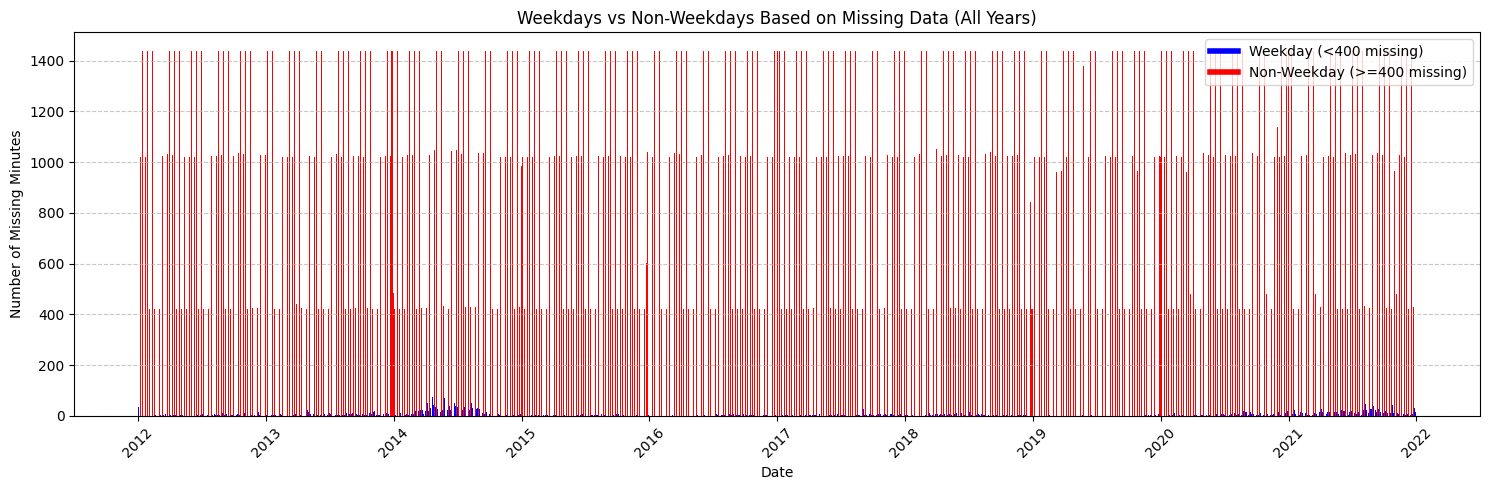

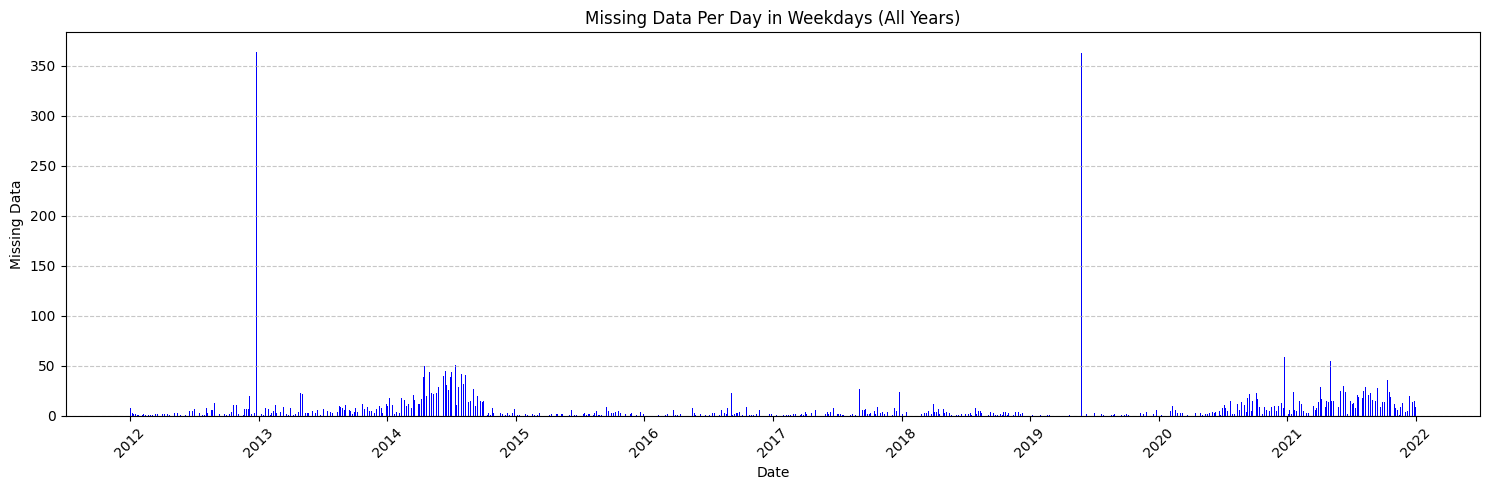

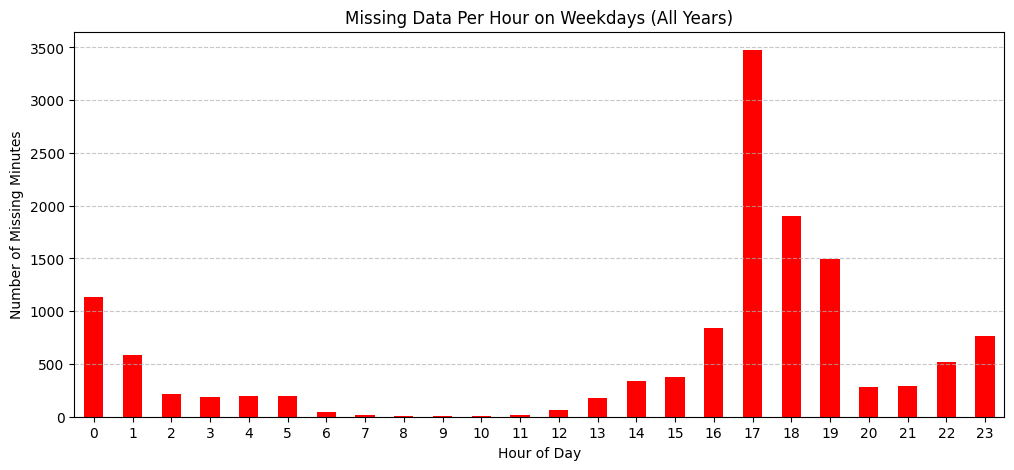

In [22]:
# Ensure DateTime is in datetime format
combined_df['DateTime'] = pd.to_datetime(combined_df['DateTime'])

# Step 1: Group by date and sum the indicator column (missing minutes per day)
missing_per_day = combined_df.groupby(combined_df['DateTime'].dt.date)['indicator'].sum()

# Step 2: Identify weekdays (days with less than 400 missing data)
weekdays = missing_per_day[missing_per_day < 400].index       

# Step 3: Filter the dataframe to include only weekdays
weekday_df = combined_df[combined_df['DateTime'].dt.date.isin(weekdays)]

# Step 4: Group by hour and sum missing data
missing_per_hour_weekdays = weekday_df.groupby(weekday_df['DateTime'].dt.hour)['indicator'].sum()

# Step 5: Add year-wise grouping for better analysis
missing_per_day_yearly = combined_df.groupby([combined_df['DateTime'].dt.year, combined_df['DateTime'].dt.date])['indicator'].sum()

# --- PLOTS ---

plt.figure(figsize=(15, 5))
colors = ['blue' if date in weekdays else 'red' for date in missing_per_day.index]
plt.bar(missing_per_day.index, missing_per_day.values, color=colors)

plt.title('Weekdays vs Non-Weekdays Based on Missing Data (All Years)')
plt.xlabel('Date')
plt.ylabel('Number of Missing Minutes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4, label='Weekday (<400 missing)')
red_patch = plt.Line2D([0], [0], color='red', lw=4, label='Non-Weekday (>=400 missing)')
plt.legend(handles=[blue_patch, red_patch])
plt.tight_layout()
plt.show()


weekday_missing_data = missing_per_day[weekdays]
plt.figure(figsize=(15, 5))
plt.bar(weekday_missing_data.index, weekday_missing_data.values, color='blue')

plt.title('Missing Data Per Day in Weekdays (All Years)')
plt.xlabel('Date')
plt.ylabel('Missing Data')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Plot Step 4: Missing data per hour on weekdays
plt.figure(figsize=(12, 5))
missing_per_hour_weekdays.plot(kind='bar', color='red')
plt.title('Missing Data Per Hour on Weekdays (All Years)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Missing Minutes')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [23]:
missing_per_day

DateTime
2012-01-02     34
2012-01-03      8
2012-01-04      0
2012-01-05      1
2012-01-06    421
             ... 
2021-12-27     30
2021-12-28     15
2021-12-29     18
2021-12-30     17
2021-12-31      9
Name: indicator, Length: 3652, dtype: int64

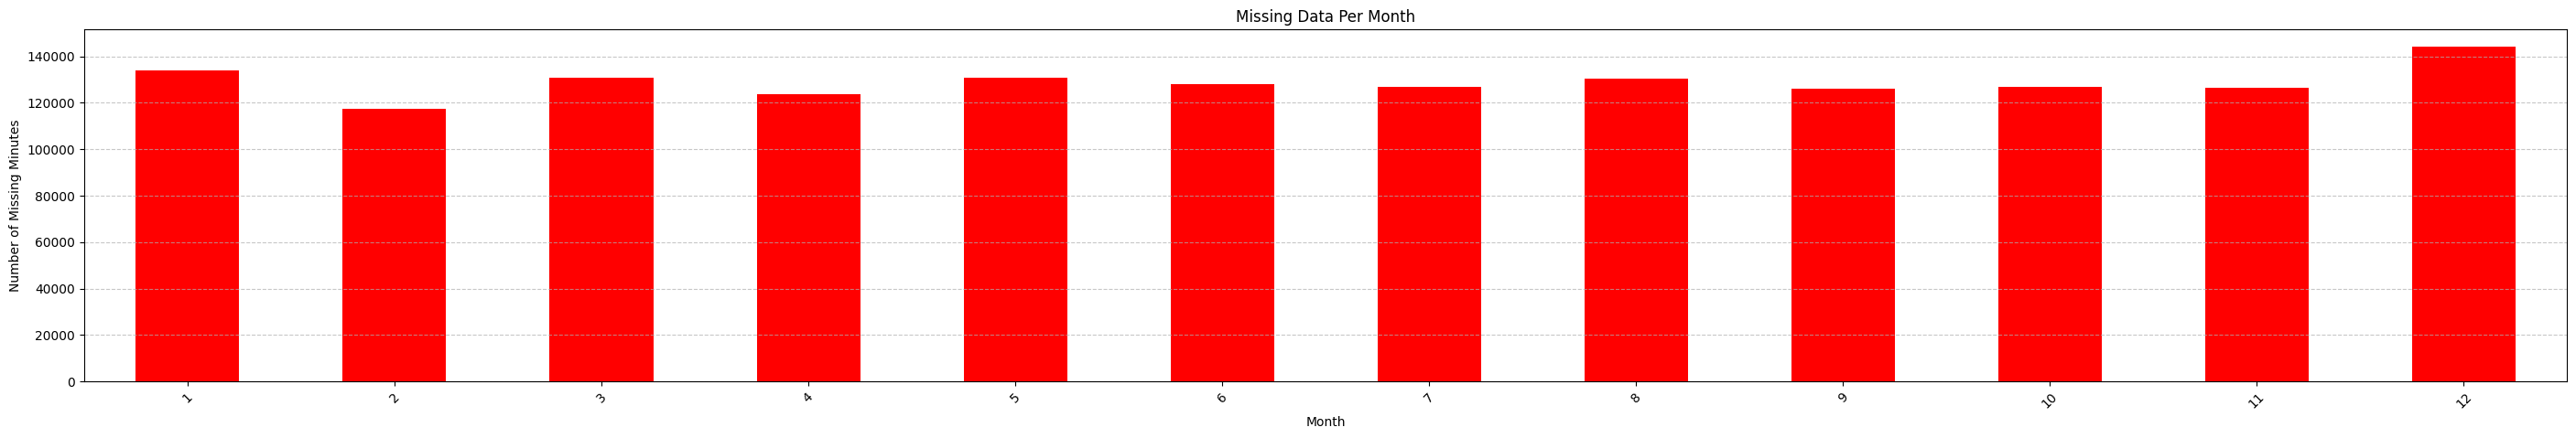

In [24]:
# Group by month and sum the indicator column (missing minutes per month)
missing_per_month = combined_df.groupby(combined_df['DateTime'].dt.month)['indicator'].sum()

# Plot the bar chart
plt.figure(figsize=(35, 5))
missing_per_month.plot(kind='bar', color='red')
plt.title('Missing Data Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Missing Minutes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [25]:
print(missing_per_month)

DateTime
1     133889
2     117307
3     130743
4     123789
5     130668
6     128124
7     127025
8     130626
9     126070
10    126858
11    126306
12    144367
Name: indicator, dtype: int64


In [26]:
# We expect to have 4 weekends/ mo. Therefore 4*2*24*60 minutes missing per month = 11,520
sum(missing_per_month)-(11520*12)

1407532

In [27]:
def remove_all_consecutive_duplicates(df):
    """Remove consecutive OHLC duplicates and flat bars with no price movement"""
    df_clean = df.copy()
    
    while True:
        # Check for consecutive duplicates
        prev_dup = (
            (df_clean['Open'] == df_clean['Open'].shift(1)) & 
            (df_clean['High'] == df_clean['High'].shift(1)) & 
            (df_clean['Low'] == df_clean['Low'].shift(1)) & 
            (df_clean['Close'] == df_clean['Close'].shift(1))
        )
        
        next_dup = (
            (df_clean['Open'] == df_clean['Open'].shift(-1)) & 
            (df_clean['High'] == df_clean['High'].shift(-1)) & 
            (df_clean['Low'] == df_clean['Low'].shift(-1)) & 
            (df_clean['Close'] == df_clean['Close'].shift(-1))
        )
        
        # Check for flat bars (no price movement)
        flat_bar = (
            (df_clean['Open'] == df_clean['High']) & 
            (df_clean['Open'] == df_clean['Low']) & 
            (df_clean['Open'] == df_clean['Close'])
        )
        
        # Combine conditions
        is_duplicate = prev_dup | next_dup | flat_bar
        count = is_duplicate.sum()
        
        if count == 0:
            break
            
        print(f"Marking {count} duplicates and flat bars…")

        # 1) blank out the OHLC
        df_clean.loc[is_duplicate, ['Open','High','Low','Close']] = np.nan
        df_clean.loc[is_duplicate, 'Volume'] = 0
        # 2) flag them
        df_clean.loc[is_duplicate, 'indicator'] = 1
        
    
    
    return df_clean

def remove_duplicate_timestamps(df):
    """
    Remove rows so that every DateTime is unique.
    Keeps the first occurrence of each timestamp and deletes all others.
    """
    df_clean = df.copy()

    while True:
        # Mark all rows whose DateTime appears more than once
        dup_mask = df_clean['DateTime'].duplicated(keep=False)
        if not dup_mask.any():
            break

        # Of those duplicates, keep only the first in each group
        to_remove = df_clean['DateTime'].duplicated(keep='first')
        count = to_remove.sum()
        print(f"Removing {count} rows with duplicate timestamps…")

        df_clean = df_clean.loc[~to_remove].reset_index(drop=True)

    return df_clean

def process_duplicated_data(df):
    """
    Process the DataFrame to remove duplicate timestamps and consecutive duplicates.
    """
    # Remove duplicate timestamps
    df = remove_duplicate_timestamps(df)

    # Remove consecutive duplicates and flat bars
    df = remove_all_consecutive_duplicates(df)

    return df



In [28]:
final_data_clean = process_duplicated_data(combined_df)

Removing 180 rows with duplicate timestamps…
Marking 57130 duplicates and flat bars…


In [29]:
def check_dup(data):
    # Check for consecutive duplicates with previous row
    verify_prev = (
        (data['Open'] == data['Open'].shift(1)) & 
        (data['High'] == data['High'].shift(1)) & 
        (data['Low'] == data['Low'].shift(1)) & 
        (data['Close'] == data['Close'].shift(1))
    )
    
    # Check for consecutive duplicates with next row
    verify_next = (
        (data['Open'] == data['Open'].shift(-1)) & 
        (data['High'] == data['High'].shift(-1)) & 
        (data['Low'] == data['Low'].shift(-1)) & 
        (data['Close'] == data['Close'].shift(-1))
    )
    
    # Check for flat bars (no price movement)
    flat_bar = (
        (data['Open'] == data['High']) & 
        (data['Open'] == data['Low']) & 
        (data['Open'] == data['Close'])
    )
    
    # Count each type of duplicate
    consecutive_dups = (verify_prev | verify_next).sum()
    flat_bars = flat_bar.sum()
    total_dups = (verify_prev | verify_next | flat_bar).sum()
    
    print(f"Consecutive duplicates: {consecutive_dups}")
    print(f"Flat bars (no price movement): {flat_bars}")
    print(f"Total issues: {total_dups}")
    
    return total_dups

In [30]:
check_dup(final_data_clean)

Consecutive duplicates: 0
Flat bars (no price movement): 0
Total issues: 0


np.int64(0)

In [31]:
final_data_clean

,DateTime,Open,High,Low,Close,Volume,indicator
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,0
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,0
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,0
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,0
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,0
...,...,...,...,...,...,...,...
5258334,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,0
5258335,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,0
5258336,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,0
5258337,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,0


In [32]:
data = final_data_clean.copy()
data

,DateTime,Open,High,Low,Close,Volume,indicator
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,0
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,0
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,0
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,0
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,0
...,...,...,...,...,...,...,...
5258334,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,0
5258335,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,0
5258336,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,0
5258337,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,0


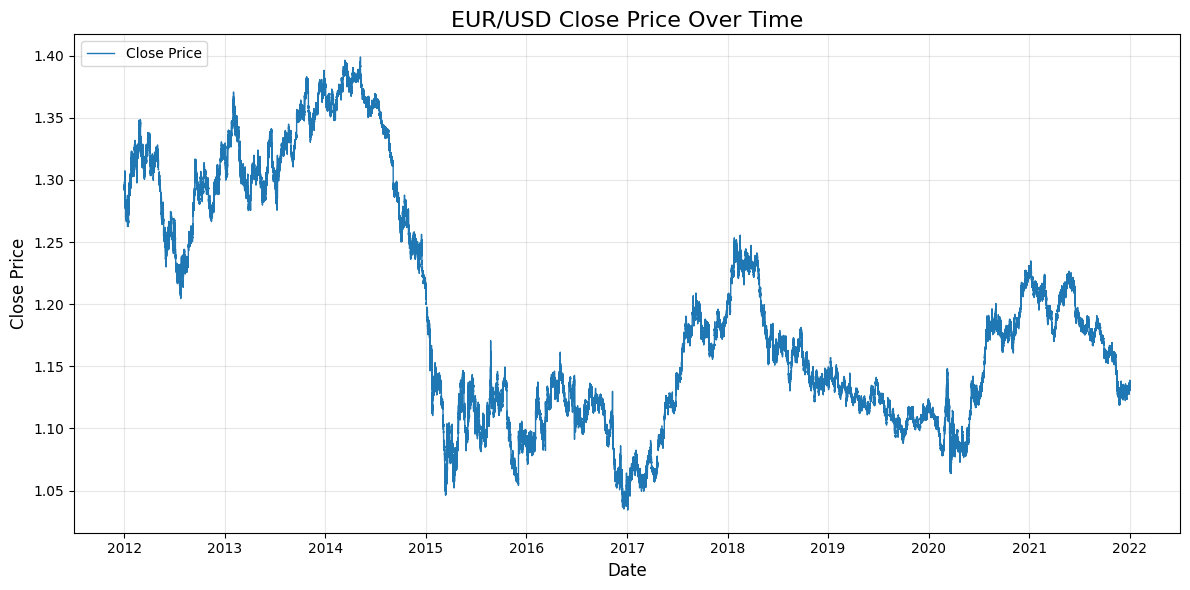

In [33]:
#Plotting graph of data from close price
# Plot the 'Close' prices
plt.figure(figsize=(12, 6))
plt.plot(data['DateTime'], data['Close'], label='Close Price', linewidth=1)

# Enhancing the plot aesthetics
plt.title('EUR/USD Close Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()


In [34]:
# Create a column to identify hourly groups
data['Hour'] = pd.to_datetime(data['DateTime']).dt.floor('h').dt.hour
data

,DateTime,Open,High,Low,Close,Volume,indicator,Hour
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,0,2
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,0,2
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,0,2
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,0,2
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,0,2
...,...,...,...,...,...,...,...,...
5258334,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,0,16
5258335,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,0,16
5258336,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,0,16
5258337,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,0,16


In [35]:
#Overall, the pipeline is:

#1. Drop days with too many missing minutes.

#2. Resample to your small minute_interval (e.g. 5 min) to form bars.

#3. Compute one per‐bar variance measure 𝑉

#4. Sum V and count bars in each large bucket of length timeframe.

#5. Turn that sum into an annualized realized volatility.

#6. Map it back onto every row, then collapse each bucket to a single row for plotting and statistical analysis.


def preprocess_ohlc_data(data, minute_interval):
    """
    Prepare OHLC data by properly formatting datetime and resampling to specified interval.
    For each timestamp, the interval is (timestamp - minute_interval + 1) to timestamp inclusive.
    For example, for 17:35:00 with 5-minute interval, we include [17:31:00 to 17:35:00].
    """
    # Ensure 'DateTime' is in datetime format
    data.reset_index(inplace=True)
    data['DateTime'] = pd.to_datetime(data['DateTime'], format='%Y%m%d %H%M%S')
    

    data = data.groupby(pd.Grouper(key='DateTime', freq=f'{minute_interval}Min',closed='right',label='right')).agg({
                                          "Open":  "first",
                                          "High":  "max",
                                          "Low":   "min",
                                         "Close": "last",
                                          "Volume": "sum",
                                          "indicator": "sum",
                                          "group_id":  lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan

                                          
                                          })
    return data
data


,DateTime,Open,High,Low,Close,Volume,indicator,Hour
0,2012-01-02 02:00:00,1.29324,1.29381,1.29324,1.29332,0.0,0,2
1,2012-01-02 02:01:00,1.29326,1.29345,1.29275,1.29341,0.0,0,2
2,2012-01-02 02:02:00,1.29342,1.29344,1.29341,1.29343,0.0,0,2
3,2012-01-02 02:03:00,1.29342,1.29342,1.29335,1.29336,0.0,0,2
4,2012-01-02 02:04:00,1.29324,1.29347,1.29320,1.29346,0.0,0,2
...,...,...,...,...,...,...,...,...
5258334,2021-12-31 16:54:00,1.13797,1.13797,1.13774,1.13774,0.0,0,16
5258335,2021-12-31 16:55:00,1.13775,1.13781,1.13748,1.13748,0.0,0,16
5258336,2021-12-31 16:56:00,1.13749,1.13765,1.13704,1.13707,0.0,0,16
5258337,2021-12-31 16:57:00,1.13709,1.13740,1.13679,1.13740,0.0,0,16


In [36]:
def filter_incomplete_groups(ohlc_data, timeframe, threshold, vol_measure, minute_interval):
    """
    Filter out minutes within timeframe groups that exceed missing-data or are undersized.
    Before filtering, plots a scatter of available log-returns per group:
      • Green dots for groups with enough returns (≥ valid_returns_thresh)
      • Red dots for groups with too few returns (< valid_returns_thresh)
    The dashed horizontal line marks valid_returns_thresh.
    """
    # 1) Prepare & index
    ohlc = ohlc_data.copy()
    ohlc['DateTime'] = pd.to_datetime(ohlc['DateTime'], format='%Y%m%d %H%M%S')
    ohlc.set_index('DateTime', inplace=True)
    ohlc['group_id'] = ohlc.index.floor(f"{timeframe}T")

    # 2) Compute thresholds
    missing_thresh = timeframe * threshold               # max missing minutes
    valid_returns_thresh = timeframe - missing_thresh    # min log-returns needed

    # 3) Pre-filter metrics
    missing_counts = ohlc.groupby('group_id')['indicator'].sum()
    log_counts     = ohlc.groupby('group_id')['Log_Returns_global'] \
                         .apply(lambda x: x.notna().sum())

    # 4) Scatter plot of log-return counts
    passed = log_counts >= valid_returns_thresh
    plt.figure(figsize=(12, 5))
    plt.scatter(log_counts.index, log_counts.values,
                c=['green' if ok else 'red' for ok in passed],
                edgecolor='k', s=50)
    plt.axhline(y=valid_returns_thresh, color='black',
                linestyle='--', linewidth=2,
                label=f"Return-count threshold = {valid_returns_thresh:.0f}")
    plt.xticks(rotation=45)
    plt.xlabel('Group Start Time')
    plt.ylabel('Available Log-Returns')
    plt.title(
        f"EURO/USD FX Rate rVol ({timeframe} min rVol vs {minute_interval}-min)\n"
        f"Log-Return Counts per {timeframe}-Minute Group (Pre-Filter)\n"
        f"Green  ≥{valid_returns_thresh:.0f} returns, Red  <{valid_returns_thresh:.0f}"
    ) 
    #plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # 5) Now simply select the green groups
    valid_groups = passed[passed].index
    filtered_data = ohlc[ohlc['group_id'].isin(valid_groups)].copy()
    
    # 6) Diagnostics
    print(f"Keeping {len(valid_groups)} groups (the green ones) out of {len(passed)} total.")
    
    return filtered_data


In [37]:
def compute_volatility_measure(ohlc_data, vol_measure):
    """
    Calculate volatility using the specified method.
    
    Parameters:
    - ohlc_data (pd.DataFrame): OHLC data
    - vol_measure (str): Volatility measure ('Garman-Klass', 'Rogers-Satchell', 'Close-to-Close')
    
    Returns:
    - ohlc_data (pd.DataFrame): OHLC data with volatility measure added
    """
    # Make a copy to avoid modifying the input
    ohlc_data = ohlc_data.copy()
    
    # Constant for Garman-Klass
    k = 2 * np.log(2) - 1
    
    # Compute volatility measures (Variance)
    if vol_measure == 'Garman-Klass':
        ohlc_data['V'] = 0.5 * (np.log(ohlc_data['High'] / ohlc_data['Low']) ** 2) - \
                       k * (np.log(ohlc_data['Close'] / ohlc_data['Open']) ** 2)
    
    elif vol_measure == 'Rogers-Satchell':
        '''
        # Define prev close
        ohlc_data['Prev_Close'] = ohlc_data['Close'].shift(1)
        # Now compute Rogers–Satchell using Prev_Close (as before)
        ohlc_data['V'] = (
            np.log(ohlc_data['High']  / ohlc_data['Prev_Close']) *
            np.log(ohlc_data['High']  / ohlc_data['Close'])      +
            np.log(ohlc_data['Low']   / ohlc_data['Prev_Close']) *
            np.log(ohlc_data['Low']   / ohlc_data['Close'])
        )'''

        H, L, C = ohlc_data['High'], ohlc_data['Low'], ohlc_data['Close']
        P = ohlc_data['Prev_Close_global']   # <— from step 1
        ohlc_data['V'] = np.log(H/P)*np.log(H/C) + np.log(L/P)*np.log(L/C)
                        
    
    elif vol_measure == 'Close-to-Close':
        ohlc_data['V'] = ohlc_data['Log_Returns_global']**2
        #print(ohlc_data['V'])
    
    else:
        raise ValueError("Invalid volatility measure. Choose 'Garman-Klass', 'Rogers-Satchell', or 'Close-to-Close'.")
    
    return ohlc_data


In [38]:
def setup_rvol_col(data, timeframe, vol_measure):
    """
    The overall purpose is to:
    1. Compute variance contributions for each row
    2. Calculate realized volatility for each group
    3. Attach the group's volatility to every row in that group
    """
    # 1) Compute per-bar variance contributions (V) for each row
    v_by_group = data.groupby('group_id')\
                     .apply(lambda grp: compute_volatility_measure(grp, vol_measure))
    
    # If it came back as a DataFrame, pick its 'V' column
    if isinstance(v_by_group, pd.DataFrame):
        v_series = v_by_group['V']
    else:
        v_series = v_by_group
    
    # Ensure index is consistent
    v_series = v_series.reset_index(level=0, drop=True)
    
    # 2) Attach per-bar V back onto a copy of your DataFrame
    df = data.copy()
    df['V'] = np.nan  # Preallocate
    df.loc[v_series.index, 'V'] = v_series
    
    # 3) Compute per-group sum of V and count of rows
    grp_stats = (
        df
        .groupby('group_id')['V']
        .agg(sum='sum', count='count')
    )
    print(grp_stats)
        # Sample variance WITHOUT using (n_minus_1)
    grp_stats['n_minus_1'] = grp_stats['count']
    grp_stats['var'] = np.where(
        grp_stats['n_minus_1'] > 0,
        grp_stats['sum'],
        np.nan
    )
    

    # 4) √variance → realized vol, annualize as before
    col_name = f'RVol_{timeframe}min_{vol_measure}'
    rvol_per_group = np.sqrt(grp_stats['var'])
    annualized_rvol = rvol_per_group * np.sqrt(365 * 24 * 60/ timeframe)

    # 5) Map both back onto every row
    df[col_name]    = df['group_id'].map(annualized_rvol)*100
    df['n_minus_1'] = df['group_id'].map(grp_stats['n_minus_1'])
    

    return df


In [39]:
def plot_realized_volatility(rvol_df, vol_measure, timeframe, minute_interval):
    """
    Plot realized volatility over time.
    
    Parameters:
    - rvol_df (pd.DataFrame): DataFrame with realized volatility values
    - vol_measure (str): Volatility measure used
    - timeframe (int): Timeframe used for calculation
    """
    col_name = f'RVol_{timeframe}min_{vol_measure}'
    main_title = f"EURO/USD FX Rate rVol ({timeframe} min rVol vs {minute_interval}-min)."
    log_vol = np.log(rvol_df[col_name])
    plt.figure(figsize=(30, 15))
    plt.scatter(rvol_df['EndDateTime'], log_vol, #rvol_df[col_name], 
               label=f'Realized Volatility ({vol_measure}, {timeframe} min)', 
               color='b', alpha=0.7)
    plt.xlabel('Time')
    plt.ylabel('Realized Volatility (%)')
    plt.title(f"{main_title}", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()


In [40]:
def preprocess_by_group_id(rvol, vol_title):
    # Ensure 'DateTime' is in datetime format
    if isinstance(rvol.index, pd.DatetimeIndex):
        rvol.reset_index(inplace=True)
    
    # Convert DateTime if it's not already in datetime format
    if not pd.api.types.is_datetime64_any_dtype(rvol['DateTime']):
        rvol['DateTime'] = pd.to_datetime(rvol['DateTime'])
    
    # Group by group_id
    grouped = rvol.groupby('group_id')
    
    
    # Aggregate the data
    aggregated = grouped.agg({
        "DateTime": ["first", "last"],  # Keep first and last datetime for reference
        "Open": "first",                # First price in the group
        "High": "max",                  # Highest price in the group
        "Low": "min",                   # Lowest price in the group
        "Close": "last",                # Last price in the group
        "Volume": "sum",                # Sum of volume
        "indicator": "sum",             # Sum of indicator
        'n_minus_1': "mean",             # Mean of count
    })
    
    # Add vol_title aggregation explicitly
    #aggregated[vol_title] = grouped[vol_title].mean()
    
    #  — Compute mode of vol_title instead of mean:
    mode_series = grouped[vol_title].apply(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    aggregated[vol_title] = mode_series.values
    
    # Flatten multi-level column names
    aggregated.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in aggregated.columns]
    
    # Rename datetime columns for clarity
    aggregated.rename(columns={
        'DateTime_first': 'StartDateTime',
        'DateTime_last': 'EndDateTime',
        'n_minus_1_mean': 'count'  
    }, inplace=True)

    # Reset index to make group_id a regular column
    aggregated.reset_index(inplace=True)
    #print(aggregated)
    #aggregated['count'] = aggregated['n_minus_1'] # Rename n_minus_1 to count for clarity
    return aggregated


In [41]:
def plot_num_of_rows_per_group(df):
    
    plt.figure(figsize=(10, 6))
    plt.plot(df['group_id'], df['count'], marker='o', linestyle='', markersize=4)
    plt.xlabel('group_id')
    plt.ylabel('count of rows')
    plt.title('count vs. group_id')
    plt.grid(True)
    plt.show()


In [42]:
def plot_rvol_histogram(rvol_data, timeframe, minute_interval, vol_measure, title_dates=None, bins=100):
    """
    Histogram of log(rVol) with:
      • green dashed = arithmetic mean
      • red dotted   = +1σ
      • red dashdot  = -1σ
    Stats‐box on left, legend on right, and date range as subtitle.
    """
    # 1) Series extraction & cleaning
    if isinstance(rvol_data, pd.DataFrame):
        series = rvol_data.iloc[:,0].dropna()
    else:
        series = rvol_data.dropna()
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    series = series[series > 0]
    if series.empty:
        print("No valid data to plot.")
        return

    # 2) Compute arithmetic stats
    mu_log = np.log(series).mean()
    sigma_log = np.log(series).std()
    sigma = np.exp(sigma_log)
    mu = np.exp(mu_log)

    # 3) Log-transform
    log_data = np.log(series)

    # 4) Plot
    fig, ax = plt.subplots(figsize=(10,6))
    ax.hist(log_data, bins=bins, edgecolor='k', alpha=0.7)

    # 5) Vertical lines
    ax.axvline(mu_log, color='green', linestyle='--', label=f"Mean = {mu:.4f}")
    ax.axvline(mu_log + sigma_log, color='red', linestyle=':', label=f"+1σ = {np.exp(mu_log + sigma_log):.4f}")
    ax.axvline(mu_log - sigma_log, color='red', linestyle='-.', label=f"−1σ = {np.exp(mu_log - sigma_log):.4f}")

    # 6) Stats‐box (left side)
    stats_text = (
        f"std: {sigma:.4f}\n"
        f"Min:  {series.min():.4f}\n"
        f"Max:  {series.max():.4f}\n"
        f"Skew: {skew(log_data):.2f}\n"
        f"Kurt: {kurtosis(log_data):.2f}"
    )
    ax.text(0.02, 0.95, stats_text, transform=ax.transAxes,
            fontsize=10, va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # 7) Format x‐axis back to original scale
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{np.exp(x):.3f}"))
    
    rvol_actual = series[1:]

    # 8) Title & subtitle
    main_title = f"EURO/USD FX Rate rVol ({timeframe} min rVol vs {minute_interval}-min)."
    third_title = f"Total # of Volatility Observed = {len(rvol_actual)}"
    if title_dates:
        start_str, end_str = title_dates
        subtitle = f"Date range: {start_str} to {end_str}. {third_title}"

    ax.set_title(main_title, fontsize=13, pad=20)
    ax.text(0.5, 1.02, subtitle, transform=ax.transAxes,
            fontsize=11, ha='center')

    ax.set_xlabel("Realized Volatility (%)")
    ax.set_ylabel("# of Vols")

    # 9) Legend outside right
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

    # 10) Tight layout with room on right
    plt.tight_layout(rect=(0,0,0.8,1))
    plt.show()


In [43]:
# Ensure DateTime is in datetime format and is a column

def plot_returns(data):
    time_col = 'DateTime'
    if 'EndDateTime' in data.columns:
        time_col = 'EndDateTime'
    elif 'StartDateTime' in data.columns:
        time_col = 'StartDateTime'
    elif 'DateTime' not in data.columns:
        raise KeyError("No valid time column found for plotting.")

    data['Prev_Close_global']  = data['Close_last'].shift(1)
    data['Prev_Close_global'].fillna(data['Open_first'], inplace=True)
    data['Log_Returns_global'] = np.log(data['Close_last'] / data['Prev_Close_global'])

    # Scatter plot of log returns
    plt.figure(figsize=(15, 6))
    plt.scatter(data[time_col], data['Log_Returns_global'], s=10, alpha=0.6)
    plt.title('EUR/USD Minute-by-Minute Log Returns Over Time')
    plt.xlabel('Time')
    plt.ylabel('Returns (%)')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.2%}'.format(x)))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [44]:
def plot_return_histogram(data):
    log_returns = data['Log_Returns_global'].dropna()*100

    # Stats
    mu    = log_returns.mean()
    sigma = log_returns.std()
    r_min = log_returns.min()
    r_max = log_returns.max()
    r_skew = skew(log_returns)
    r_kurt = kurtosis(log_returns)

    stats_text = (
        f"Mean:    {mu:.6f}\n"
        f"Std:     {sigma:.6f}\n"
        f"Min:     {r_min:.6f}\n"
        f"Max:     {r_max:.6f}\n"
        f"Skew:    {r_skew:.6f}\n"
        f"Kurtosis:{r_kurt:.6f}"
    )

    # Plot
    plt.figure(figsize=(12, 6))
    plt.hist(log_returns, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
    plt.axvline(mu, color='green', linestyle='--', linewidth=2, label=f"Mean")
    plt.axvline(mu + sigma, color='red', linestyle='--', linewidth=1.5, label='+1 Std')
    plt.axvline(mu - sigma, color='red', linestyle='--', linewidth=1.5, label='-1 Std')
    plt.title("EUR/USD Minute-by-Minute Log Returns Distribution")
    plt.xlabel("Returns (%)")
    plt.ylabel("Frequency")
    plt.legend(loc='upper right')
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.4", facecolor='white', alpha=0.8))
     # Zoom in here
    plt.xlim(-1.5, 1.5) 
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [45]:
def analyze_volatility_prediction(rVol, rVol_pred, time,
                                  timeframe, vol_measure, minute_interval):

    # 1) log-ratio
    log_ratio_full = np.log(rVol / rVol_pred)#np.abs(np.log(rVol / rVol_pred))#np.log(rVol / rVol_pred)
    log_ratio_even = log_ratio_full.iloc[0::2]
    log_ratio_odd  = log_ratio_full.iloc[1::2]
    time_even, time_odd = time[0::2], time[1::2]

    # 2) per-slice stats
    def stats_dict(s):
        return dict(mean=s.mean(), std=s.std(), min=s.min(), max=s.max(),
                    skew=s.skew(), kurtosis=s.kurt())
    stats_even, stats_odd = stats_dict(log_ratio_even), stats_dict(log_ratio_odd)

    # 3) stats-text strings (create **before** plotting!)
    stats_text_even = (
        f"Even Indices:\n"
        f"Mean: {stats_even['mean']:.4f}\n"
        f"Std:  {stats_even['std'] :.4f}\n"
        f"Min:  {stats_even['min'] :.4f}\n"
        f"Max:  {stats_even['max'] :.4f}\n"
        f"Skew: {stats_even['skew']:.2f}\n"
        f"Kurt: {stats_even['kurtosis']:.2f}"
    )
    stats_text_odd = (
        f"Odd  Indices:\n"
        f"Mean: {stats_odd['mean']:.4f}\n"
        f"Std:  {stats_odd['std'] :.4f}\n"
        f"Min:  {stats_odd['min'] :.4f}\n"
        f"Max:  {stats_odd['max'] :.4f}\n"
        f"Skew: {stats_odd['skew']:.2f}\n"
        f"Kurt: {stats_odd['kurtosis']:.2f}"
    )

    # --------------------------------------------------
    # 4) SCATTER (odd vs even, centred at zero line)
    plt.figure(figsize=(12, 6))
    #plt.scatter(time_even, log_ratio_even, color='orange', alpha=0.6, label='Even indices')
    plt.scatter(time_odd , log_ratio_odd , color='blue'  , alpha=0.6, label='Odd indices')
    main = f"EURO/USD FX Rate rVol({timeframe} min rVol vs {minute_interval} min)"
    second_title = f"Predicted = Previous Trailing rVol"
    plt.title(f"{main}\nln(rVol / rVol_pred)\n{second_title}\n Total # of Vol observed = {len(log_ratio_full)}")
    plt.xlabel("Time");   plt.ylabel("Log-ratio error")
    plt.axhline(0, color='red', ls='--', lw=1)
    plt.legend(); plt.grid(alpha=.4, ls='--'); plt.tight_layout()  #legend
    plt.show()
    # --------------------------------------------------
    '''
    # 5) HISTOGRAM with right-hand sidebar
    fig, ax = plt.subplots(figsize=(12, 6))
    #ax.hist(log_ratio_even, bins=50, color='orange', alpha=.4, edgecolor='black', label='Even indices')
    ax.hist(log_ratio_odd , bins=50, color='blue'  , alpha=.6, edgecolor='black', label='Odd indices')

    ax.set_title(f"{main}\nDistribution of ln(rVol / rVol_pred)")
    ax.set_xlabel("Log Ratio"); ax.set_ylabel("Frequency")

    # reserve 22 % of figure for sidebar
    plt.tight_layout(rect=(0, 0, 0.98, 1))

    # legend in sidebar
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 1.5), frameon=False)

    # stats boxes in sidebar
    ax.text(1.02, 0.95, stats_text_odd,  transform=ax.transAxes,
            ha='left', va='top', bbox=dict(fc='white', ec='blue'  , alpha=.8))
    #ax.text(1.02, 0.60, stats_text_even, transform=ax.transAxes,
    #        ha='left', va='top', bbox=dict(fc='white', ec='orange', alpha=.8))

    ax.grid(alpha=.4, ls='--')
    plt.show()'''
    # 5) HISTOGRAM (clean version with only one distribution)
    fig, ax = plt.subplots(figsize=(10, 6))  # reduced width

    # Plot only the log-ratio values (previously called 'odd')
    ax.hist(log_ratio_odd, bins=50, color='steelblue', alpha=0.7, edgecolor='black')

    # Title and labels
    ax.set_title(f"{main}\nDistribution of ln(rVol / rVol_pred)")
    ax.set_xlabel("Log Ratio")
    ax.set_ylabel("Frequency")

    # Optional stats box
    ax.text(0.97, 0.95, stats_text_odd, transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(fc='white', ec='black', alpha=0.8))

    # Grid and layout
    ax.grid(alpha=0.4, linestyle='--')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------

    return {"odd": stats_odd, "even": stats_even}


In [46]:
def plot_rvol_r2(rvol_data, vol_measure, timeframe, minute_interval, vol_title):
    """
    Uses the previous rVol value as the prediction and plots R² between predicted and actual rVol.
    
    Parameters:
    - rvol_series (pd.Series): A time series of realized volatility values.
    - title (str): Title of the plot.
    """
    rvol_data.set_index('EndDateTime', inplace=True)
    
    rvol_series = rvol_data[vol_title]
    # Clean the series: remove inf and NaN
   
    rvol_series = rvol_series.replace([np.inf, -np.inf], np.nan).dropna()
    #rvol_series = rvol_series.set_index('EndDateTime')[f'RVol_{timeframe}min_{vol_measure}']
    
    # Use lag-1 as prediction
    rvol_pred = rvol_series.shift(1).dropna()
    rvol_actual = rvol_series.iloc[1:]
    
    # Align indices
    rvol_pred = rvol_pred.loc[rvol_actual.index]
    
    # Final clean: ensure both have no inf or NaN
    mask = (~rvol_actual.isna()) & (~rvol_pred.isna()) & \
           (~np.isinf(rvol_actual)) & (~np.isinf(rvol_pred))
    rvol_actual = rvol_actual[mask]
    rvol_pred = rvol_pred[mask]
    
    # Check if there is enough data
    if len(rvol_actual) < 2:
        print("Not enough valid data to calculate R².")
        return None
    
    # R² Score
    r2 = r2_score(rvol_actual, rvol_pred)
    # ln R² Score
    ln_R2 = r2_score(np.log(rvol_actual), np.log(rvol_pred))
    
    '''
    # Plot 1: Predicted vs Actual (swapped axes)
    plt.figure(figsize=(8, 6))
    plt.scatter(rvol_pred, rvol_actual, alpha=0.5)  # Swapped axes here
    plt.xlabel('Predicted rVol')                    # Swapped label
    plt.ylabel('Actual rVol')                       # Swapped label
    plt.title(f'{title}\nCorrelation ($R^2$ = {r2:.4f})')
    plt.grid(True)
    plt.show()'''
    
    # Plot 2: Log-Log plot with original rVol labels (swapped axes)
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Calculate log values for plotting
    log_actual = np.log(rvol_actual)
    log_pred = np.log(rvol_pred)
    
    # Scatter plot of log values (swapped axes)
    ax.scatter(log_pred, log_actual, alpha=0.5)  # Swapped axes here
    
    # Set up custom tick locators and formatters to show original values
    from matplotlib.ticker import ScalarFormatter, LogLocator
    
    # Create formatters that will convert log values back to original scale for display
    class ExpFormatter(ScalarFormatter):
        def __call__(self, x, pos=None):
            # Convert log value to original value for display
            return f"{np.exp(x):.3f}"
    
    # Apply the formatters to both axes
    ax.xaxis.set_major_formatter(ExpFormatter())
    ax.yaxis.set_major_formatter(ExpFormatter())
    
    main_title = f"EURO/USD FX Rate rVol ({timeframe} min rVol vs {minute_interval}-min). Actual vs Predicted"
    sub_title = f"Predicted = Previous Trailing rVol"
    third_title = f"Total # of Volatility Observed = {len(rvol_actual)}"
    title = f"{main_title}\n{sub_title}\n{third_title}"
    # Set labels and title (swapped labels)
    ax.set_xlabel('Predicted rVol (%)')                   # Swapped label
    ax.set_ylabel('Actual rVol (%)')                      # Swapped label
    ax.set_title(f'{title}')# = {ln_R2:.4f}')
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    stats = analyze_volatility_prediction(rvol_actual, rvol_pred, time=rvol_actual.index, minute_interval = minute_interval, timeframe = timeframe, vol_measure = vol_measure)
    
    return stats


In [47]:
def calculate_rvol(data, vol_measure, timeframe, minute_interval, threshold, vol_title, plot=True):
    """

    Overall, the pipeline is:
    
    0. Prepare data with necessary columns (we are pushing each close price to the next row and labelling it Prev_Close_global)

    1. Drop timeframe groups with too many missing minutes.

    2. Resample to your small minute_interval (e.g. 5 min) to form bars. (for > 1 min intervals)

    3. Compute one per‐bar variance measure 𝑉

    4. Sum V and count bars in each large bucket of length timeframe.

    5. Turn that sum into an annualized realized volatility.

    6. Map it back onto every row, then collapse each bucket to a single row for plotting and statistical analysis.

    """
    # Input validation
    assert timeframe % 60 == 0, "Timeframe must be a multiple of 60 minutes."
    assert minute_interval > 0, "Minute interval must be positive."
    
    ### Step 0: Prepare data with necessary columns (we created a new col (Prev_Close_global) that is the previous period close price)
    ###                                             (we calculate log returns using Prev_Close_global)
    data['Prev_Close_global']  = data['Close'].shift(1)
    
    #### include logic to fill missing prev close with current open if prev close is NaN
    data['Prev_Close_global'].fillna(data['Open'], inplace=True)
    ####
    
    data['Log_Returns_global'] = np.log(data['Close'] / data['Prev_Close_global'])
    
    #print(data)
    
    # Step 1: Filter incomplete timeframe groups
    filtered_ohlc_data = filter_incomplete_groups(data, timeframe, threshold, vol_measure, minute_interval)
    
    # Step 2: Preprocess data
    #grouped_ohlc_data = preprocess_ohlc_data(filtered_ohlc_data, minute_interval)
    grouped_ohlc_data = filtered_ohlc_data.copy()
    # Step 3: Compute volatility measures
    compute_volatility_measure(grouped_ohlc_data, vol_measure)
    # Step 4: Aggregate into realized volatility
    rvol_df1 = setup_rvol_col(grouped_ohlc_data, timeframe, vol_measure)
    # Step 5: Preprocess by group_id
    rvol_df = preprocess_by_group_id(rvol_df1, vol_title = vol_title)

    plot_returns(rvol_df)
    plot_return_histogram(rvol_df)


    #print(rvol_df1)
    
    
    #plot_num_of_rows_per_group(rvol_df)
    
    # Step 6: Plot if requested
    if plot:
        plot_realized_volatility(rvol_df, vol_measure, timeframe, minute_interval)
    print(rvol_df)    
     
    start = rvol_df['StartDateTime'].min()
    end   = rvol_df['EndDateTime'].max()
    start_str, end_str = start.strftime("%m/%d/%Y"), end.strftime("%m/%d/%Y")   
    # Step 7: Plot histogram of realized volatility
    plot_rvol_histogram(rvol_df[vol_title], timeframe, minute_interval, vol_measure, title_dates=(start_str, end_str))
    
    # Step 8: Plot R² between predicted and actual rVol
    plot_rvol_r2(rvol_df, vol_measure, timeframe, minute_interval, vol_title = vol_title)
    
    return rvol_df

C:\Users\phani\AppData\Local\Temp\ipykernel_24880\2865826790.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Prev_Close_global'].fillna(data['Open'], inplace=True)
C:\Users\phani\AppData\Local\Temp\ipykernel_24880\4174277596.py:13: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ohlc['group_id'] = ohlc.index.floor(f"{timeframe}T")


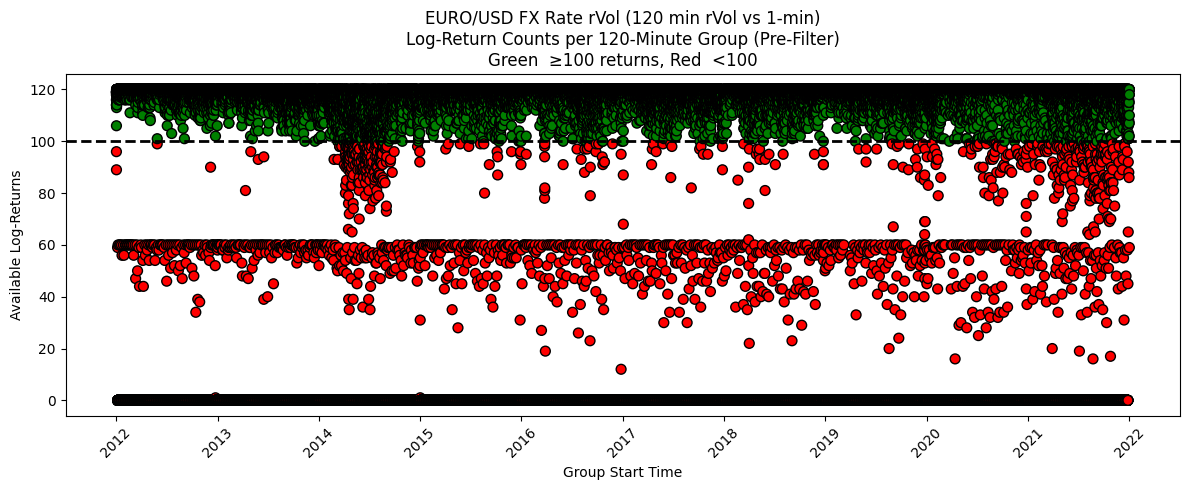

Keeping 29979 groups (the green ones) out of 43820 total.


C:\Users\phani\AppData\Local\Temp\ipykernel_24880\2441554807.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: compute_volatility_measure(grp, vol_measure))


                              sum  count
group_id                                
2012-01-02 02:00:00  2.129705e-06    119
2012-01-02 04:00:00  3.407421e-06    119
2012-01-02 06:00:00  9.679048e-07    118
2012-01-02 08:00:00  1.311797e-06    116
2012-01-02 10:00:00  1.068829e-06    114
...                           ...    ...
2021-12-31 06:00:00  8.690913e-07    120
2021-12-31 08:00:00  2.526838e-06    120
2021-12-31 10:00:00  3.520241e-06    120
2021-12-31 12:00:00  3.048053e-07    118
2021-12-31 14:00:00  1.279594e-07    110

[29979 rows x 2 columns]


c:\Users\phani\Desktop\Gamma Capture\GammaCapture\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\phani\AppData\Local\Temp\ipykernel_24880\779989498.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Prev_Close_global'].fillna(data['Open_first'], inplace=True)


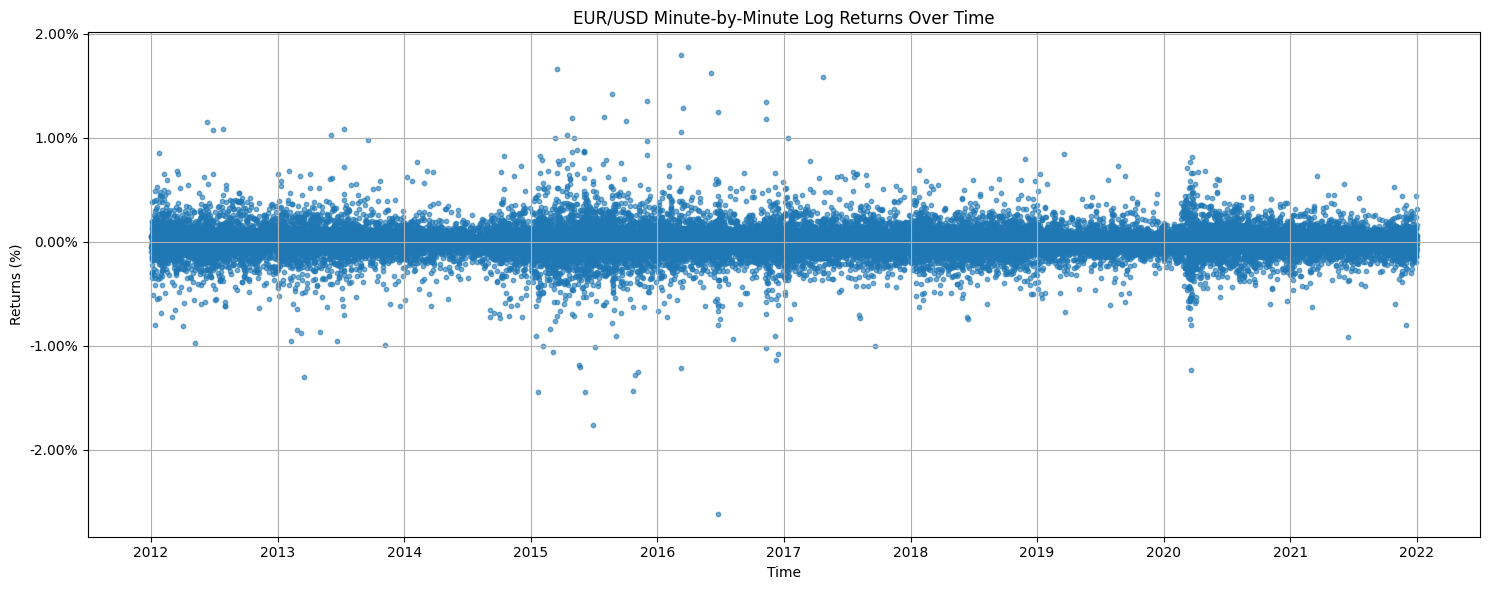

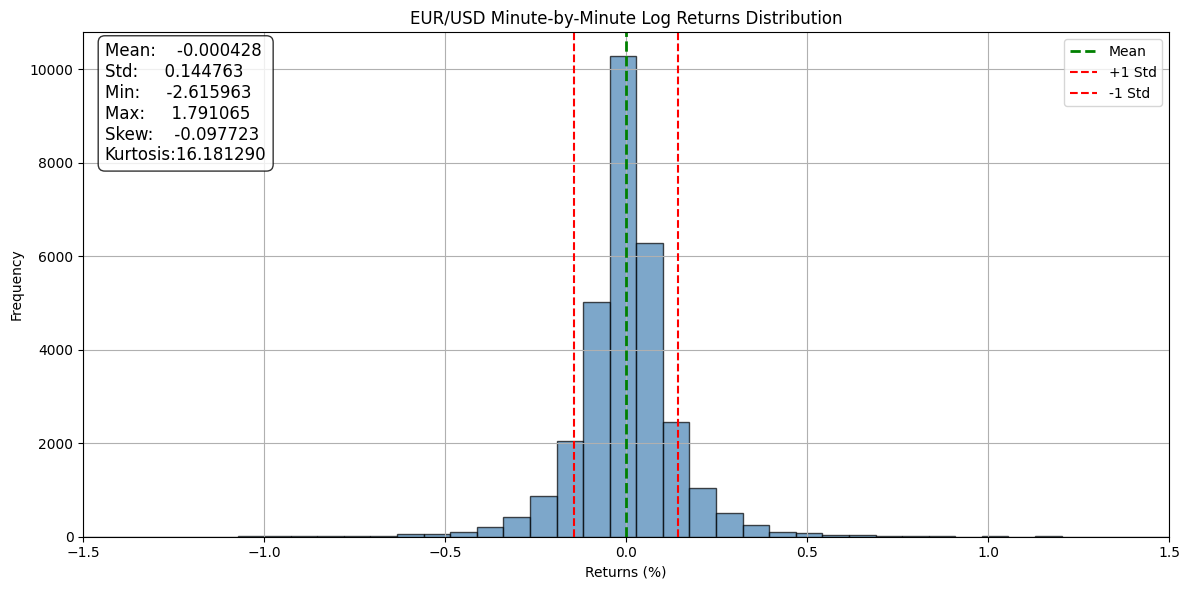

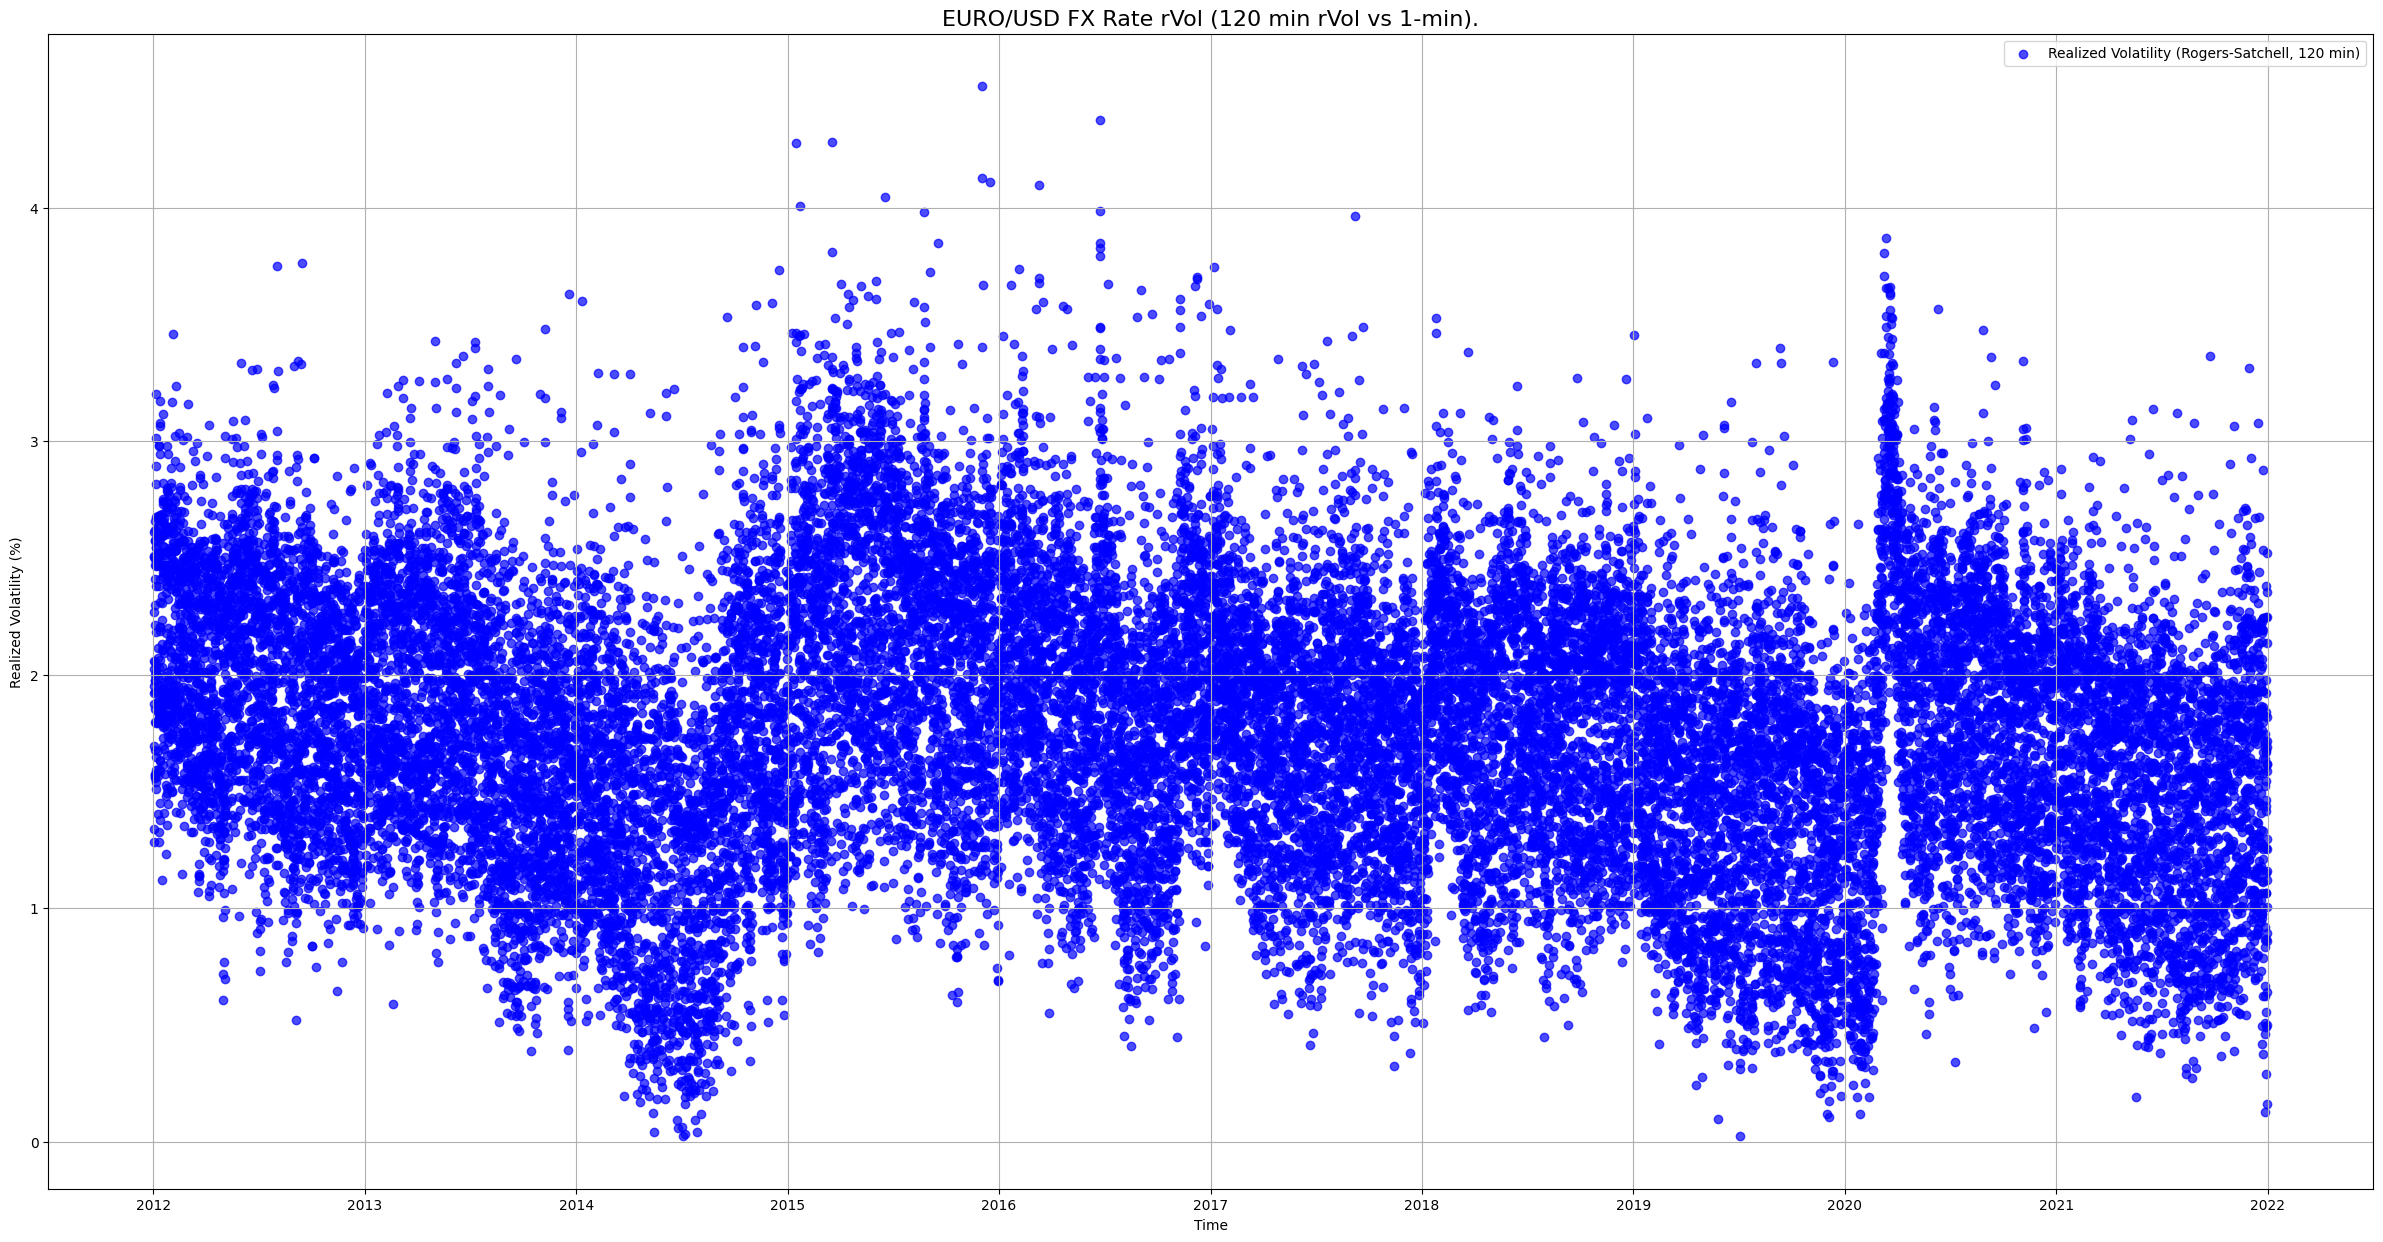

                 group_id       StartDateTime         EndDateTime  Open_first  \
0     2012-01-02 02:00:00 2012-01-02 02:00:00 2012-01-02 03:59:00     1.29324   
1     2012-01-02 04:00:00 2012-01-02 04:00:00 2012-01-02 05:59:00     1.29384   
2     2012-01-02 06:00:00 2012-01-02 06:00:00 2012-01-02 07:59:00     1.29454   
3     2012-01-02 08:00:00 2012-01-02 08:00:00 2012-01-02 09:59:00     1.29382   
4     2012-01-02 10:00:00 2012-01-02 10:00:00 2012-01-02 11:59:00     1.29325   
...                   ...                 ...                 ...         ...   
29974 2021-12-31 06:00:00 2021-12-31 06:00:00 2021-12-31 07:59:00     1.13248   
29975 2021-12-31 08:00:00 2021-12-31 08:00:00 2021-12-31 09:59:00     1.13253   
29976 2021-12-31 10:00:00 2021-12-31 10:00:00 2021-12-31 11:59:00     1.13438   
29977 2021-12-31 12:00:00 2021-12-31 12:00:00 2021-12-31 13:59:00     1.13790   
29978 2021-12-31 14:00:00 2021-12-31 14:00:00 2021-12-31 15:59:00     1.13848   

       High_max  Low_min  C

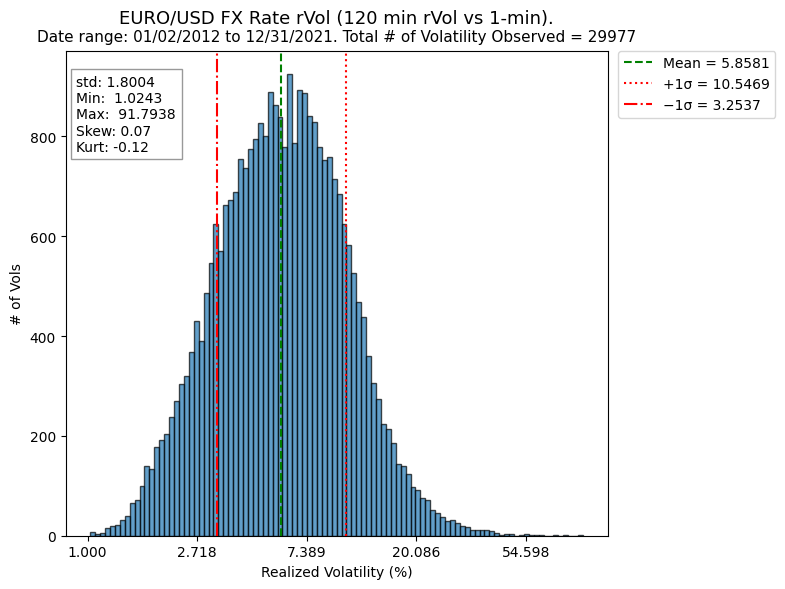

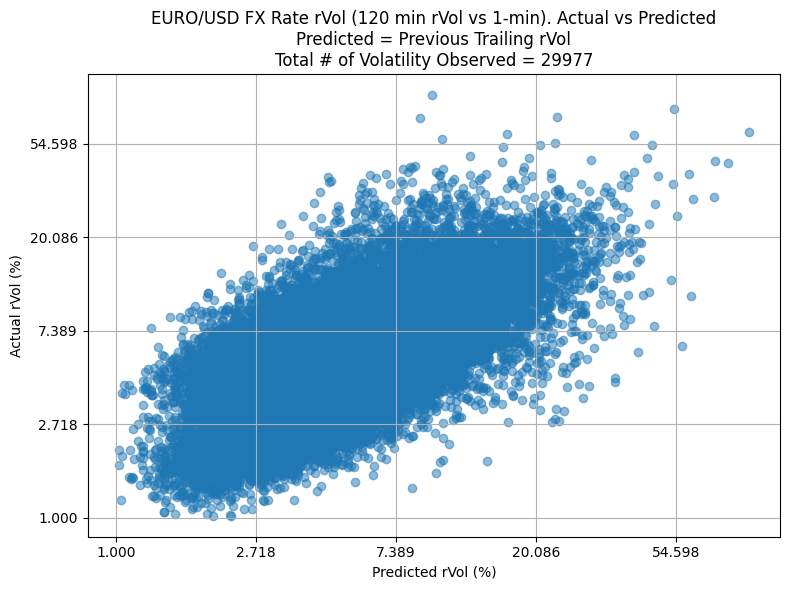

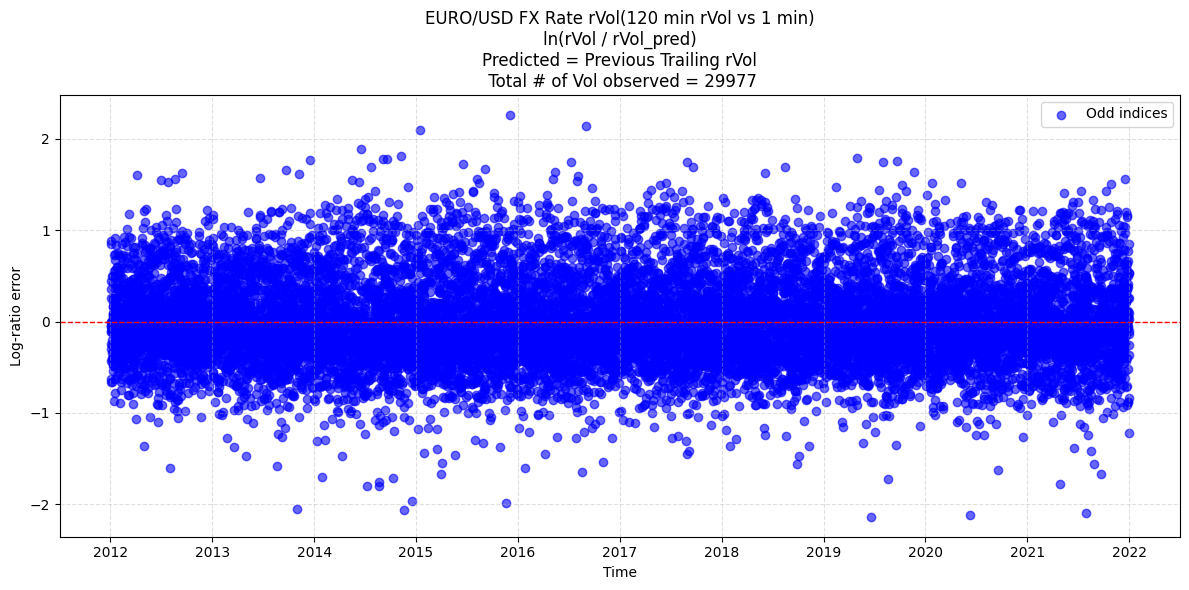

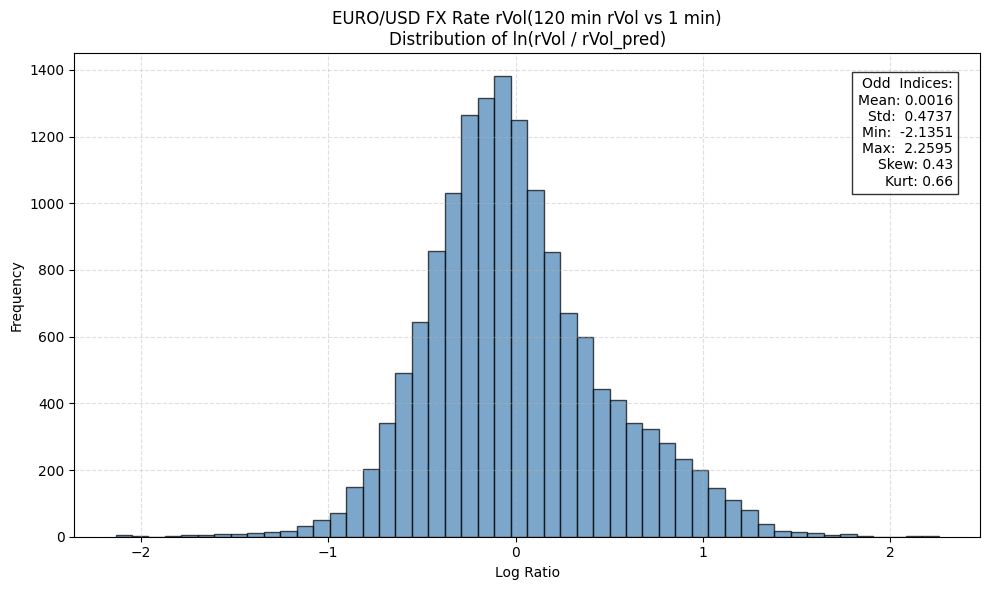

In [48]:
RS_120m_rvol = calculate_rvol(data, 
                              vol_measure = 'Rogers-Satchell', 
                              timeframe = 120, 
                              minute_interval = 1, 
                              threshold = 0.1667, 
                              vol_title = 'RVol_120min_Rogers-Satchell') # Choose 'Garman-Klass', 'Rogers-Satchell', or 'Close-to-Close'

In [49]:
RS_120m_rvol.describe()

,group_id,StartDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,RVol_120min_Rogers-Satchell,Prev_Close_global,Log_Returns_global
count,29979,29979,29979.000000,29979.000000,29979.000000,29979.000000,29979.0,29979.000000,29979.000000,29978.000000,29979.000000,29979.000000
mean,2016-12-25 00:03:11.173821440,2016-12-25 00:03:11.173821440,1.190413,1.191554,1.189299,1.190411,0.0,1.656193,118.343807,6.978330,1.190416,-0.000004
min,2012-01-02 02:00:00,2012-01-02 02:00:00,1.035590,1.037900,1.034060,1.035600,0.0,0.000000,100.000000,1.024268,1.035600,-0.026160
25%,2014-07-03 07:00:00,2014-07-03 07:00:00,1.118010,1.119260,1.116985,1.118025,0.0,0.000000,118.000000,3.868216,1.118025,-0.000596
50%,2016-12-29 08:00:00,2016-12-29 08:00:00,1.169340,1.170440,1.168310,1.169320,0.0,0.000000,120.000000,5.885780,1.169330,0.000000
75%,2019-06-18 09:00:00,2019-06-18 09:00:00,1.263890,1.265120,1.262575,1.263850,0.0,2.000000,120.000000,8.838733,1.263885,0.000589
max,2021-12-31 14:00:00,2021-12-31 14:00:00,1.396210,1.399270,1.394770,1.396230,0.0,20.000000,120.000000,91.793796,1.396230,0.017911
std,NaN,NaN,0.091608,0.091612,0.091598,0.091605,0.0,3.483439,3.483439,4.621604,0.091606,0.001448


In [50]:
RS_120m_rvol

,group_id,StartDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,RVol_120min_Rogers-Satchell,Prev_Close_global,Log_Returns_global
EndDateTime,,,,,,,,,,,,
2012-01-02 03:59:00,2012-01-02 02:00:00,2012-01-02 02:00:00,1.29324,1.29531,1.29275,1.29383,0.0,1,119.0,9.658213,1.29324,0.000456
2012-01-02 05:59:00,2012-01-02 04:00:00,2012-01-02 04:00:00,1.29384,1.29709,1.29381,1.29457,0.0,1,119.0,12.216589,1.29383,0.000572
2012-01-02 07:59:00,2012-01-02 06:00:00,2012-01-02 06:00:00,1.29454,1.29514,1.29311,1.29381,0.0,2,118.0,6.511085,1.29457,-0.000587
2012-01-02 09:59:00,2012-01-02 08:00:00,2012-01-02 08:00:00,1.29382,1.29442,1.29227,1.29327,0.0,4,116.0,7.580019,1.29381,-0.000417
2012-01-02 11:59:00,2012-01-02 10:00:00,2012-01-02 10:00:00,1.29325,1.29413,1.29167,1.29197,0.0,6,114.0,6.842128,1.29327,-0.001006
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 07:59:00,2021-12-31 06:00:00,2021-12-31 06:00:00,1.13248,1.13349,1.13120,1.13252,0.0,0,120.0,6.169781,1.13248,0.000035
2021-12-31 09:59:00,2021-12-31 08:00:00,2021-12-31 08:00:00,1.13253,1.13534,1.13191,1.13437,0.0,0,120.0,10.520242,1.13252,0.001632
2021-12-31 11:59:00,2021-12-31 10:00:00,2021-12-31 10:00:00,1.13438,1.13796,1.13379,1.13790,0.0,0,120.0,12.417189,1.13437,0.003107


In [51]:
RS_120m_rvol.head()

,group_id,StartDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,RVol_120min_Rogers-Satchell,Prev_Close_global,Log_Returns_global
EndDateTime,,,,,,,,,,,,
2012-01-02 03:59:00,2012-01-02 02:00:00,2012-01-02 02:00:00,1.29324,1.29531,1.29275,1.29383,0.0,1,119.0,9.658213,1.29324,0.000456
2012-01-02 05:59:00,2012-01-02 04:00:00,2012-01-02 04:00:00,1.29384,1.29709,1.29381,1.29457,0.0,1,119.0,12.216589,1.29383,0.000572
2012-01-02 07:59:00,2012-01-02 06:00:00,2012-01-02 06:00:00,1.29454,1.29514,1.29311,1.29381,0.0,2,118.0,6.511085,1.29457,-0.000587
2012-01-02 09:59:00,2012-01-02 08:00:00,2012-01-02 08:00:00,1.29382,1.29442,1.29227,1.29327,0.0,4,116.0,7.580019,1.29381,-0.000417
2012-01-02 11:59:00,2012-01-02 10:00:00,2012-01-02 10:00:00,1.29325,1.29413,1.29167,1.29197,0.0,6,114.0,6.842128,1.29327,-0.001006


In [52]:
def generate_28_day_stability_groups(df, vol_col, stability_days):
    df = df.copy()
    df.sort_index(inplace=True)

    # Step 1: Create rVol_p and log-ratio columns
    df['rVol_p'] = df[vol_col].shift(1)
    df['log_ratio'] = np.log(df[vol_col] / df['rVol_p'])
    df.dropna(inplace=True)
    
    # Splitting into even and odd indices
    even_data = df.iloc[::2]
    odd_data = df.iloc[1::2]
    df = odd_data.copy()

    

    # Step 2: Create Stability Group ID
    start_time = df.index.min().floor('D')
    df['Stability_group_id'] = ((df.index - start_time) // pd.Timedelta(days=stability_days)) * pd.Timedelta(days=stability_days) + start_time

    # Reset index
    df.reset_index(inplace=True)

    # Step 3: Aggregate all required fields
    grouped = df.groupby("Stability_group_id")

    result = grouped.agg(
        StartDateTime=('StartDateTime', 'first'),
        EndDateTime=('EndDateTime', 'last'),
        Open_first=('Open_first', 'first'),
        High_max=('High_max', 'max'),
        Low_min=('Low_min', 'min'),
        Close_last=('Close_last', 'last'),
        Volume_sum=('Volume_sum', 'sum'),
        indicator_sum=('indicator_sum', 'sum'),
        count=('count', 'sum'),
        Vol_mean=(vol_col, 'mean'),
        Vol_std=(vol_col, 'std'),
        Vol_skew=(vol_col, lambda x: skew(x, bias=False) if len(x) > 1 else np.nan),
        Vol_kurtosis=(vol_col, lambda x: kurtosis(x, bias=False) if len(x) > 1 else np.nan),
        #Vol_present=(vol_col, lambda x: x.notna().sum()),
        Log_ratio_Count=('log_ratio', lambda x: x.notna().sum()),
        Log_ratio_Mean= ('log_ratio', 'mean'),#('log_ratio', lambda x: np.mean(np.abs(x))),#('log_ratio', 'mean'), 
        Log_ratio_Std=('log_ratio', 'std'),#('log_ratio', lambda x: np.std(np.abs(x))),#('log_ratio', 'std'),
        Log_ratio_Skew=('log_ratio', lambda x: skew(x, bias=False) if len(x) > 1 else np.nan),
        Log_ratio_Kurtosis=('log_ratio', lambda x: kurtosis(x, bias=False) if len(x) > 1 else np.nan)
    )

    # Step 4: Add group end date
    result['Stability_group_end'] = result.index + pd.Timedelta(days=stability_days) - pd.Timedelta(seconds=1)

    return result


In [53]:
# Generate the 14-day grouped dataset
grouped_28_day_df = generate_28_day_stability_groups(RS_120m_rvol, vol_col='RVol_120min_Rogers-Satchell', stability_days=28)
grouped_28_day_df

,StartDateTime,EndDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,Vol_mean,Vol_std,Vol_skew,Vol_kurtosis,Log_ratio_Count,Log_ratio_Mean,Log_ratio_Std,Log_ratio_Skew,Log_ratio_Kurtosis,Stability_group_end
Stability_group_id,,,,,,,,,,,,,,,,,,,
2012-01-02,2012-01-02 06:00:00,2012-01-29 23:59:00,1.29454,1.32207,1.26363,1.31766,0.0,63,13857.0,9.685762,4.518176,0.719478,-0.167932,116,-0.004706,0.379195,0.347255,-0.106036,2012-01-29 23:59:59
2012-01-30,2012-01-30 02:00:00,2012-02-26 23:59:00,1.31470,1.34856,1.29736,1.34490,0.0,44,14116.0,9.568767,4.010291,0.967011,1.266636,118,-0.011703,0.367407,0.339280,-0.117092,2012-02-26 23:59:59
2012-02-27,2012-02-27 02:00:00,2012-03-25 23:59:00,1.34419,1.34848,1.30127,1.32648,0.0,52,14108.0,8.255587,3.775521,1.165130,1.772994,118,0.006848,0.430742,0.261494,-0.239877,2012-03-25 23:59:59
2012-03-26,2012-03-26 02:00:00,2012-04-22 23:59:00,1.32567,1.33796,1.30025,1.31914,0.0,62,14098.0,7.968764,3.293604,0.884005,1.173972,118,0.024006,0.395598,0.300208,1.544320,2012-04-22 23:59:59
2012-04-23,2012-04-23 02:00:00,2012-05-20 23:59:00,1.31893,1.32829,1.26545,1.27940,0.0,63,14097.0,7.929951,3.574069,0.803032,0.580965,118,0.050341,0.461963,0.109725,0.501096,2012-05-20 23:59:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-30,2021-08-30 00:00:00,2021-09-26 23:59:00,1.18038,1.19090,1.16834,1.17221,0.0,250,12350.0,4.405455,3.278227,4.618214,30.993077,105,-0.025123,0.525707,0.786024,1.392946,2021-09-26 23:59:59
2021-09-27,2021-09-27 02:00:00,2021-10-24 23:59:00,1.17204,1.17228,1.15242,1.16638,0.0,193,12287.0,4.642152,2.407876,1.545987,4.417007,104,0.037030,0.507749,0.687860,-0.170563,2021-10-24 23:59:59
2021-10-25,2021-10-25 02:00:00,2021-11-21 23:59:00,1.16569,1.16899,1.12499,1.12780,0.0,213,13227.0,5.388936,3.343728,2.018100,5.939758,112,0.028708,0.453642,0.111844,0.358381,2021-11-21 23:59:59


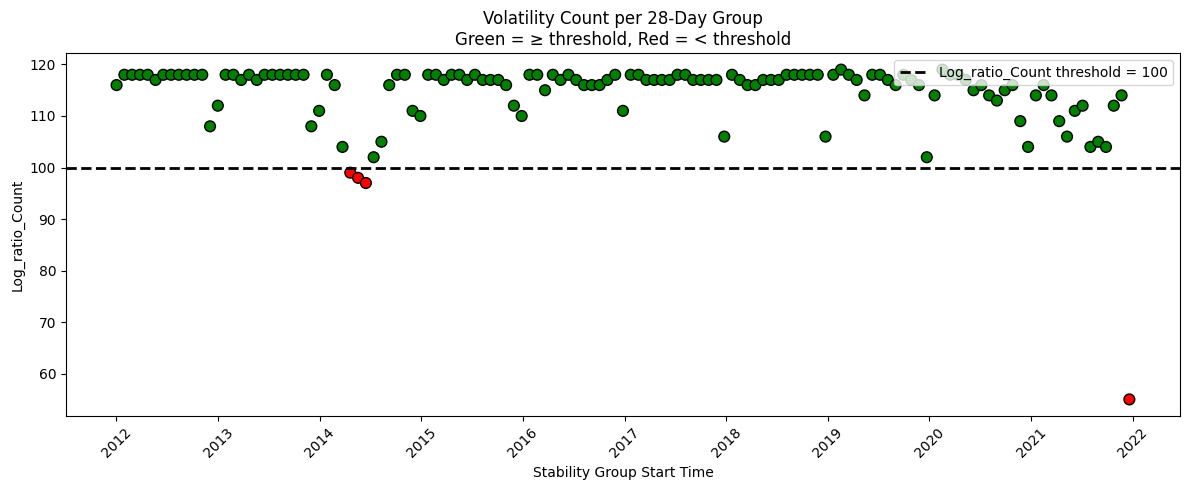

Stability_group_id
2012-01-02    116
2012-01-30    118
2012-02-27    118
2012-03-26    118
2012-04-23    118
             ... 
2021-08-30    105
2021-09-27    104
2021-10-25    112
2021-11-22    114
2021-12-20     55
Name: Log_ratio_Count, Length: 131, dtype: int64

In [54]:
def plot_vol_present_scatter(df_grouped, threshold):
    """
    Plot a scatter of Vol_present per stability group.
    Green = group has enough volatility points (≥ threshold)
    Red = group has too few (< threshold)
    """
    vol_present = df_grouped["Log_ratio_Count"]
    passed = vol_present >= threshold

    plt.figure(figsize=(12, 5))
    plt.scatter(
        vol_present.index, vol_present.values,
        c=['green' if ok else 'red' for ok in passed],
        edgecolor='k', s=60
    )
    plt.axhline(y=threshold, color='black', linestyle='--', linewidth=2,
                label=f"Log_ratio_Count threshold = {threshold}")
    plt.xticks(rotation=45)
    plt.xlabel('Stability Group Start Time')
    plt.ylabel('Log_ratio_Count')
    plt.title('Volatility Count per 28-Day Group\nGreen = ≥ threshold, Red = < threshold')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    return vol_present

plot_vol_present_scatter(grouped_28_day_df, threshold=100)

In [55]:
def plot_log_rvol_ratio_statistics_filtered(df_grouped, threshold):
    """
    Filter groups with sufficient log-rVol ratio counts and plot mean, std dev,
    skewness, and kurtosis of ln(rVol / rVol_p) for those groups only.
    """
    # Filter the DataFrame for groups meeting the threshold
    sufficient_data = df_grouped[df_grouped["Log_ratio_Count"] >= threshold]

    # Set up the subplots
    fig, axs = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

    # Plotting each metric
    axs[0].scatter(sufficient_data.index, sufficient_data['Log_ratio_Mean'], color='blue', s=30)
    axs[0].set_ylabel('Mean')
    axs[0].set_title('Mean of ln(rVol / rVol_p)')
    axs[0].tick_params(labelbottom=True)

    axs[1].scatter(sufficient_data.index, sufficient_data['Log_ratio_Std'], color='orange', s=30)
    axs[1].set_ylabel('Std Dev')
    axs[1].set_title('Std Dev of ln(rVol / rVol_p)')
    axs[1].tick_params(labelbottom=True)

    axs[2].scatter(sufficient_data.index, sufficient_data['Log_ratio_Skew'], color='green', s=30)
    axs[2].set_ylabel('Skewness')
    axs[2].set_title('Skewness of ln(rVol / rVol_p)')
    axs[2].tick_params(labelbottom=True)

    axs[3].scatter(sufficient_data.index, sufficient_data['Log_ratio_Kurtosis'], color='red', s=30)
    axs[3].set_ylabel('Kurtosis')
    axs[3].set_xlabel('Stability Group Start Time')
    axs[3].set_title('Kurtosis of ln(rVol / rVol_p)')

    # Final layout
    plt.suptitle(f'Log-Volatility Ratio Statistics (Groups with ≥ {threshold} Log_ratio_Count)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
   

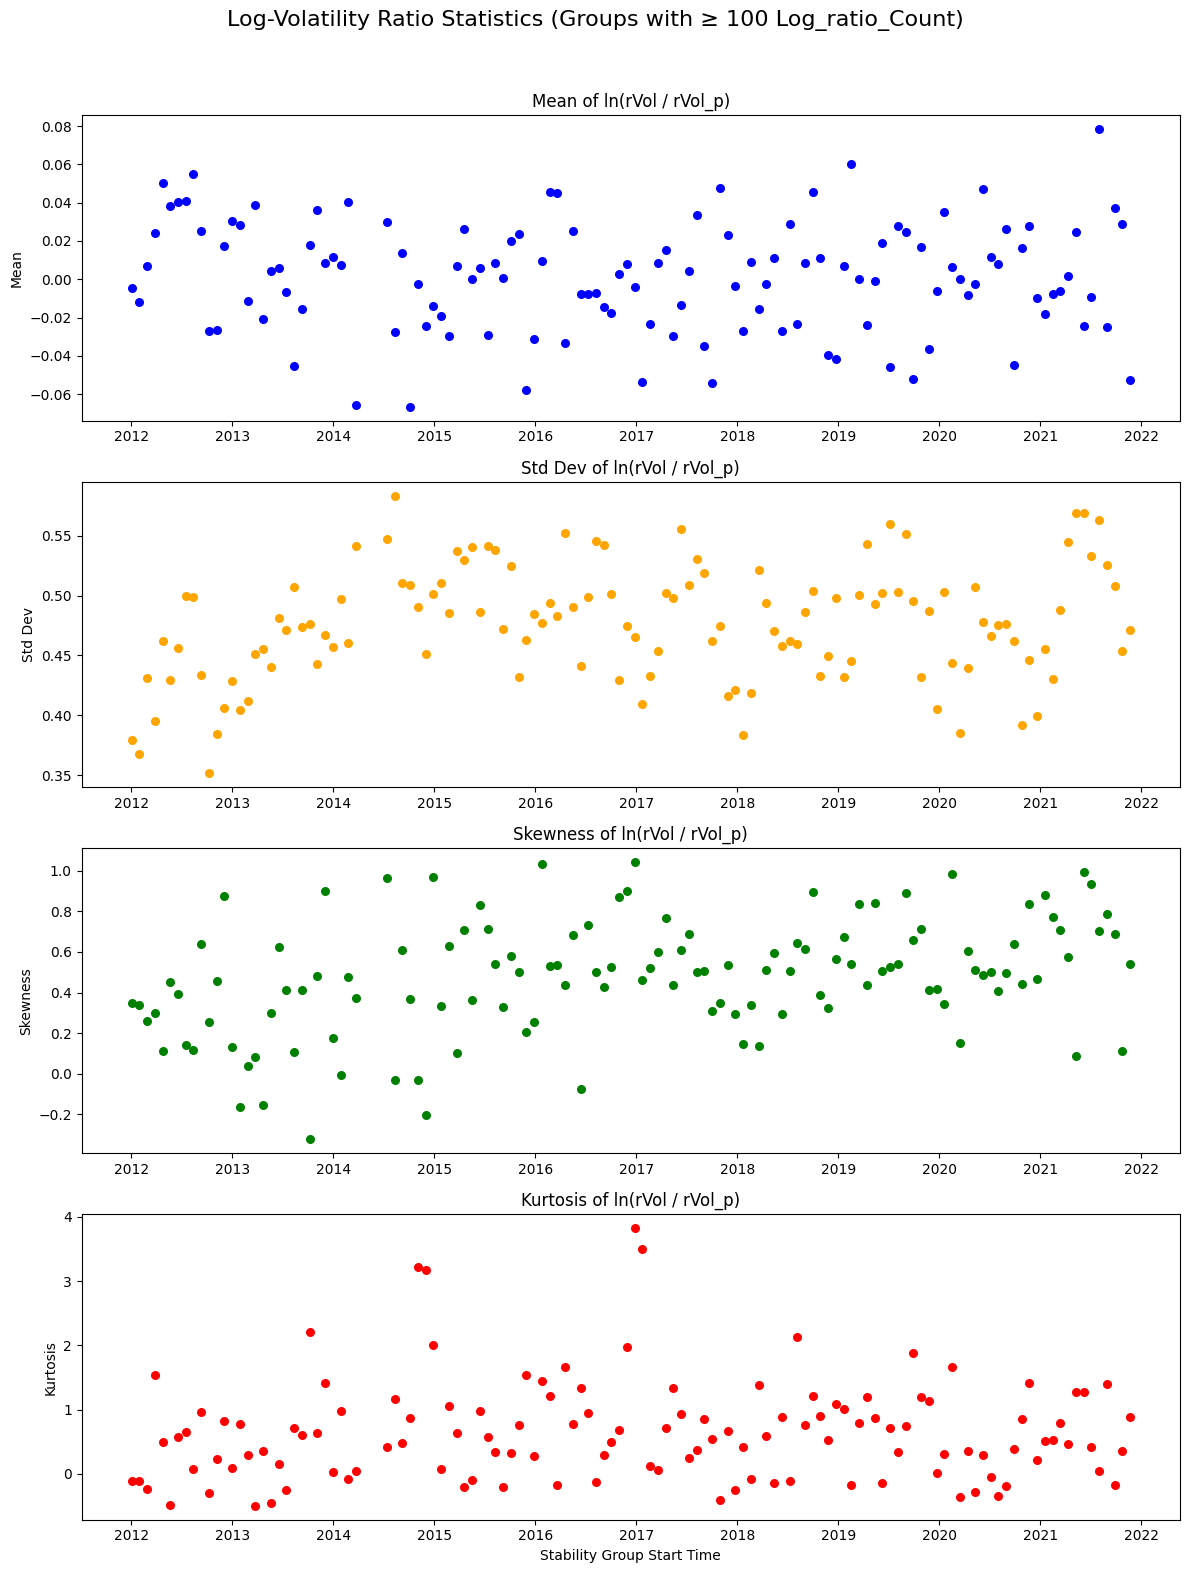

In [56]:
plot_log_rvol_ratio_statistics_filtered(grouped_28_day_df, threshold=100)

In [57]:
grouped_28_day_df

,StartDateTime,EndDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,Vol_mean,Vol_std,Vol_skew,Vol_kurtosis,Log_ratio_Count,Log_ratio_Mean,Log_ratio_Std,Log_ratio_Skew,Log_ratio_Kurtosis,Stability_group_end
Stability_group_id,,,,,,,,,,,,,,,,,,,
2012-01-02,2012-01-02 06:00:00,2012-01-29 23:59:00,1.29454,1.32207,1.26363,1.31766,0.0,63,13857.0,9.685762,4.518176,0.719478,-0.167932,116,-0.004706,0.379195,0.347255,-0.106036,2012-01-29 23:59:59
2012-01-30,2012-01-30 02:00:00,2012-02-26 23:59:00,1.31470,1.34856,1.29736,1.34490,0.0,44,14116.0,9.568767,4.010291,0.967011,1.266636,118,-0.011703,0.367407,0.339280,-0.117092,2012-02-26 23:59:59
2012-02-27,2012-02-27 02:00:00,2012-03-25 23:59:00,1.34419,1.34848,1.30127,1.32648,0.0,52,14108.0,8.255587,3.775521,1.165130,1.772994,118,0.006848,0.430742,0.261494,-0.239877,2012-03-25 23:59:59
2012-03-26,2012-03-26 02:00:00,2012-04-22 23:59:00,1.32567,1.33796,1.30025,1.31914,0.0,62,14098.0,7.968764,3.293604,0.884005,1.173972,118,0.024006,0.395598,0.300208,1.544320,2012-04-22 23:59:59
2012-04-23,2012-04-23 02:00:00,2012-05-20 23:59:00,1.31893,1.32829,1.26545,1.27940,0.0,63,14097.0,7.929951,3.574069,0.803032,0.580965,118,0.050341,0.461963,0.109725,0.501096,2012-05-20 23:59:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-30,2021-08-30 00:00:00,2021-09-26 23:59:00,1.18038,1.19090,1.16834,1.17221,0.0,250,12350.0,4.405455,3.278227,4.618214,30.993077,105,-0.025123,0.525707,0.786024,1.392946,2021-09-26 23:59:59
2021-09-27,2021-09-27 02:00:00,2021-10-24 23:59:00,1.17204,1.17228,1.15242,1.16638,0.0,193,12287.0,4.642152,2.407876,1.545987,4.417007,104,0.037030,0.507749,0.687860,-0.170563,2021-10-24 23:59:59
2021-10-25,2021-10-25 02:00:00,2021-11-21 23:59:00,1.16569,1.16899,1.12499,1.12780,0.0,213,13227.0,5.388936,3.343728,2.018100,5.939758,112,0.028708,0.453642,0.111844,0.358381,2021-11-21 23:59:59


In [58]:
RS_120m_rvol

,group_id,StartDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,RVol_120min_Rogers-Satchell,Prev_Close_global,Log_Returns_global
EndDateTime,,,,,,,,,,,,
2012-01-02 03:59:00,2012-01-02 02:00:00,2012-01-02 02:00:00,1.29324,1.29531,1.29275,1.29383,0.0,1,119.0,9.658213,1.29324,0.000456
2012-01-02 05:59:00,2012-01-02 04:00:00,2012-01-02 04:00:00,1.29384,1.29709,1.29381,1.29457,0.0,1,119.0,12.216589,1.29383,0.000572
2012-01-02 07:59:00,2012-01-02 06:00:00,2012-01-02 06:00:00,1.29454,1.29514,1.29311,1.29381,0.0,2,118.0,6.511085,1.29457,-0.000587
2012-01-02 09:59:00,2012-01-02 08:00:00,2012-01-02 08:00:00,1.29382,1.29442,1.29227,1.29327,0.0,4,116.0,7.580019,1.29381,-0.000417
2012-01-02 11:59:00,2012-01-02 10:00:00,2012-01-02 10:00:00,1.29325,1.29413,1.29167,1.29197,0.0,6,114.0,6.842128,1.29327,-0.001006
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 07:59:00,2021-12-31 06:00:00,2021-12-31 06:00:00,1.13248,1.13349,1.13120,1.13252,0.0,0,120.0,6.169781,1.13248,0.000035
2021-12-31 09:59:00,2021-12-31 08:00:00,2021-12-31 08:00:00,1.13253,1.13534,1.13191,1.13437,0.0,0,120.0,10.520242,1.13252,0.001632
2021-12-31 11:59:00,2021-12-31 10:00:00,2021-12-31 10:00:00,1.13438,1.13796,1.13379,1.13790,0.0,0,120.0,12.417189,1.13437,0.003107


C:\Users\phani\AppData\Local\Temp\ipykernel_24880\2865826790.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Prev_Close_global'].fillna(data['Open'], inplace=True)
C:\Users\phani\AppData\Local\Temp\ipykernel_24880\4174277596.py:13: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ohlc['group_id'] = ohlc.index.floor(f"{timeframe}T")


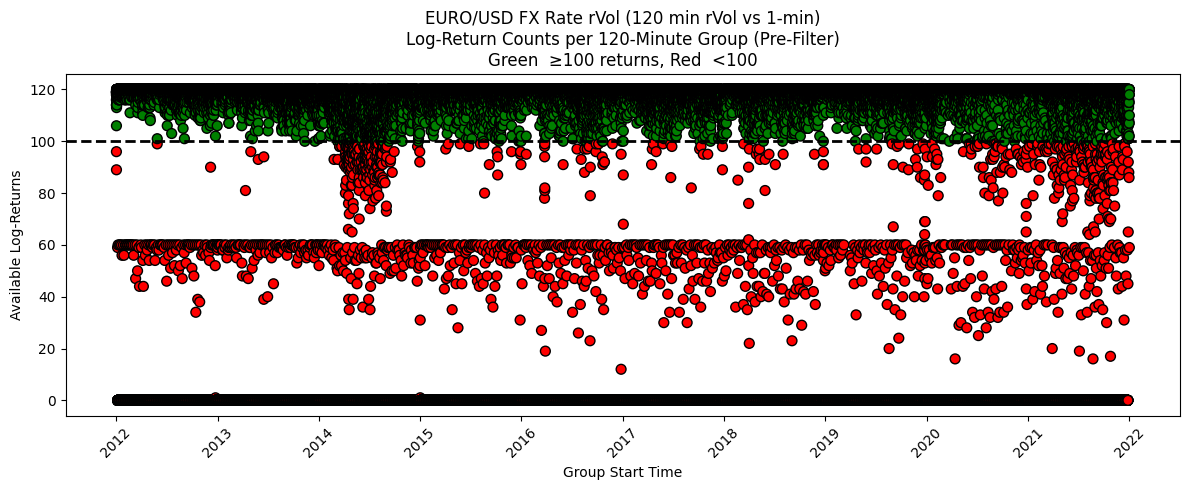

Keeping 29979 groups (the green ones) out of 43820 total.


C:\Users\phani\AppData\Local\Temp\ipykernel_24880\2441554807.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: compute_volatility_measure(grp, vol_measure))


                              sum  count
group_id                                
2012-01-02 02:00:00  2.390660e-06    119
2012-01-02 04:00:00  6.528883e-06    119
2012-01-02 06:00:00  1.139618e-06    118
2012-01-02 08:00:00  1.449495e-06    116
2012-01-02 10:00:00  9.088269e-07    114
...                           ...    ...
2021-12-31 06:00:00  1.954066e-06    120
2021-12-31 08:00:00  3.623978e-06    120
2021-12-31 10:00:00  7.476214e-06    120
2021-12-31 12:00:00  5.878490e-07    118
2021-12-31 14:00:00  3.586935e-07    110

[29979 rows x 2 columns]


C:\Users\phani\AppData\Local\Temp\ipykernel_24880\779989498.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Prev_Close_global'].fillna(data['Open_first'], inplace=True)


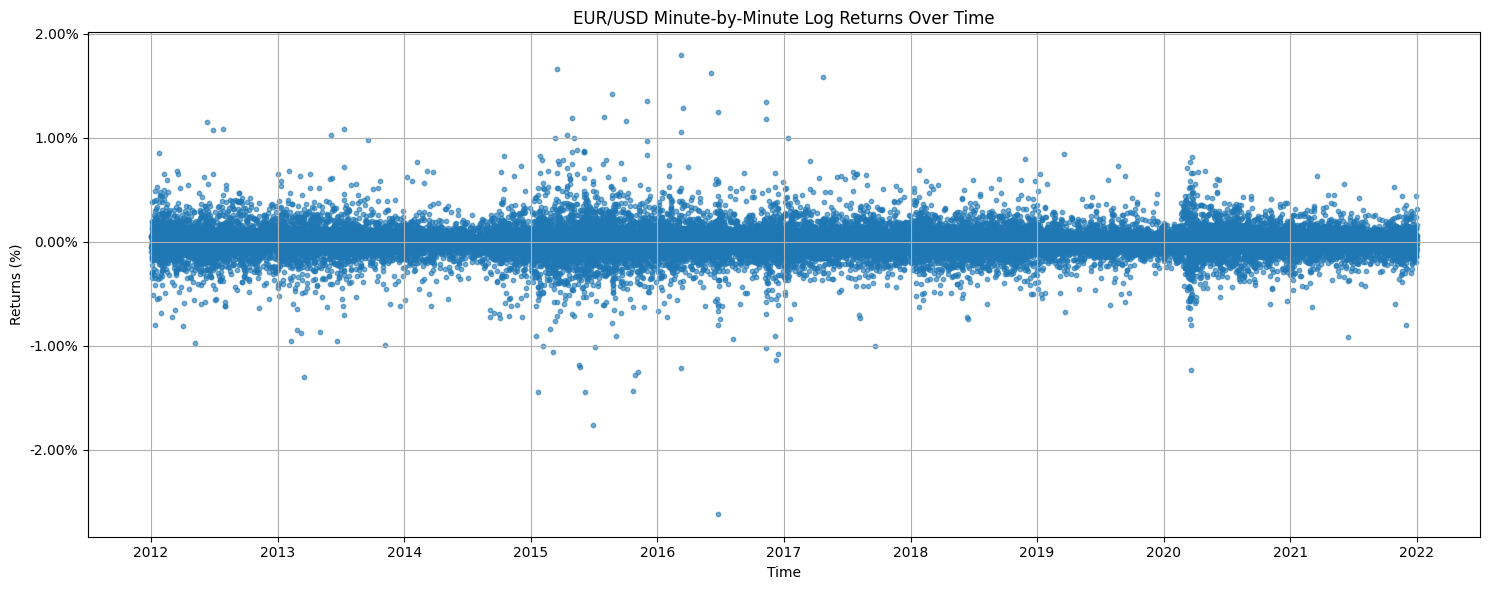

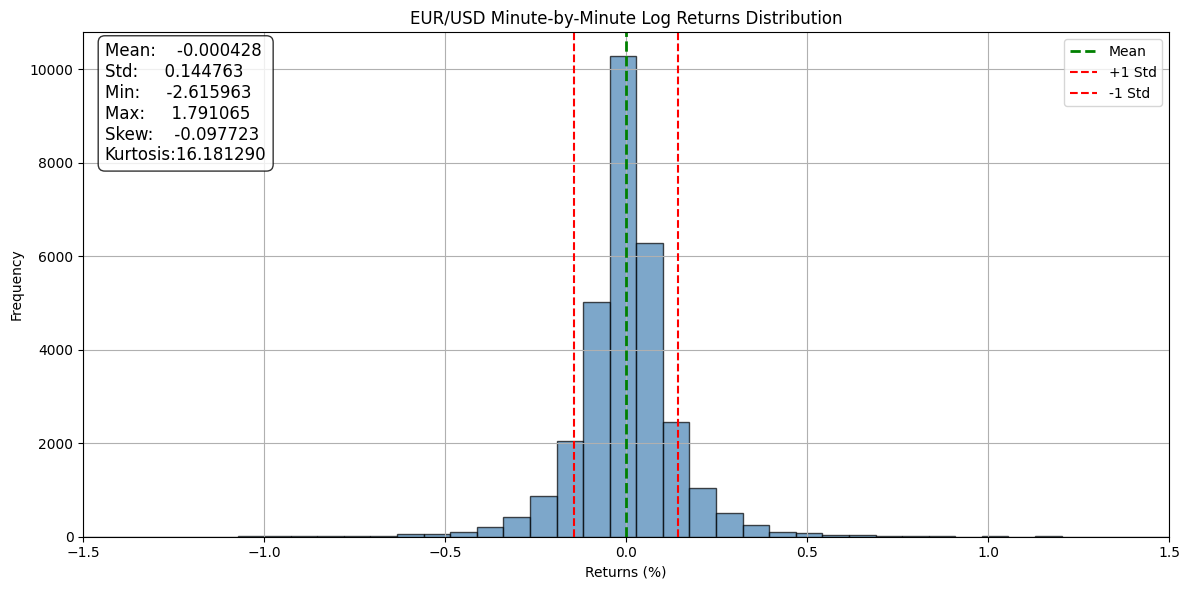

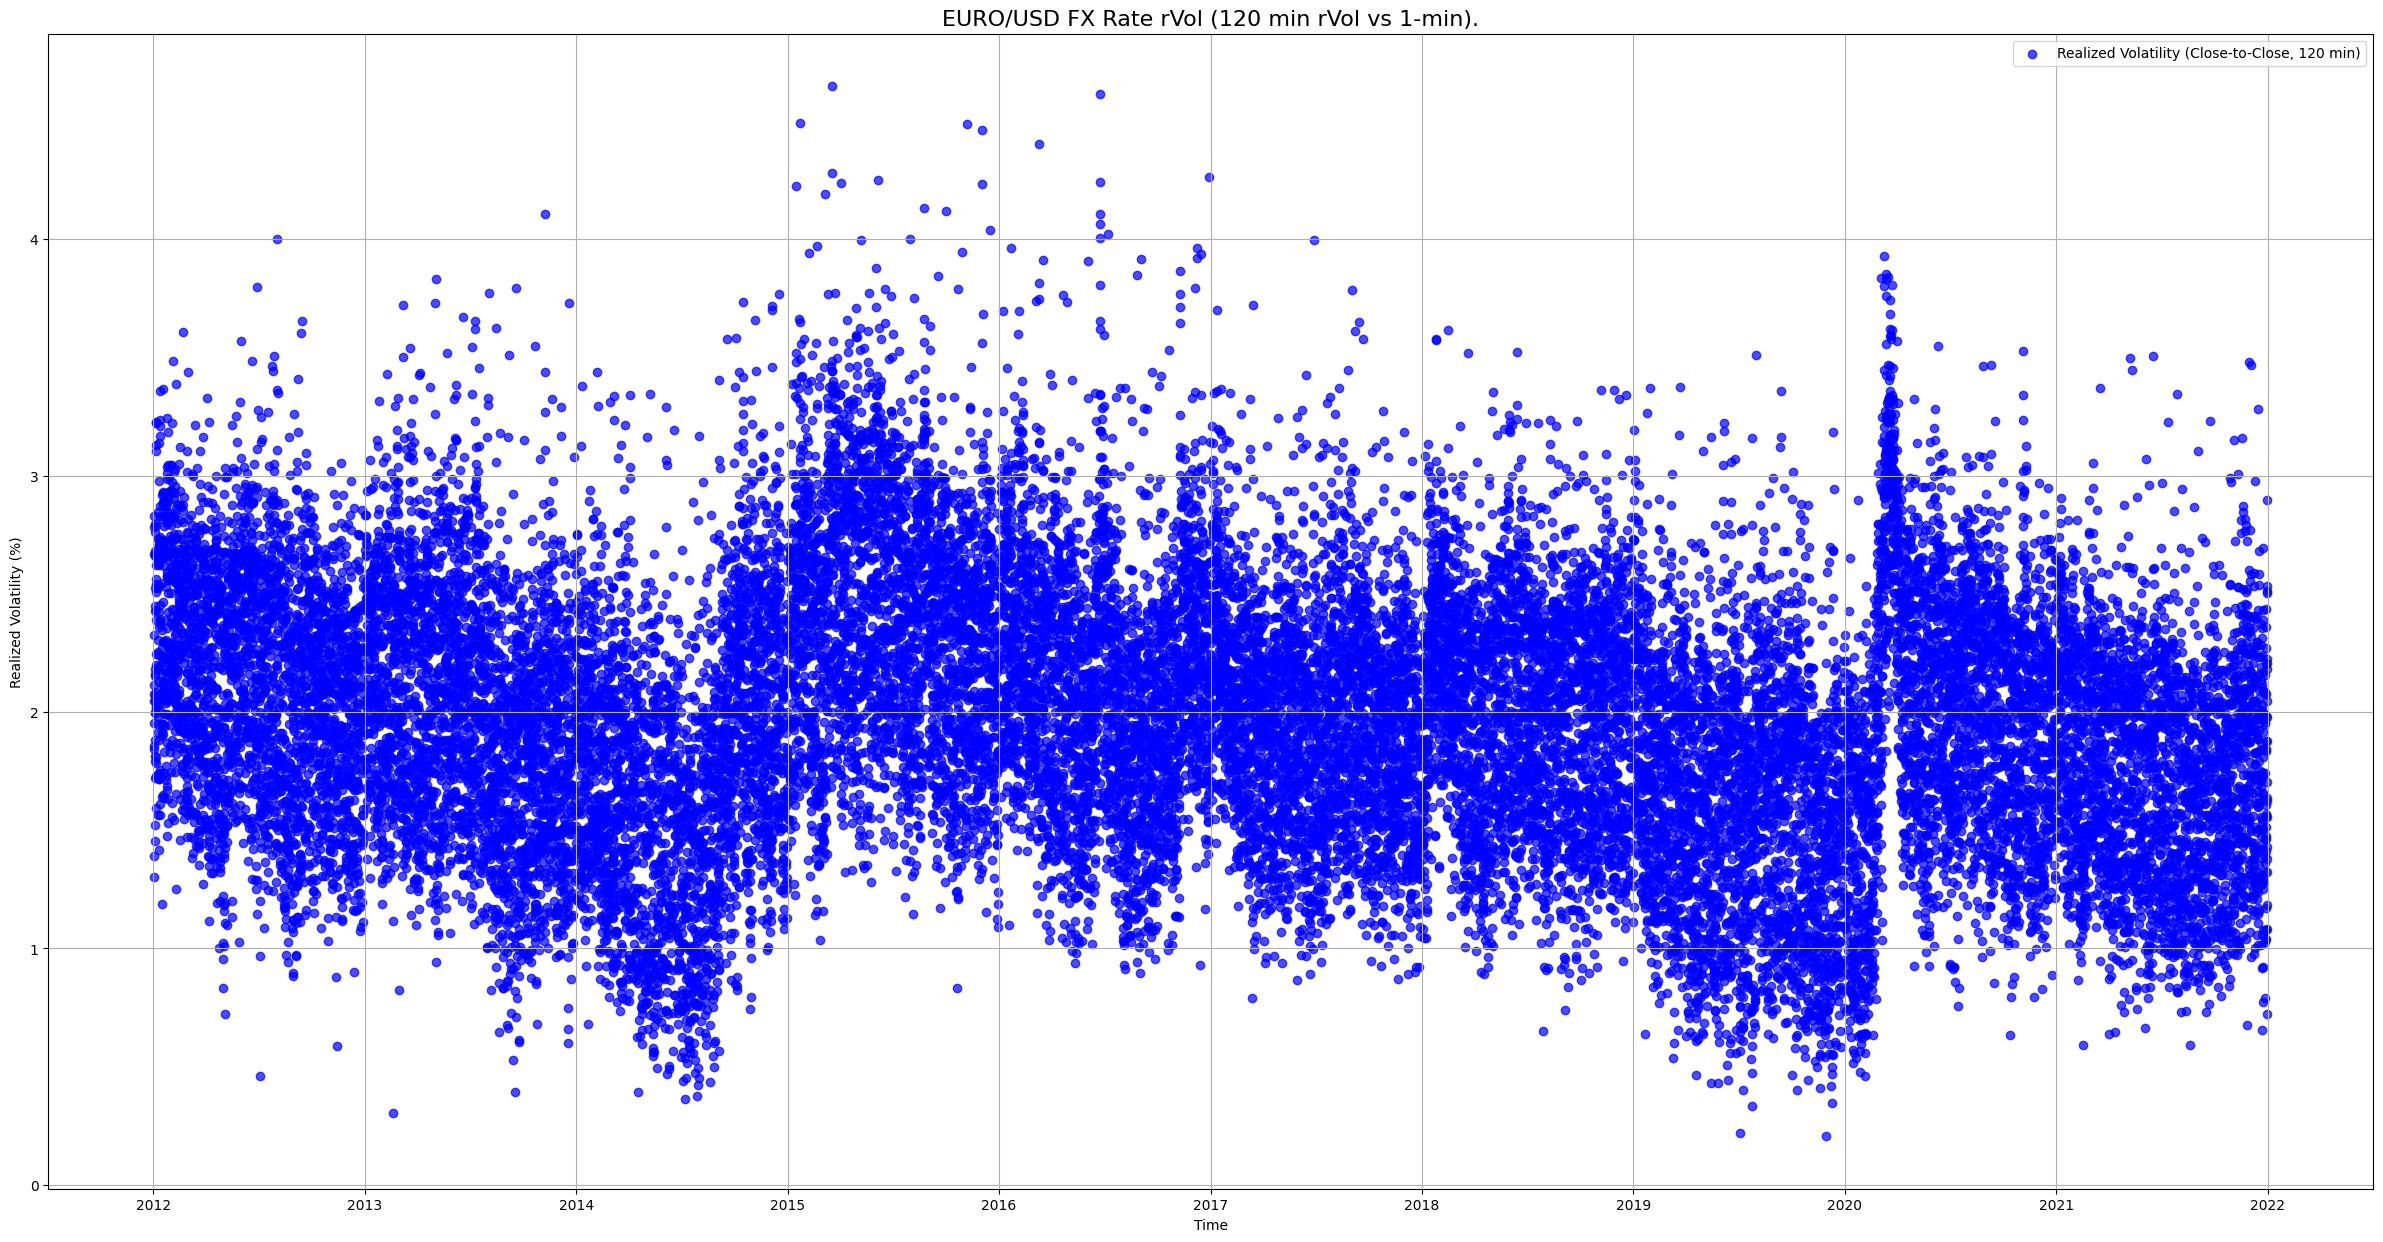

                 group_id       StartDateTime         EndDateTime  Open_first  \
0     2012-01-02 02:00:00 2012-01-02 02:00:00 2012-01-02 03:59:00     1.29324   
1     2012-01-02 04:00:00 2012-01-02 04:00:00 2012-01-02 05:59:00     1.29384   
2     2012-01-02 06:00:00 2012-01-02 06:00:00 2012-01-02 07:59:00     1.29454   
3     2012-01-02 08:00:00 2012-01-02 08:00:00 2012-01-02 09:59:00     1.29382   
4     2012-01-02 10:00:00 2012-01-02 10:00:00 2012-01-02 11:59:00     1.29325   
...                   ...                 ...                 ...         ...   
29974 2021-12-31 06:00:00 2021-12-31 06:00:00 2021-12-31 07:59:00     1.13248   
29975 2021-12-31 08:00:00 2021-12-31 08:00:00 2021-12-31 09:59:00     1.13253   
29976 2021-12-31 10:00:00 2021-12-31 10:00:00 2021-12-31 11:59:00     1.13438   
29977 2021-12-31 12:00:00 2021-12-31 12:00:00 2021-12-31 13:59:00     1.13790   
29978 2021-12-31 14:00:00 2021-12-31 14:00:00 2021-12-31 15:59:00     1.13848   

       High_max  Low_min  C

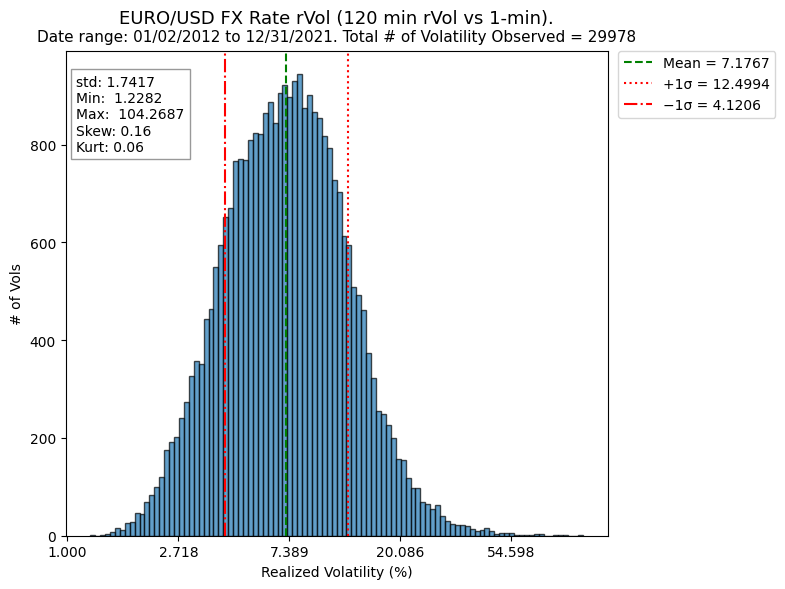

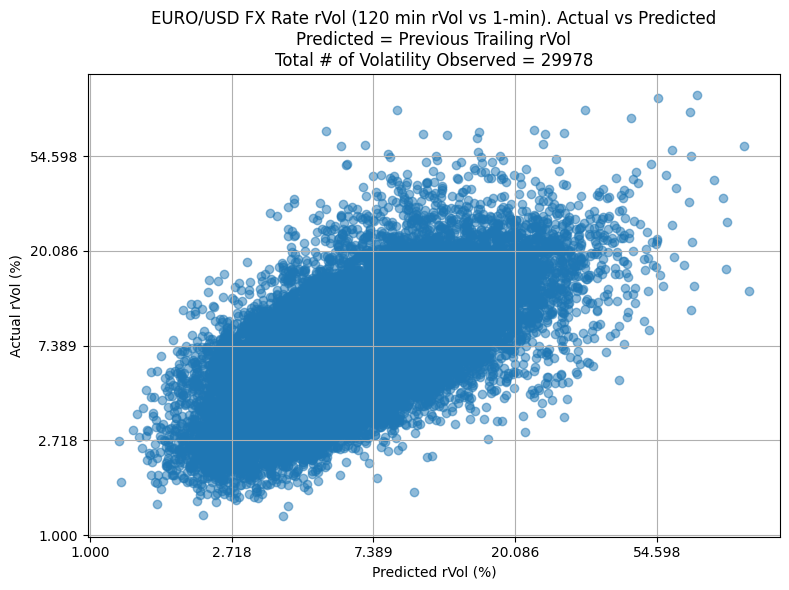

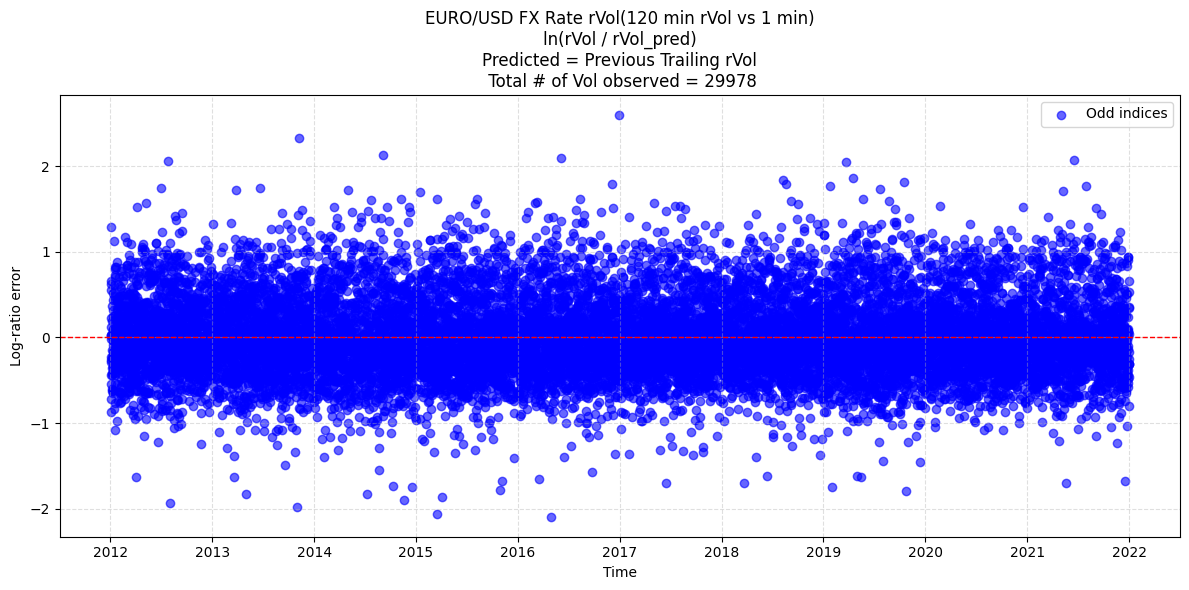

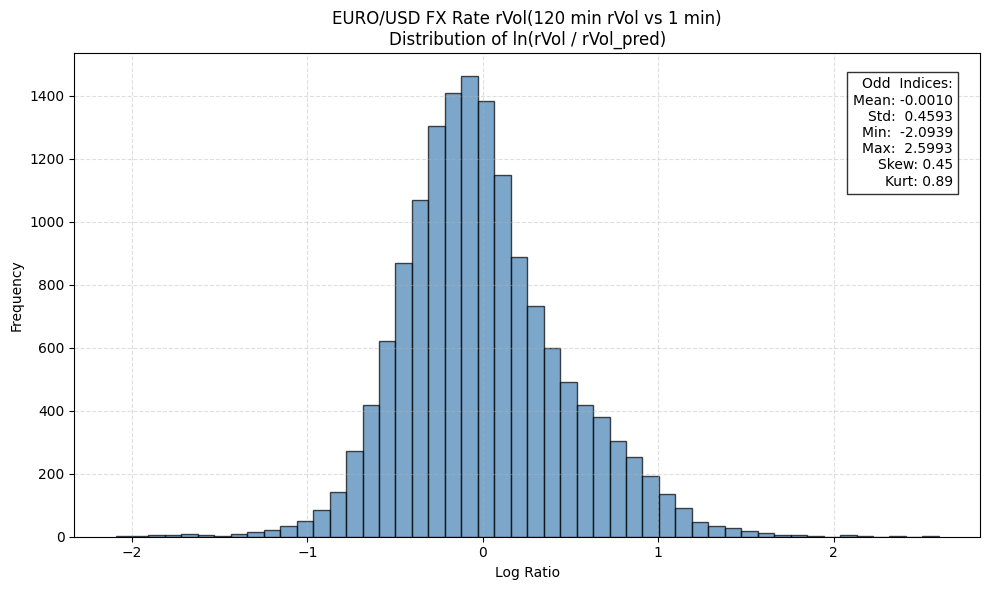

In [59]:
CC_120m_rvol = calculate_rvol(data, 
                              vol_measure = 'Close-to-Close', 
                              timeframe = 120, 
                              minute_interval = 1, 
                              threshold = 0.1667, 
                              vol_title = 'RVol_120min_Close-to-Close') # Choose 'Garman-Klass', 'Rogers-Satchell', or 'Close-to-Close'

In [60]:
CC_120m_rvol

,group_id,StartDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,RVol_120min_Close-to-Close,Prev_Close_global,Log_Returns_global
EndDateTime,,,,,,,,,,,,
2012-01-02 03:59:00,2012-01-02 02:00:00,2012-01-02 02:00:00,1.29324,1.29531,1.29275,1.29383,0.0,1,119.0,10.232835,1.29324,0.000456
2012-01-02 05:59:00,2012-01-02 04:00:00,2012-01-02 04:00:00,1.29384,1.29709,1.29381,1.29457,0.0,1,119.0,16.910501,1.29383,0.000572
2012-01-02 07:59:00,2012-01-02 06:00:00,2012-01-02 06:00:00,1.29454,1.29514,1.29311,1.29381,0.0,2,118.0,7.065073,1.29457,-0.000587
2012-01-02 09:59:00,2012-01-02 08:00:00,2012-01-02 08:00:00,1.29382,1.29442,1.29227,1.29327,0.0,4,116.0,7.967928,1.29381,-0.000417
2012-01-02 11:59:00,2012-01-02 10:00:00,2012-01-02 10:00:00,1.29325,1.29413,1.29167,1.29197,0.0,6,114.0,6.309249,1.29327,-0.001006
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 07:59:00,2021-12-31 06:00:00,2021-12-31 06:00:00,1.13248,1.13349,1.13120,1.13252,0.0,0,120.0,9.251383,1.13248,0.000035
2021-12-31 09:59:00,2021-12-31 08:00:00,2021-12-31 08:00:00,1.13253,1.13534,1.13191,1.13437,0.0,0,120.0,12.598818,1.13252,0.001632
2021-12-31 11:59:00,2021-12-31 10:00:00,2021-12-31 10:00:00,1.13438,1.13796,1.13379,1.13790,0.0,0,120.0,18.095806,1.13437,0.003107


In [61]:
CC_grouped_28_day_df = generate_28_day_stability_groups(CC_120m_rvol, vol_col='RVol_120min_Close-to-Close', stability_days=28)
CC_grouped_28_day_df

,StartDateTime,EndDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,Vol_mean,Vol_std,Vol_skew,Vol_kurtosis,Log_ratio_Count,Log_ratio_Mean,Log_ratio_Std,Log_ratio_Skew,Log_ratio_Kurtosis,Stability_group_end
Stability_group_id,,,,,,,,,,,,,,,,,,,
2012-01-02,2012-01-02 06:00:00,2012-01-29 23:59:00,1.29454,1.32207,1.26363,1.31766,0.0,63,13857.0,11.363851,5.380493,0.811949,0.126110,116,-0.022908,0.440187,0.302718,0.308562,2012-01-29 23:59:59
2012-01-30,2012-01-30 02:00:00,2012-02-26 23:59:00,1.31470,1.34856,1.29736,1.34490,0.0,44,14116.0,11.498736,5.017571,1.685293,5.623216,118,-0.005692,0.375789,0.207580,0.075776,2012-02-26 23:59:59
2012-02-27,2012-02-27 02:00:00,2012-03-25 23:59:00,1.34419,1.34848,1.30127,1.32648,0.0,52,14108.0,10.000481,4.677317,1.416887,3.273535,118,0.013626,0.450263,0.335899,-0.503576,2012-03-25 23:59:59
2012-03-26,2012-03-26 02:00:00,2012-04-22 23:59:00,1.32567,1.33796,1.30025,1.31914,0.0,62,14098.0,9.352005,4.186605,0.857649,0.687352,118,0.002539,0.456951,-0.121160,1.242142,2012-04-22 23:59:59
2012-04-23,2012-04-23 02:00:00,2012-05-20 23:59:00,1.31893,1.32829,1.26545,1.27940,0.0,63,14097.0,9.030657,4.098333,0.544821,-0.190651,118,0.028532,0.504246,0.398045,0.189935,2012-05-20 23:59:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-30,2021-08-30 00:00:00,2021-09-26 23:59:00,1.18038,1.19090,1.16834,1.17221,0.0,250,12350.0,5.370300,3.351448,3.534899,17.335737,105,-0.034425,0.472056,0.723629,1.187733,2021-09-26 23:59:59
2021-09-27,2021-09-27 02:00:00,2021-10-24 23:59:00,1.17204,1.17228,1.15242,1.16638,0.0,193,12287.0,5.754496,2.431258,1.034149,1.117190,104,0.036381,0.411487,0.650371,0.098564,2021-10-24 23:59:59
2021-10-25,2021-10-25 02:00:00,2021-11-21 23:59:00,1.16569,1.16899,1.12499,1.12780,0.0,213,13227.0,6.727169,3.912039,1.968809,4.631635,112,0.012187,0.435226,0.143508,0.291165,2021-11-21 23:59:59


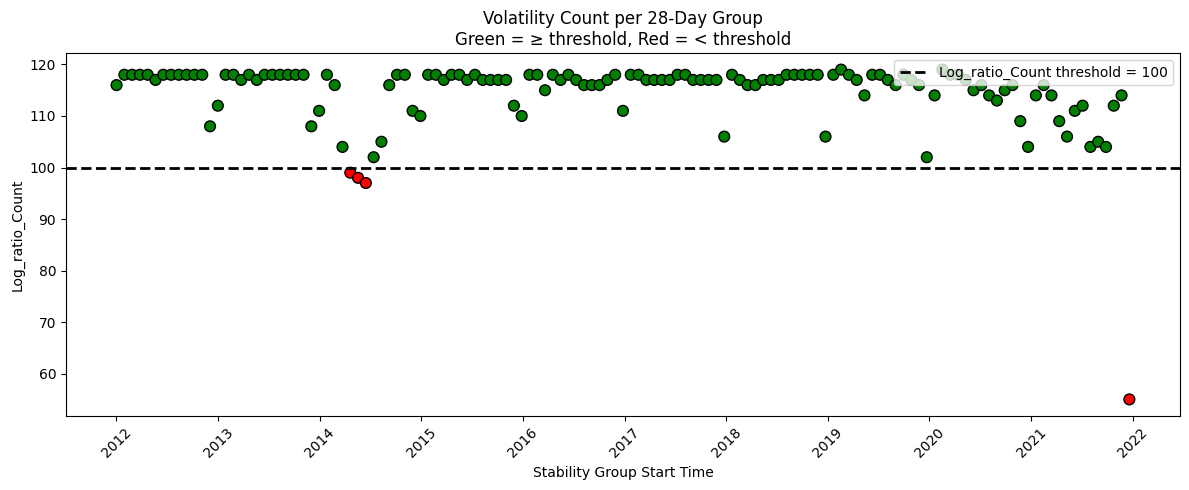

Stability_group_id
2012-01-02    116
2012-01-30    118
2012-02-27    118
2012-03-26    118
2012-04-23    118
             ... 
2021-08-30    105
2021-09-27    104
2021-10-25    112
2021-11-22    114
2021-12-20     55
Name: Log_ratio_Count, Length: 131, dtype: int64

In [62]:
plot_vol_present_scatter(CC_grouped_28_day_df, threshold=100)

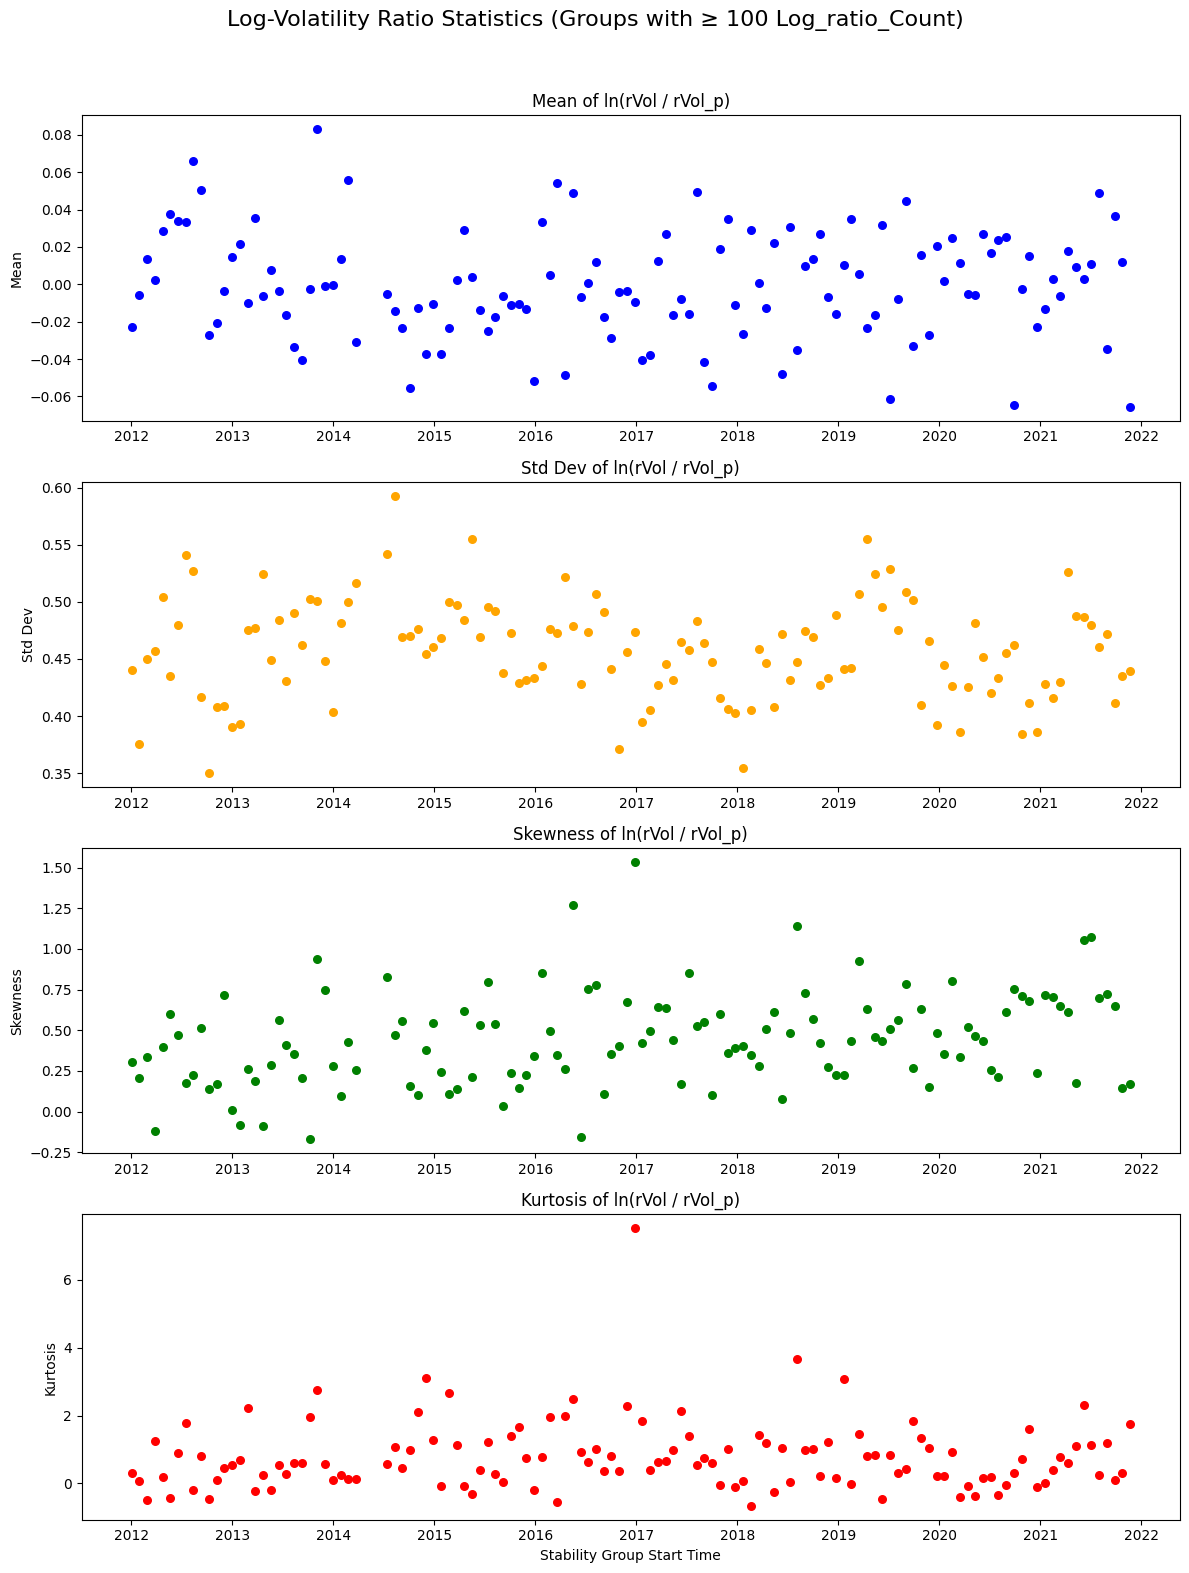

In [63]:
plot_log_rvol_ratio_statistics_filtered(CC_grouped_28_day_df, threshold=100)

In [64]:
'''import numpy as np
from scipy.optimize import minimize

# ------------------------------
# Function: Add Predicted Volatility
# ------------------------------
# Formula used:
#   Predicted_Vol = sqrt( alpha * (Prev_Vol)^2 + (1 - alpha) * (Yesterday_Vol)^2 )
#
# Where:
#   - Prev_Vol        = volatility from the previous time step (previous bar)
#   - Yesterday_Vol   = volatility from the SAME TIME yesterday
#   - alpha           = weight parameter (between 0 and 1)
#
# Idea:
#   We are blending two volatilities:
#     ✔️ Prev_Vol (recent movement)
#     ✔️ Yesterday_Vol (same time yesterday for intraday pattern capture)
#   The weight alpha decides which one dominates.
# ------------------------------

def add_predicted_vol_single_alpha(df, vol_col, alpha, steps_per_day):
    """
    Add a new column 'Predicted_Vol' to the dataframe based on the alpha-weighted formula.

    Parameters:
        df (pd.DataFrame): Input dataframe with volatility column
        vol_col (str): Column name containing realized volatility values
        alpha (float): Weight parameter (0 < alpha < 1)
        steps_per_day (int): Number of rows in one trading day (e.g., 12 for 2-hour bars in 24h FX)

    Returns:
        pd.DataFrame: Dataframe with an added 'Predicted_Vol' column
    """
    df = df.copy()
    df['Predicted_Vol'] = np.nan  # initialize empty column

    for i in range(steps_per_day, len(df)):
        prev_vol = df[vol_col].iloc[i - 1]          # previous time step volatility
        yesterday_vol = df[vol_col].iloc[i - steps_per_day]  # same time yesterday volatility

        # Skip if either value is missing
        if np.isnan(prev_vol) or np.isnan(yesterday_vol):
            continue

        # Apply formula
        df.loc[df.index[i], 'Predicted_Vol'] = np.sqrt(
            alpha * (prev_vol ** 2) + (1 - alpha) * (yesterday_vol ** 2)
        )

    return df


# ------------------------------
# Function: Objective Function for Optimization
# ------------------------------
# Goal:
#   Find the alpha that makes predicted volatility stable compared to actual volatility.
#
# Approach:
#   - Compute Predicted Vol using current alpha
#   - Compute log ratio: ln(Actual_Vol / Predicted_Vol)
#   - Minimize standard deviation of this log ratio
#
# Why?
#   If Predicted_Vol tracks Actual_Vol well, the log ratio should stay close to 0, log 1 = 0
#   and its standard deviation will be small.
# ------------------------------

def std_log_ratio_objective_single_alpha(params, df, vol_col, steps_per_day):
    alpha = params[0]

    # Ensure alpha is valid
    if not (0 < alpha < 1):
        return np.inf  # invalid alpha → penalize with infinity

    try:
        # Generate predicted vol for given alpha
        df_temp = add_predicted_vol_single_alpha(df, vol_col, alpha, steps_per_day)

        # Drop NaNs and infinities
        actual = df_temp[vol_col].replace([np.inf, -np.inf], np.nan).dropna()
        pred = df_temp['Predicted_Vol'].replace([np.inf, -np.inf], np.nan).dropna()

        # Align indices so we compare the same timestamps
        common_idx = actual.index.intersection(pred.index)
        actual = actual.loc[common_idx]
        pred = pred.loc[common_idx]

        # Need at least 2 points to compute std deviation
        if len(actual) < 2:
            return np.inf

        # Calculate log ratio
        log_ratio = np.log(actual / pred)

        # Objective = standard deviation of log ratio
        return log_ratio.std()

    except Exception:
        return np.inf  # any error → penalize


# ------------------------------
# Function: Optimize Alpha
# ------------------------------
# Uses scipy's "minimize" to find the alpha value
# that minimizes the std deviation of log ratio.
# ------------------------------

def optimize_alpha(df, vol_col='RVol_120min_Close-to-Close', steps_per_day=12, initial_guess=0.1):
    """
    Optimize alpha to minimize volatility prediction error.

    Parameters:
        df (pd.DataFrame): Input dataframe with volatility data
        vol_col (str): Column containing realized volatility
        steps_per_day (int): Number of steps in one trading day (depends on frequency)
        initial_guess (float): Starting guess for alpha

    Returns:
        dict: Best parameters (alpha, std error)
    """
    bounds = [(0.01, 0.99)]  # keep alpha between 0.01 and 0.99

    result = minimize(
        std_log_ratio_objective_single_alpha,
        x0=[initial_guess],
        args=(df, vol_col, steps_per_day),
        bounds=bounds,
        method='L-BFGS-B'
    )

    if result.success:
        alpha_opt = result.x[0]
        print("✅ Optimization Successful")
        print(f"Best alpha:           {alpha_opt:.4f}")
        print(f"Fixed steps_per_day:  {steps_per_day}")
        print(f"Min Std of ln(rVol / rVol_pred): {result.fun:.6f}")

        return {
            'alpha': alpha_opt,
            'steps_per_day': steps_per_day,
            'std': result.fun
        }
    else:
        print("❌ Optimization failed:", result.message)
        return None


# ------------------------------
# Example Usage
# ------------------------------
# For EURUSD 2-hour bars:
#   - 24 hours / 2 hours = 12 steps per day
#   - So steps_per_day = 12
# ------------------------------

# Example call (assuming dataframe = CC_120m_rvol)
best_params = optimize_alpha(CC_120m_rvol, vol_col='RVol_120min_Close-to-Close', steps_per_day=12)'''



'import numpy as np\nfrom scipy.optimize import minimize\n\n# ------------------------------\n# Function: Add Predicted Volatility\n# ------------------------------\n# Formula used:\n#   Predicted_Vol = sqrt( alpha * (Prev_Vol)^2 + (1 - alpha) * (Yesterday_Vol)^2 )\n#\n# Where:\n#   - Prev_Vol        = volatility from the previous time step (previous bar)\n#   - Yesterday_Vol   = volatility from the SAME TIME yesterday\n#   - alpha           = weight parameter (between 0 and 1)\n#\n# Idea:\n#   We are blending two volatilities:\n#     ✔️ Prev_Vol (recent movement)\n#     ✔️ Yesterday_Vol (same time yesterday for intraday pattern capture)\n#   The weight alpha decides which one dominates.\n# ------------------------------\n\ndef add_predicted_vol_single_alpha(df, vol_col, alpha, steps_per_day):\n    """\n    Add a new column \'Predicted_Vol\' to the dataframe based on the alpha-weighted formula.\n\n    Parameters:\n        df (pd.DataFrame): Input dataframe with volatility column\n     

In [65]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd

# -------------------------------
# Function to add predicted vol column using only alpha
# Corrects "yesterday same time" logic using (Date, Slot)
# -------------------------------
def add_predicted_vol_single_alpha(df, vol_col, alpha, max_days):
    df = df.copy()
    df.sort_values('StartDateTime', inplace=True)  # ensure data is sorted by time
    df['Predicted_Vol'] = np.nan

    # Extract time-of-day and date for each row
    df['Slot'] = df['StartDateTime'].dt.time
    df['Date'] = df['StartDateTime'].dt.date

    # Previous period volatility (previous row)
    df['Prev_Vol'] = df[vol_col].shift(1)

    # Build a quick-access dictionary {(Date, Slot): vol} to get yesterday same-time vol
    slot_vol_map = df.set_index(['Date', 'Slot'])[vol_col].to_dict()

    # List to store yesterday same-time volatility
    yesterday_vols = []

    for idx, row in df.iterrows():
        current_date = row['Date']
        current_slot = row['Slot']

        # Look back max_days to get "yesterday same time"
        past_date = current_date - pd.Timedelta(days=max_days)
        key = (past_date, current_slot)

        if key in slot_vol_map:
            yesterday_vols.append(slot_vol_map[key])
        else:
            yesterday_vols.append(np.nan)

    # Add yesterday same-time vol to dataframe
    df['Yesterday_Slot_Vol'] = yesterday_vols

    # Calculate predicted volatility
    # Formula: sqrt(alpha * prev_vol^2 + (1-alpha) * yesterday_same_time_vol^2)
    df['Predicted_Vol'] = np.sqrt(
        alpha * (df['Prev_Vol'] ** 2) + (1 - alpha) * (df['Yesterday_Slot_Vol'] ** 2) #The formula
    )

    return df

# -------------------------------
# Objective function: minimize std deviation of log(actual/predicted)
# -------------------------------
def std_log_ratio_objective_single_alpha(params, df, vol_col, max_days):
    alpha = params[0]

    # Ensure alpha is between 0 and 1
    if not (0 < alpha < 1):
        return np.inf

    try:
        df_temp = add_predicted_vol_single_alpha(df, vol_col, alpha, max_days)

        actual = df_temp[vol_col].replace([np.inf, -np.inf], np.nan).dropna()
        pred = df_temp['Predicted_Vol'].replace([np.inf, -np.inf], np.nan).dropna()

        # Only keep indices common to actual and predicted
        common_idx = actual.index.intersection(pred.index)
        actual = actual.loc[common_idx]
        pred = pred.loc[common_idx]

        if len(actual) < 2:
            return np.inf

        log_ratio = np.log(actual / pred)
        return log_ratio.std()  # objective: minimize std of log ratio

    except Exception:
        return np.inf

# -------------------------------
# Optimization function to find best alpha
# -------------------------------
def optimize_alpha(df, vol_col='RVol_120min_Close-to-Close', max_days=1, initial_guess=0.1):
    bounds = [(0.01, 0.99)]  # alpha must be between 0.01 and 0.99

    result = minimize(
        std_log_ratio_objective_single_alpha,
        x0=[initial_guess],
        args=(df, vol_col, max_days),
        bounds=bounds,
        method='L-BFGS-B'
    )

    if result.success:
        alpha_opt = result.x[0]
        print("✅ Optimization Successful")
        print(f"Best alpha:     {alpha_opt:.4f}")
        print(f"Fixed max_days: {max_days}")
        print(f"Min Std of ln(rVol / rVol_pred): {result.fun:.6f}")
        return {
            'alpha': alpha_opt,
            'max_days': max_days,
            'std': result.fun
        }
    else:
        print("❌ Optimization failed:", result.message)
        return None

# -------------------------------
# Example usage
# -------------------------------
best_params = optimize_alpha(CC_120m_rvol, max_days=1)


✅ Optimization Successful
Best alpha:     0.3329
Fixed max_days: 1
Min Std of ln(rVol / rVol_pred): 0.354445


In [66]:
# -------------------------------
# Optimize alpha for a given group
# -------------------------------
def optimize_alpha_on_group(df_group, vol_col='RVol_120min_Close-to-Close', max_days=1):
    from scipy.optimize import minimize

    # Objective function: minimize std deviation of log(actual/predicted)
    def obj(alpha_array):
        return std_log_ratio_objective_single_alpha(alpha_array, df_group, vol_col, max_days)

    # Optimize only alpha
    result = minimize(
        obj,
        x0=[0.3],  # initial guess
        bounds=[(0.01, 0.99)],  # alpha between 0.01 and 0.99
        method='L-BFGS-B'
    )

    if result.success:
        return result.x[0], result.fun
    else:
        return np.nan, np.nan

# -------------------------------
# Rolling 28-day backtest for stability
# -------------------------------
def rolling_stability_backtest(full_df, vol_col='RVol_120min_Close-to-Close', stability_days=28, max_days=1):
    full_df = full_df.copy()
    full_df.sort_index(inplace=True)

    # Assign stability group ID (each group = stability_days)
    start_time = full_df.index.min().floor('D')
    full_df['Stability_group_id'] = ((full_df.index - start_time) // pd.Timedelta(days=stability_days)) \
                                    * pd.Timedelta(days=stability_days) + start_time

    group_ids = sorted(full_df['Stability_group_id'].unique())
    results = []

    # Loop through each pair of train-test groups
    for i in range(len(group_ids) - 1):
        train_id = group_ids[i]
        test_id = group_ids[i + 1]

        train_data = full_df[full_df['Stability_group_id'] == train_id]
        test_data  = full_df[full_df['Stability_group_id'] == test_id]

        # -------------------------------
        # Step 1: Optimize alpha on training data
        # -------------------------------
        alpha, train_std = optimize_alpha_on_group(train_data, vol_col=vol_col, max_days=max_days)
        if np.isnan(alpha):
            continue  # skip if optimization failed

        # -------------------------------
        # Step 2: Apply the same alpha to test data
        # -------------------------------
        try:
            test_copy = add_predicted_vol_single_alpha(test_data, vol_col, alpha, max_days)
            test_copy['log_ratio'] = np.log(test_copy[vol_col] / test_copy['Predicted_Vol'])
            test_log_std = test_copy['log_ratio'].std()
        except Exception:
            test_log_std = np.nan

        # -------------------------------
        # Step 3: Save results
        # -------------------------------
        results.append({
            'Train_Group_ID': train_id,
            'Test_Group_ID': test_id,
            'alpha': alpha,
            'max_days': max_days,
            'Train_LogRatio_Std': train_std,
            'Test_LogRatio_Std': test_log_std,
        })

    return pd.DataFrame(results)


In [67]:
'''def optimize_alpha_on_group(df_group, vol_col='RVol_120min_Close-to-Close', steps_per_day=12):
    """
    Finds the best smoothing parameter 'alpha' for a given group of data.
    Objective: minimize the standard deviation of log(realized vol / predicted vol).
    """

    from scipy.optimize import minimize  

    # Define objective function for optimizer
    def obj(alpha):
        return std_log_ratio_objective_single_alpha(alpha, df_group, vol_col, steps_per_day)

    result = minimize(
        obj,
        x0=[0.3],                 # initial guess for alpha
        bounds=[(0.01, 0.99)],    # keep alpha between 0.01 and 0.99
        method='L-BFGS-B'         # robust bounded optimization method
    )

    if result.success:
        return result.x[0], result.fun
    else:
        return np.nan, np.nan



def rolling_stability_backtest(full_df, vol_col='RVol_120min_Close-to-Close', stability_days=28):
    """
    Rolling backtest:
    - Split data into chunks of `stability_days` (e.g., 28-day blocks).
    - On each block (train), find best alpha.
    - Apply alpha to *next* block (test).
    - Return results for all rolling windows.
    """

    full_df = full_df.copy()
    full_df.sort_index(inplace=True)

    # Create integer group IDs for stability blocks
    start_time = full_df.index.min().floor("D")
    full_df["Group_ID"] = ((full_df.index - start_time) // pd.Timedelta(days=stability_days)).astype(int)

    group_ids = sorted(full_df["Group_ID"].unique())
    results = []

    for i in range(len(group_ids) - 1):
        train_id = group_ids[i]
        test_id  = group_ids[i + 1]

        # Extract train (28 days) and test (next 28 days)
        train_data = full_df[full_df["Group_ID"] == train_id]
        test_data  = full_df[full_df["Group_ID"] == test_id]

        # Step 1: find best alpha on training set
        alpha, train_std = optimize_alpha_on_group(train_data, vol_col=vol_col, steps_per_day=12)
        if np.isnan(alpha):
            continue

        # Step 2: apply best alpha to test set
        try:
            test_copy = add_predicted_vol_single_alpha(test_data, vol_col, alpha, steps_per_day=12)

            # clean invalid values
            test_copy = test_copy.replace([np.inf, -np.inf], np.nan).dropna(subset=[vol_col, "Predicted_Vol"])
            test_copy = test_copy[(test_copy[vol_col] > 0) & (test_copy["Predicted_Vol"] > 0)]

            # compute log ratio
            test_copy["log_ratio"] = np.log(test_copy[vol_col] / test_copy["Predicted_Vol"])

            # compute std in test set (if available)
            test_log_std = test_copy["log_ratio"].std() if not test_copy.empty else np.nan

        except Exception as e:
            print(f"⚠️ Error in test group {test_id}: {e}")
            test_log_std = np.nan

        # Save results
        results.append({
            "Train_Group_ID": train_id,
            "Test_Group_ID": test_id,
            "alpha": alpha,
            "Train_LogRatio_Std": train_std,
            "Test_LogRatio_Std": test_log_std,
        })

    return pd.DataFrame(results)'''


'def optimize_alpha_on_group(df_group, vol_col=\'RVol_120min_Close-to-Close\', steps_per_day=12):\n    """\n    Finds the best smoothing parameter \'alpha\' for a given group of data.\n    Objective: minimize the standard deviation of log(realized vol / predicted vol).\n    """\n\n    from scipy.optimize import minimize  \n\n    # Define objective function for optimizer\n    def obj(alpha):\n        return std_log_ratio_objective_single_alpha(alpha, df_group, vol_col, steps_per_day)\n\n    result = minimize(\n        obj,\n        x0=[0.3],                 # initial guess for alpha\n        bounds=[(0.01, 0.99)],    # keep alpha between 0.01 and 0.99\n        method=\'L-BFGS-B\'         # robust bounded optimization method\n    )\n\n    if result.success:\n        return result.x[0], result.fun\n    else:\n        return np.nan, np.nan\n\n\n\ndef rolling_stability_backtest(full_df, vol_col=\'RVol_120min_Close-to-Close\', stability_days=28):\n    """\n    Rolling backtest:\n    - Split 

In [68]:
backtest_df = rolling_stability_backtest(CC_120m_rvol)
backtest_df

,Train_Group_ID,Test_Group_ID,alpha,max_days,Train_LogRatio_Std,Test_LogRatio_Std
0,2012-01-02,2012-01-30,0.339158,1,0.299874,0.330307
1,2012-01-30,2012-02-27,0.379133,1,0.330009,0.314679
2,2012-02-27,2012-03-26,0.187433,1,0.306012,0.344236
3,2012-03-26,2012-04-23,0.272689,1,0.342467,0.334938
4,2012-04-23,2012-05-21,0.305382,1,0.334655,0.289402
...,...,...,...,...,...,...
125,2021-08-02,2021-08-30,0.115829,1,0.293077,0.366694
126,2021-08-30,2021-09-27,0.289340,1,0.360107,0.233203
127,2021-09-27,2021-10-25,0.199346,1,0.230332,0.382834
128,2021-10-25,2021-11-22,0.351269,1,0.378250,0.366705


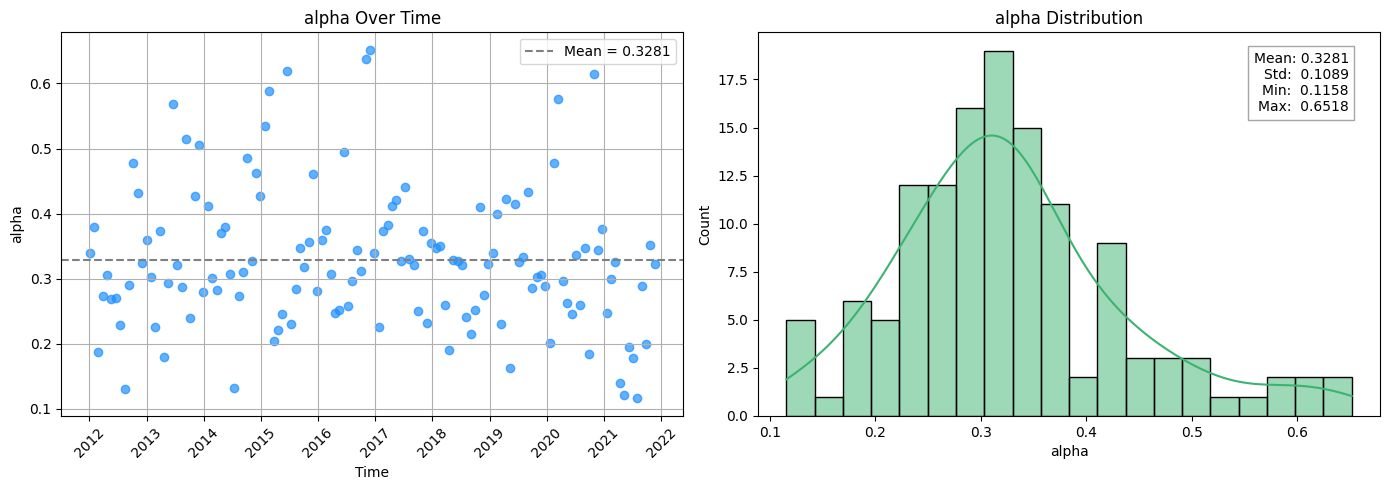

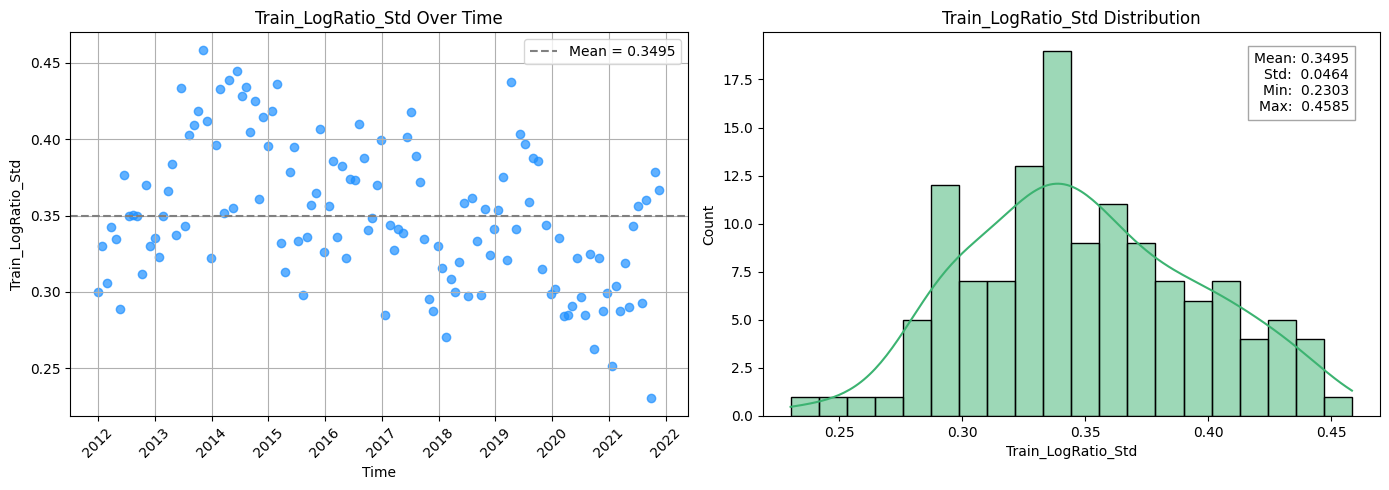

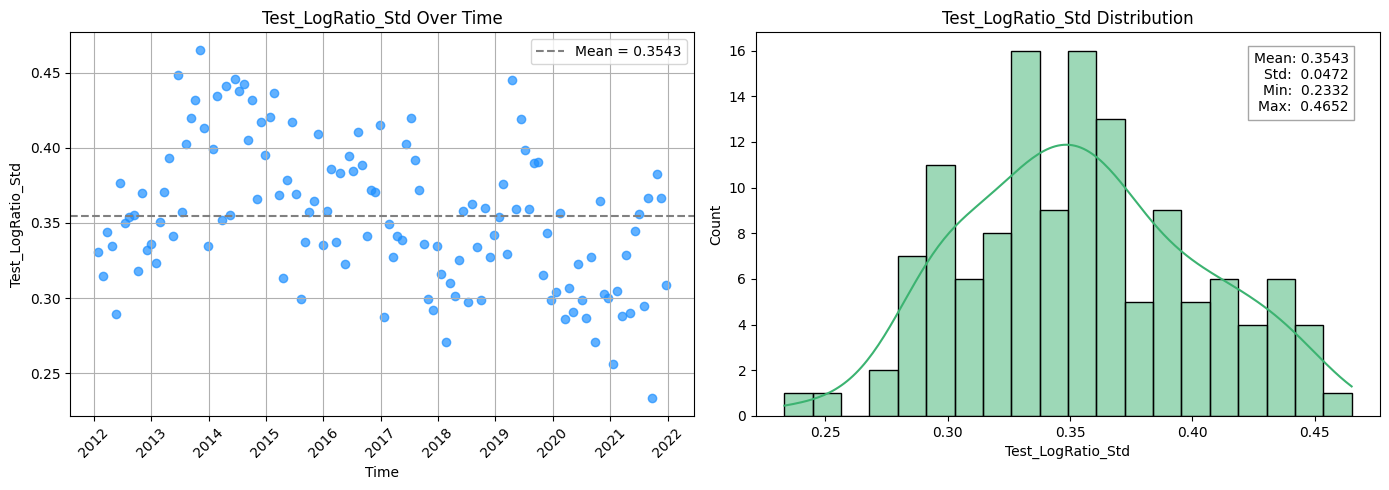

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_scatter_and_distribution(df, column, time_col='Train_Group_ID', title=None):
    series = df[column].dropna()

    # Compute stats
    mean_val = series.mean()
    std_val  = series.std()
    min_val  = series.min()
    max_val  = series.max()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Scatter over time
    axes[0].scatter(df[time_col], df[column], alpha=0.7, color='dodgerblue')
    axes[0].axhline(mean_val, color='gray', linestyle='--', label=f"Mean = {mean_val:.4f}")
    axes[0].set_title(f"{column} Over Time")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel(column)
    axes[0].legend()
    axes[0].grid(True)
    axes[0].tick_params(axis='x', rotation=45)

    # 2. Distribution with stats
    sns.histplot(series, bins=20, kde=True, ax=axes[1], color='mediumseagreen', edgecolor='black')
    axes[1].set_title(f"{column} Distribution")

    stats_text = (
        f"Mean: {mean_val:.4f}\n"
        f"Std:  {std_val:.4f}\n"
        f"Min:  {min_val:.4f}\n"
        f"Max:  {max_val:.4f}"
    )
    axes[1].text(0.95, 0.95, stats_text, transform=axes[1].transAxes,
                 fontsize=10, va='top', ha='right',
                 bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7))

    plt.tight_layout()
    if title:
        plt.suptitle(title, fontsize=14, y=1.05)
    plt.show()

# Plot alpha and log ratio stds
plot_scatter_and_distribution(backtest_df, 'alpha', time_col='Train_Group_ID')
plot_scatter_and_distribution(backtest_df, 'Train_LogRatio_Std', time_col='Train_Group_ID')
plot_scatter_and_distribution(backtest_df, 'Test_LogRatio_Std', time_col='Test_Group_ID')


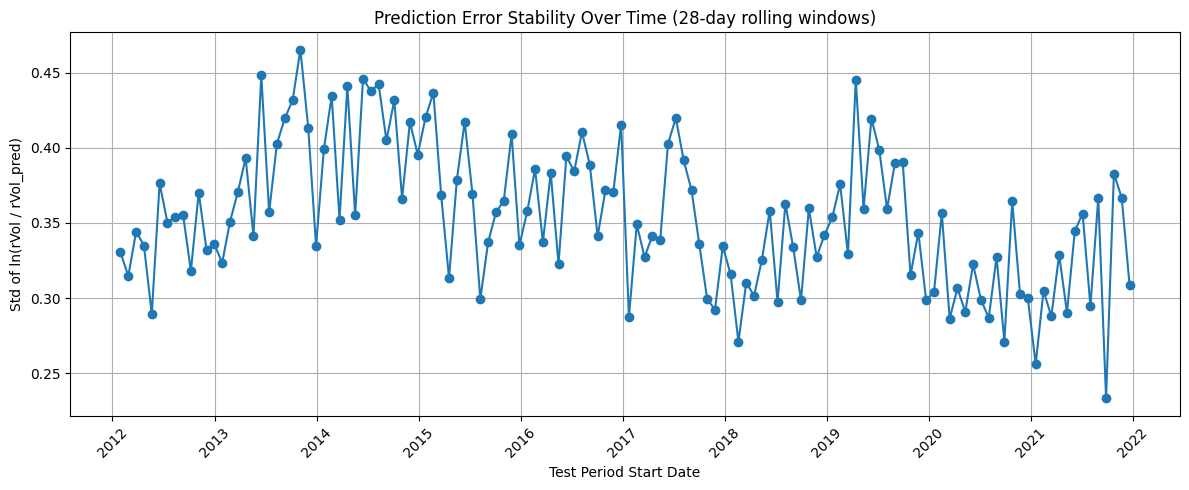

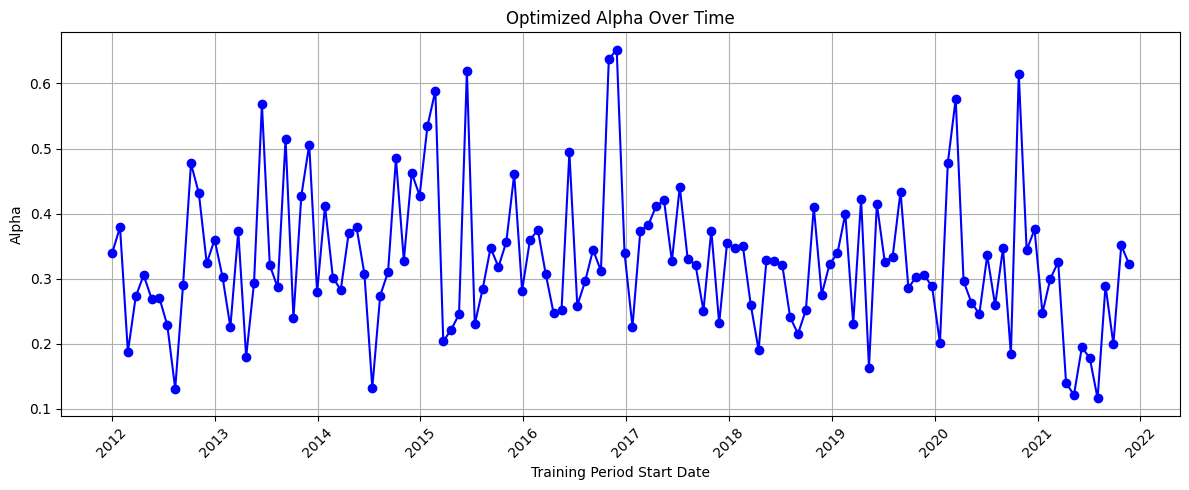

In [70]:
# 1. Prediction Error Stability Over Time
plt.figure(figsize=(12, 5))
plt.plot(backtest_df['Test_Group_ID'], backtest_df['Test_LogRatio_Std'], marker='o')
plt.title('Prediction Error Stability Over Time (28-day rolling windows)')
plt.xlabel('Test Period Start Date')
plt.ylabel('Std of ln(rVol / rVol_pred)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Alpha over time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(backtest_df['Train_Group_ID'], backtest_df['alpha'], marker='o', color='blue')
ax.set_ylabel("Alpha")
ax.set_title("Optimized Alpha Over Time")
ax.set_xlabel("Training Period Start Date")
ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [71]:
#Since there is 70% weightage to the yesterday same time vol. Now here we are making alpha = 0 and testing the results

def rolling_stability_backtest_fixed_alpha(full_df, vol_col='RVol_120min_Close-to-Close', 
                                           stability_days=28, max_days=1, fixed_alpha=0):
    """
    Rolling 28-day windows stability backtest with fixed alpha.
    Computes train and test log ratio std using the fixed alpha.
    """
    full_df = full_df.copy()
    full_df.sort_index(inplace=True)

    # Assign stability group ID
    start_time = full_df.index.min().floor('D')
    full_df['Stability_group_id'] = ((full_df.index - start_time) // pd.Timedelta(days=stability_days)) * pd.Timedelta(days=stability_days) + start_time

    group_ids = sorted(full_df['Stability_group_id'].unique())
    results = []

    for i in range(len(group_ids) - 1):
        train_id = group_ids[i]
        test_id = group_ids[i + 1]

        train_data = full_df[full_df['Stability_group_id'] == train_id]
        test_data  = full_df[full_df['Stability_group_id'] == test_id]

        # Compute predicted vol on training data with fixed alpha
        train_copy = add_predicted_vol_single_alpha(train_data, vol_col, alpha=fixed_alpha, max_days=max_days)
        train_copy['log_ratio'] = np.log(train_copy[vol_col] / train_copy['Predicted_Vol'])
        train_log_std = train_copy['log_ratio'].std()

        # Compute predicted vol on test data using same alpha
        test_copy = add_predicted_vol_single_alpha(test_data, vol_col, alpha=fixed_alpha, max_days=max_days)
        test_copy['log_ratio'] = np.log(test_copy[vol_col] / test_copy['Predicted_Vol'])
        test_log_std = test_copy['log_ratio'].std()

        results.append({
            'Train_Group_ID': train_id,
            'Test_Group_ID': test_id,
            'alpha': fixed_alpha,
            'max_days': max_days,
            'Train_LogRatio_Std': train_log_std,
            'Test_LogRatio_Std': test_log_std,
        })

    return pd.DataFrame(results)


In [72]:
backtest_df_fixed_alpha = rolling_stability_backtest_fixed_alpha(CC_120m_rvol, fixed_alpha=0)
backtest_df_fixed_alpha


,Train_Group_ID,Test_Group_ID,alpha,max_days,Train_LogRatio_Std,Test_LogRatio_Std
0,2012-01-02,2012-01-30,0,1,0.354735,0.377777
1,2012-01-30,2012-02-27,0,1,0.377777,0.322935
2,2012-02-27,2012-03-26,0,1,0.322935,0.368489
3,2012-03-26,2012-04-23,0,1,0.368489,0.376860
4,2012-04-23,2012-05-21,0,1,0.376860,0.322151
...,...,...,...,...,...,...
125,2021-08-02,2021-08-30,0,1,0.304932,0.384373
126,2021-08-30,2021-09-27,0,1,0.384373,0.250472
127,2021-09-27,2021-10-25,0,1,0.250472,0.422949
128,2021-10-25,2021-11-22,0,1,0.422949,0.412554


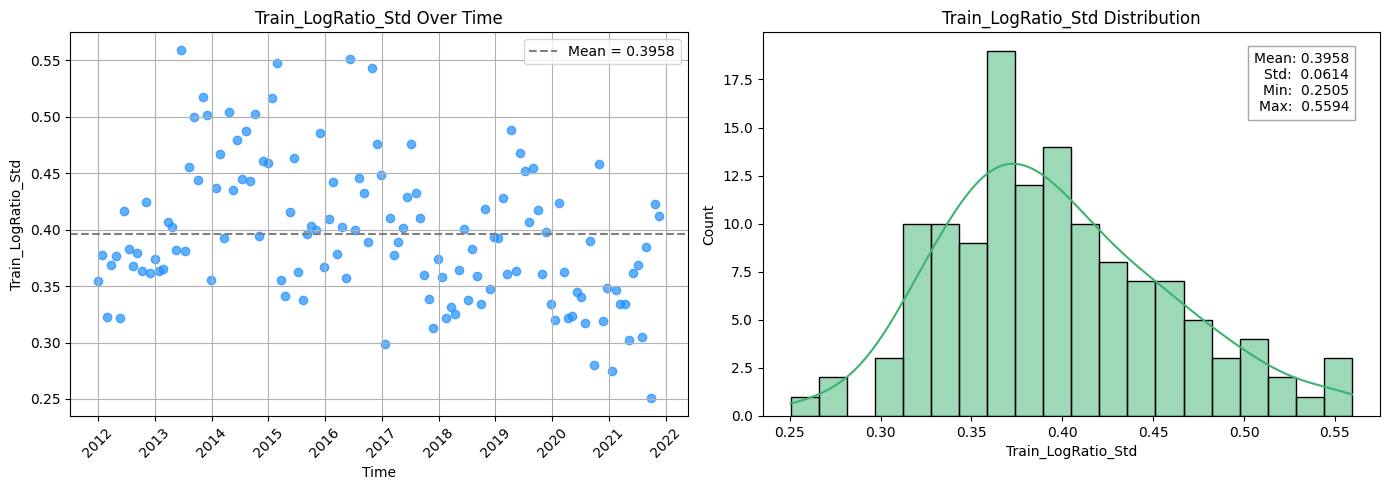

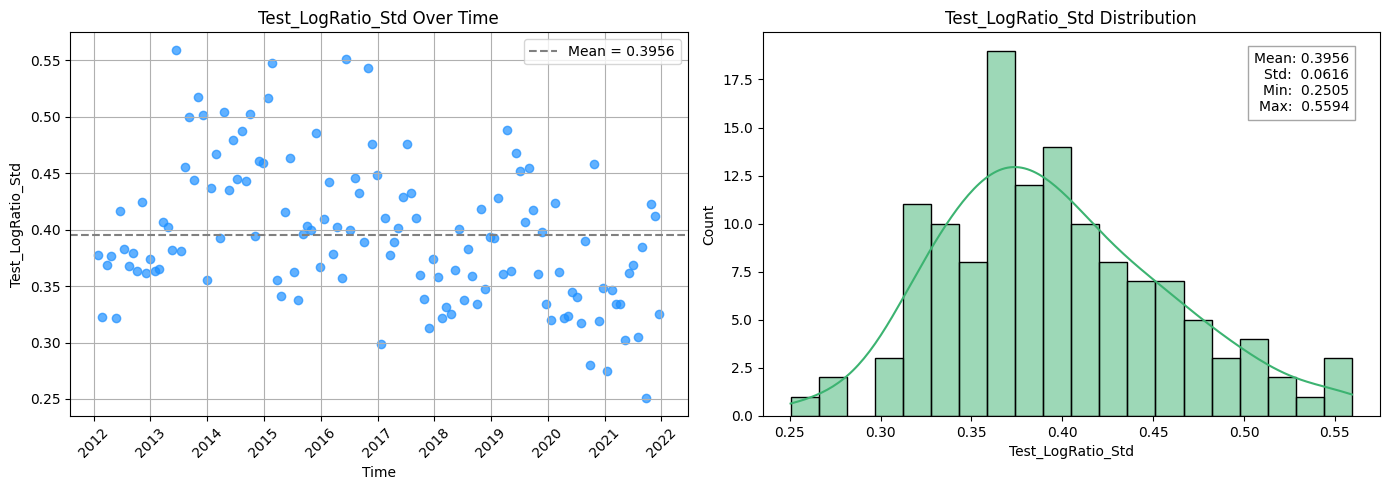

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_scatter_and_distribution(df, column, time_col='Train_Group_ID', title=None):
    """
    Plots scatter over time and distribution for a given column in the backtest DataFrame.
    """
    series = df[column].dropna()

    # Compute stats
    mean_val = series.mean()
    std_val  = series.std()
    min_val  = series.min()
    max_val  = series.max()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Scatter over time
    axes[0].scatter(df[time_col], df[column], alpha=0.7, color='dodgerblue')
    axes[0].axhline(mean_val, color='gray', linestyle='--', label=f"Mean = {mean_val:.4f}")
    axes[0].set_title(f"{column} Over Time")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel(column)
    axes[0].legend()
    axes[0].grid(True)
    axes[0].tick_params(axis='x', rotation=45)

    # 2. Distribution with stats
    sns.histplot(series, bins=20, kde=True, ax=axes[1], color='mediumseagreen', edgecolor='black')
    axes[1].set_title(f"{column} Distribution")

    stats_text = (
        f"Mean: {mean_val:.4f}\n"
        f"Std:  {std_val:.4f}\n"
        f"Min:  {min_val:.4f}\n"
        f"Max:  {max_val:.4f}"
    )
    axes[1].text(0.95, 0.95, stats_text, transform=axes[1].transAxes,
                 fontsize=10, va='top', ha='right',
                 bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7))

    plt.tight_layout()
    if title:
        plt.suptitle(title, fontsize=14, y=1.05)
    plt.show()


# Plot only train and test log ratio stds
plot_scatter_and_distribution(backtest_df_fixed_alpha, 'Train_LogRatio_Std', time_col='Train_Group_ID')
plot_scatter_and_distribution(backtest_df_fixed_alpha, 'Test_LogRatio_Std', time_col='Test_Group_ID')


In [185]:
#Identifying Spikes

'''import numpy as np
import matplotlib.pyplot as plt

# Extract volatility column
vol = CC_120m_rvol['RVol_120min_Close-to-Close'].values

# Compute log ratio: log(Vol_t / Vol_{t-1})
log_vol_change = np.log(vol[1:] / vol[:-1])

# Calculate statistics
mean_val = np.mean(log_vol_change)
std_val = np.std(log_vol_change)
min_val = np.min(log_vol_change)
max_val = np.max(log_vol_change)

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(log_vol_change, bins=50, color='steelblue', edgecolor='black', alpha=0.7)

# Add vertical lines
# Mean (green)
plt.axvline(mean_val, color='green', linestyle='dashed', linewidth=2, label=f"Mean = {mean_val:.4f}")

# ±1 Std Dev (red)
plt.axvline(mean_val + std_val, color='red', linestyle='dotted', linewidth=2, label=f"+1 Std = {mean_val+std_val:.4f}")
plt.axvline(mean_val - std_val, color='red', linestyle='dotted', linewidth=2, label=f"-1 Std = {mean_val-std_val:.4f}")

# ±2 Std Dev (red)
plt.axvline(mean_val + 2*std_val, color='red', linestyle='dotted', linewidth=2, label=f"+2 Std = {mean_val+2*std_val:.4f}")
plt.axvline(mean_val - 2*std_val, color='red', linestyle='dotted', linewidth=2, label=f"-2 Std = {mean_val-2*std_val:.4f}")

# Axis labels & title
plt.xlabel("Log(Vol_t / Vol_{t-1})", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Log Changes in 120m Annualised Volatility", fontsize=14, weight='bold')

# Add legend
plt.legend()

# Grid for clarity
plt.grid(alpha=0.3, linestyle='--')

# Show plot
plt.show()

# Print summary stats
print(f"Mean: {mean_val:.4f}, Std Dev: {std_val:.4f}, Min: {min_val:.4f}, Max: {max_val:.4f}")'''


'import numpy as np\nimport matplotlib.pyplot as plt\n\n# Extract volatility column\nvol = CC_120m_rvol[\'RVol_120min_Close-to-Close\'].values\n\n# Compute log ratio: log(Vol_t / Vol_{t-1})\nlog_vol_change = np.log(vol[1:] / vol[:-1])\n\n# Calculate statistics\nmean_val = np.mean(log_vol_change)\nstd_val = np.std(log_vol_change)\nmin_val = np.min(log_vol_change)\nmax_val = np.max(log_vol_change)\n\n# Plot histogram\nplt.figure(figsize=(10,6))\nplt.hist(log_vol_change, bins=50, color=\'steelblue\', edgecolor=\'black\', alpha=0.7)\n\n# Add vertical lines\n# Mean (green)\nplt.axvline(mean_val, color=\'green\', linestyle=\'dashed\', linewidth=2, label=f"Mean = {mean_val:.4f}")\n\n# ±1 Std Dev (red)\nplt.axvline(mean_val + std_val, color=\'red\', linestyle=\'dotted\', linewidth=2, label=f"+1 Std = {mean_val+std_val:.4f}")\nplt.axvline(mean_val - std_val, color=\'red\', linestyle=\'dotted\', linewidth=2, label=f"-1 Std = {mean_val-std_val:.4f}")\n\n# ±2 Std Dev (red)\nplt.axvline(mean_val + 

In [184]:
'''import numpy as np
import pandas as pd

# Make a copy of your original DataFrame so we don’t overwrite it by mistake
df = CC_120m_rvol.copy().reset_index(drop=True)

# Column name where the annualised volatility values are stored
vol_col = 'RVol_120min_Close-to-Close'

# -----------------------------
# STEP 1: Define spike threshold
# -----------------------------

# This is the 2nd standard deviation value (from histogram of log changes)
# It’s in "log terms", so we convert it back to normal scale
log_threshold = 0.9147

# Convert log threshold into a multiplicative factor
# Example: log(Vol2/Vol1) > 0.9147  →  Vol2/Vol1 > exp(0.9147)
factor_threshold = np.exp(log_threshold)   # ≈ 2.496

# Convert factor into percentage increase
# Example: if factor = 2.496, then spike = ~149.6% increase
perc_threshold = (factor_threshold - 1) * 100  # ≈ 149.6%

# -----------------------------
# STEP 2: Calculate % change
# -----------------------------

# Compute percentage change in volatility from previous row
# Formula: (Vol_t - Vol_(t-1)) / Vol_(t-1) * 100
df['perc_change'] = df[vol_col].pct_change() * 100

# -----------------------------
# STEP 3: Flag spikes
# -----------------------------

# Mark rows where the volatility increase is greater than spike threshold
df['is_spike'] = df['perc_change'] > perc_threshold

# -----------------------------
# STEP 4: Inspect results
# -----------------------------

print(f"Spike threshold: {perc_threshold:.2f}% increase over previous volatility")


# Filter only spike rows
spikes_df = df.loc[df['is_spike']].copy()

# Reset index for convenience
spikes_df.reset_index(drop=True, inplace=True)

# Inspect first few spikes
print(spikes_df[['StartDateTime', vol_col, 'perc_change']])'''


'import numpy as np\nimport pandas as pd\n\n# Make a copy of your original DataFrame so we don’t overwrite it by mistake\ndf = CC_120m_rvol.copy().reset_index(drop=True)\n\n# Column name where the annualised volatility values are stored\nvol_col = \'RVol_120min_Close-to-Close\'\n\n# -----------------------------\n# STEP 1: Define spike threshold\n# -----------------------------\n\n# This is the 2nd standard deviation value (from histogram of log changes)\n# It’s in "log terms", so we convert it back to normal scale\nlog_threshold = 0.9147\n\n# Convert log threshold into a multiplicative factor\n# Example: log(Vol2/Vol1) > 0.9147  →  Vol2/Vol1 > exp(0.9147)\nfactor_threshold = np.exp(log_threshold)   # ≈ 2.496\n\n# Convert factor into percentage increase\n# Example: if factor = 2.496, then spike = ~149.6% increase\nperc_threshold = (factor_threshold - 1) * 100  # ≈ 149.6%\n\n# -----------------------------\n# STEP 2: Calculate % change\n# -----------------------------\n\n# Compute perce

In [120]:
'''import matplotlib.pyplot as plt

# Filter spike rows into a new DataFrame
spikes = df.loc[df['is_spike'], ['StartDateTime', 'RVol_120min_Close-to-Close', 'perc_change']]

# Plot full volatility
plt.figure(figsize=(16,6))
plt.plot(df['StartDateTime'], df['RVol_120min_Close-to-Close'], 
         label='Volatility', color='blue', alpha=0.6)

# Overlay only spike points
plt.scatter(spikes['StartDateTime'], spikes['RVol_120min_Close-to-Close'], 
            color='red', label='Spikes', zorder=5)

plt.title('Volatility with Spikes Highlighted (>149.6%)')
plt.xlabel('Date')
plt.ylabel('120m Realized Volatility')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()'''


"import matplotlib.pyplot as plt\n\n# Filter spike rows into a new DataFrame\nspikes = df.loc[df['is_spike'], ['StartDateTime', 'RVol_120min_Close-to-Close', 'perc_change']]\n\n# Plot full volatility\nplt.figure(figsize=(16,6))\nplt.plot(df['StartDateTime'], df['RVol_120min_Close-to-Close'], \n         label='Volatility', color='blue', alpha=0.6)\n\n# Overlay only spike points\nplt.scatter(spikes['StartDateTime'], spikes['RVol_120min_Close-to-Close'], \n            color='red', label='Spikes', zorder=5)\n\nplt.title('Volatility with Spikes Highlighted (>149.6%)')\nplt.xlabel('Date')\nplt.ylabel('120m Realized Volatility')\nplt.legend()\nplt.grid(True, linestyle='--', alpha=0.6)\nplt.show()"

In [121]:
'''import pandas as pd
import numpy as np

# -----------------------------------
# STEP 1: Define post-spike analysis
# -----------------------------------
def analyze_post_spike_volatility(df, spikes_df, vol_col='RVol_120min_Close-to-Close', max_lags=20, row_hours=2):
    """
    Analyze how volatility behaves after each spike.

    Parameters:
    - df: full volatility DataFrame (time series)
    - spikes_df: DataFrame containing only spikes
    - vol_col: column name for volatility
    - max_lags: how many rows after the spike to check volatility
    - row_hours: hours per row in the data (for time calculation)

    Returns:
    - post_spike_df: each spike and volatility trajectory after it
    """
    df = df.copy().reset_index(drop=True)
    spikes_df = spikes_df.copy().reset_index(drop=True)
    
    # Compute overall mean volatility for reference
    overall_mean_vol = df[vol_col].mean()
    
    results = []
    
    for idx, spike in spikes_df.iterrows():
        spike_idx = spike.name  # index of spike in original df
        spike_time = spike['StartDateTime']
        spike_vol = spike[vol_col]
        
        # Get post-spike volatility up to max_lags
        post_vol = df[vol_col].iloc[spike_idx + 1 : spike_idx + 1 + max_lags].reset_index(drop=True)
        
        # Time to return to mean
        return_to_mean = np.nan
        for lag, vol in enumerate(post_vol, start=1):
            if vol <= overall_mean_vol:
                return_to_mean = lag
                break
        
        results.append({
            'Spike_Index': spike_idx,
            'Spike_Time': spike_time,
            'Spike_Vol': spike_vol,
            'Return_to_Mean_Lags': return_to_mean,
            'Return_to_Mean_Hours': return_to_mean * row_hours if not np.isnan(return_to_mean) else np.nan,
            'Post_Spike_Volatility': post_vol.values  # store array of post-spike vols
        })
    
    post_spike_df = pd.DataFrame(results)
    return post_spike_df

# -----------------------------------
# STEP 2: Run post-spike analysis
# -----------------------------------
post_spike_df = analyze_post_spike_volatility(CC_120m_rvol, spikes_df, 
                                              vol_col='RVol_120min_Close-to-Close', 
                                              max_lags=20,
                                              row_hours=2)  # each row = 2 hours

# -----------------------------------
# STEP 3: Inspect results
# -----------------------------------
# First few rows
print(post_spike_df)'''




'import pandas as pd\nimport numpy as np\n\n# -----------------------------------\n# STEP 1: Define post-spike analysis\n# -----------------------------------\ndef analyze_post_spike_volatility(df, spikes_df, vol_col=\'RVol_120min_Close-to-Close\', max_lags=20, row_hours=2):\n    """\n    Analyze how volatility behaves after each spike.\n\n    Parameters:\n    - df: full volatility DataFrame (time series)\n    - spikes_df: DataFrame containing only spikes\n    - vol_col: column name for volatility\n    - max_lags: how many rows after the spike to check volatility\n    - row_hours: hours per row in the data (for time calculation)\n\n    Returns:\n    - post_spike_df: each spike and volatility trajectory after it\n    """\n    df = df.copy().reset_index(drop=True)\n    spikes_df = spikes_df.copy().reset_index(drop=True)\n\n    # Compute overall mean volatility for reference\n    overall_mean_vol = df[vol_col].mean()\n\n    results = []\n\n    for idx, spike in spikes_df.iterrows():\n    

In [122]:
'''# Summary of lags and time to return to mean
print("\nSummary of time to return to mean (in rows):")
print(post_spike_df['Return_to_Mean_Lags'].describe())
print("\nSummary of time to return to mean (in hours):")
print(post_spike_df['Return_to_Mean_Hours'].describe())'''

'# Summary of lags and time to return to mean\nprint("\nSummary of time to return to mean (in rows):")\nprint(post_spike_df[\'Return_to_Mean_Lags\'].describe())\nprint("\nSummary of time to return to mean (in hours):")\nprint(post_spike_df[\'Return_to_Mean_Hours\'].describe())'

In [ ]:
                                                            #Spikes and lags

In [83]:
CC_120m_rvol

,group_id,StartDateTime,Open_first,High_max,Low_min,Close_last,Volume_sum,indicator_sum,count,RVol_120min_Close-to-Close,Prev_Close_global,Log_Returns_global
EndDateTime,,,,,,,,,,,,
2012-01-02 03:59:00,2012-01-02 02:00:00,2012-01-02 02:00:00,1.29324,1.29531,1.29275,1.29383,0.0,1,119.0,10.232835,1.29324,0.000456
2012-01-02 05:59:00,2012-01-02 04:00:00,2012-01-02 04:00:00,1.29384,1.29709,1.29381,1.29457,0.0,1,119.0,16.910501,1.29383,0.000572
2012-01-02 07:59:00,2012-01-02 06:00:00,2012-01-02 06:00:00,1.29454,1.29514,1.29311,1.29381,0.0,2,118.0,7.065073,1.29457,-0.000587
2012-01-02 09:59:00,2012-01-02 08:00:00,2012-01-02 08:00:00,1.29382,1.29442,1.29227,1.29327,0.0,4,116.0,7.967928,1.29381,-0.000417
2012-01-02 11:59:00,2012-01-02 10:00:00,2012-01-02 10:00:00,1.29325,1.29413,1.29167,1.29197,0.0,6,114.0,6.309249,1.29327,-0.001006
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 07:59:00,2021-12-31 06:00:00,2021-12-31 06:00:00,1.13248,1.13349,1.13120,1.13252,0.0,0,120.0,9.251383,1.13248,0.000035
2021-12-31 09:59:00,2021-12-31 08:00:00,2021-12-31 08:00:00,1.13253,1.13534,1.13191,1.13437,0.0,0,120.0,12.598818,1.13252,0.001632
2021-12-31 11:59:00,2021-12-31 10:00:00,2021-12-31 10:00:00,1.13438,1.13796,1.13379,1.13790,0.0,0,120.0,18.095806,1.13437,0.003107


In [ ]:
                                                #AR(1) Method - AutoRegressive Model of order 1
#Today’s volatility depends on yesterday’s volatility plus some random shock.
#log_vol[t] = a + b * log_vol[t−1] + noise[t]
'''a is a baseline level
b tells how much yesterday influences today
noise[t] is the unexpected part → this is where spikes happen'''

'''predicted_log_vol[t] = a + b * log_vol[t−1]
resid[t] = log_vol[t] - predicted_log_vol[t]
z score: 
z[t] = resid[t] / rolling_std(resid past values)'''


In [127]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# -----------------------------------------------
# STEP 1: Prepare data (convert annualized % → log vol)
# -----------------------------------------------
df = CC_120m_rvol.copy()

# annualized % → fraction
rv_ann = pd.to_numeric(df['RVol_120min_Close-to-Close'], errors='coerce') / 100.0

# de-annualize to 2-hour vol (native frequency)
PERYEAR = (365*24*60) // 120  # = 4380 two-hour periods per year
vol_2h = rv_ann / np.sqrt(PERYEAR)

# log volatility (stable, used for modeling)
logv = np.log(vol_2h.clip(lower=1e-12))

# -----------------------------------------------
# STEP 2: Build AR(1) regression
# logv[t] predicted from logv[t-1]
# -----------------------------------------------
data = pd.DataFrame({
    'y': logv,
    'lag1': logv.shift(1)
}).dropna()

y = data['y']
X = sm.add_constant(data['lag1'])

model = sm.OLS(y, X).fit()

print(model.summary())

# -----------------------------------------------
# STEP 3: Compute residuals (unexpected volatility)
# -----------------------------------------------
pred = model.predict(X)
resid = y - pred

# -----------------------------------------------
# STEP 4: Standardize residuals using past volatility
# no lookahead → shift(1)
# -----------------------------------------------
resid_sd = resid.rolling(1000, min_periods=200).std().shift(1)
z = resid / resid_sd

# -----------------------------------------------
# STEP 5: Spike definition
# -----------------------------------------------
spike = z.abs() > 2.5   # threshold

# attach results back to df
df['logv'] = logv
df['pred_logv'] = pred.reindex(df.index)
df['resid'] = resid.reindex(df.index)
df['z_resid'] = z.reindex(df.index)
df['spike_AR1'] = spike.reindex(df.index)

print("Total spikes detected:", df['spike_AR1'].sum())

# Look at first few results
print(df[['logv','pred_logv','resid','z_resid','spike_AR1']].head(20))


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                 2.318e+04
Date:                Sat, 15 Nov 2025   Prob (F-statistic):               0.00
Time:                        16:54:17   Log-Likelihood:                -16293.
No. Observations:               29978   AIC:                         3.259e+04
Df Residuals:                   29976   BIC:                         3.261e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3189      0.030    -78.052      0.0

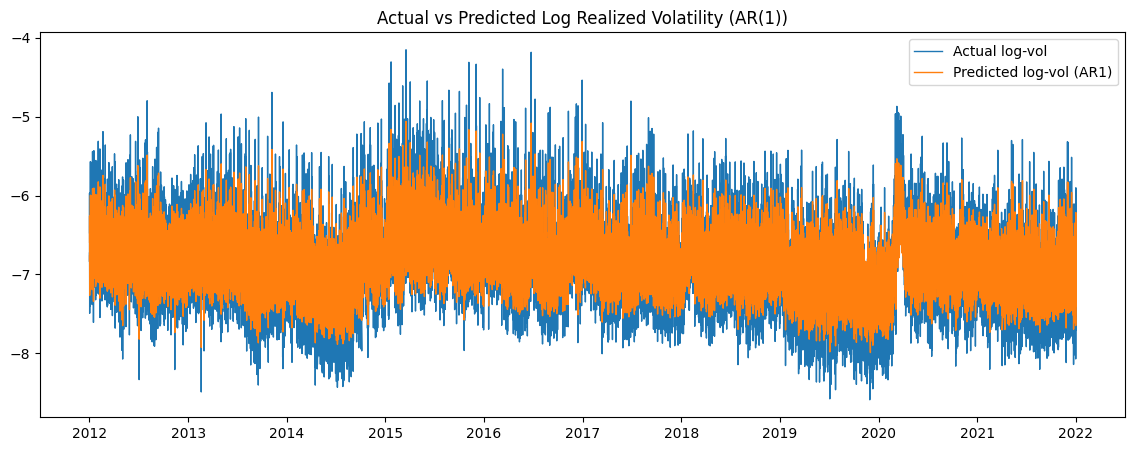

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(df.index, df['logv'], label='Actual log-vol', linewidth=1)
plt.plot(df.index, df['pred_logv'], label='Predicted log-vol (AR1)', linewidth=1)
plt.title("Actual vs Predicted Log Realized Volatility (AR(1))")
plt.legend()
plt.show()


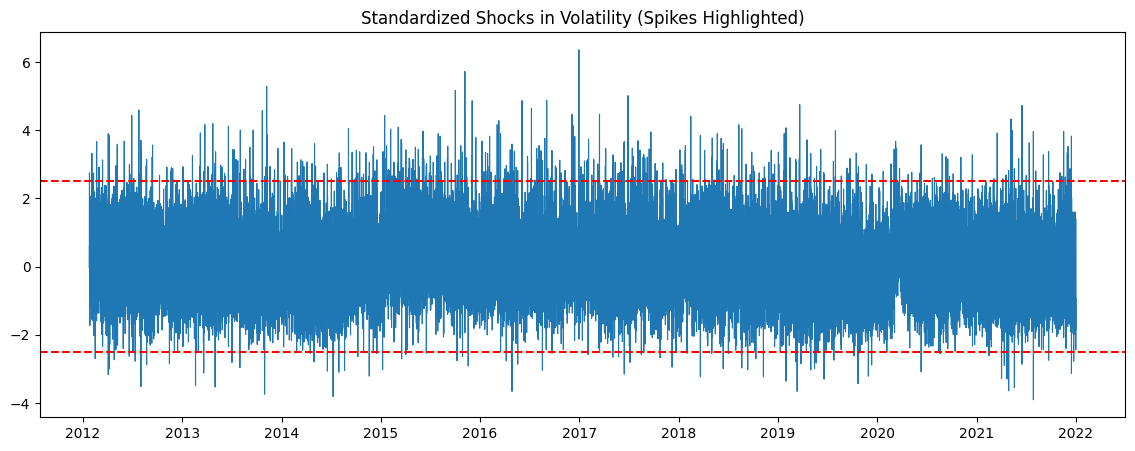

In [129]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['z_resid'], label='Z-score of AR Residuals', linewidth=0.8)
plt.axhline(2.5, color='red', linestyle='--')
plt.axhline(-2.5, color='red', linestyle='--')
plt.title("Standardized Shocks in Volatility (Spikes Highlighted)")
plt.show()


In [138]:
# spike mask (safe boolean)
spike_mask = df['spike_AR1'].fillna(False)

# counts up / down
up = df.loc[spike_mask & (df['resid'] > 0)].shape[0]
down = df.loc[spike_mask & (df['resid'] < 0)].shape[0]
print("Total spikes:", spike_mask.sum(), "  Up:", up, "  Down:", down)

# summary of logv for spikes (you already did)
print(df.loc[spike_mask, 'logv'].describe())


Total spikes: 535   Up: 442   Down: 93
count    535.000000
mean      -5.900759
std        0.859442
min       -8.592045
25%       -6.103460
50%       -5.677420
75%       -5.368337
max       -4.150600
Name: logv, dtype: float64


C:\Users\phani\AppData\Local\Temp\ipykernel_24880\2617036015.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  spike_mask = df['spike_AR1'].fillna(False)


C:\Users\phani\AppData\Local\Temp\ipykernel_24880\3224343922.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  spike_up = df['spike_AR1'].fillna(False) & (df['resid'] > 0)
C:\Users\phani\AppData\Local\Temp\ipykernel_24880\3224343922.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  spike_down = df['spike_AR1'].fillna(False) & (df['resid'] < 0)


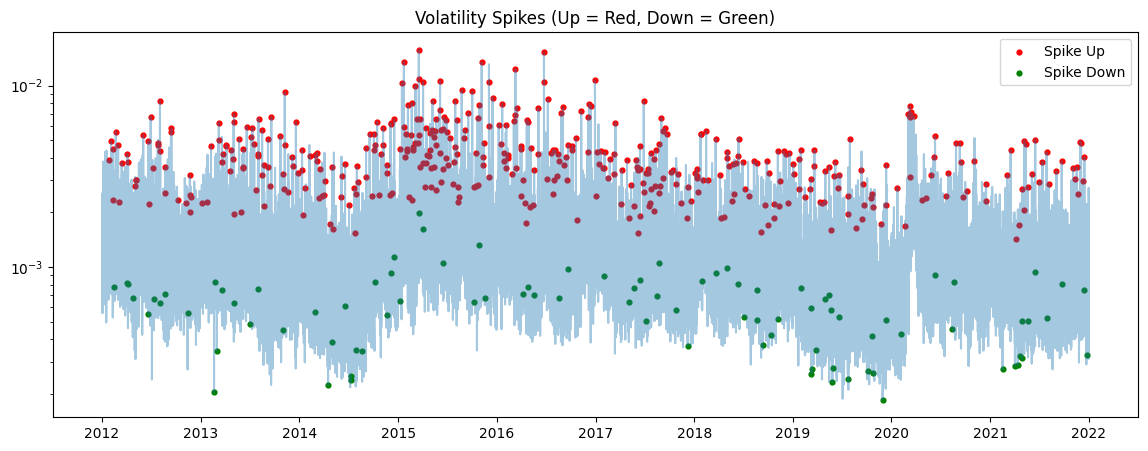

In [179]:
df['vol_2h'] = np.exp(df['logv'])

plt.figure(figsize=(14,5))
plt.plot(df.index, df['vol_2h'], alpha=0.4)

spike_up = df['spike_AR1'].fillna(False) & (df['resid'] > 0)
spike_down = df['spike_AR1'].fillna(False) & (df['resid'] < 0)

plt.scatter(df.index[spike_up], df['vol_2h'][spike_up], color='red', s=12, label='Spike Up')
plt.scatter(df.index[spike_down], df['vol_2h'][spike_down], color='green', s=12, label='Spike Down')

plt.yscale('log')
plt.legend()
plt.title("Volatility Spikes (Up = Red, Down = Green)")
plt.show()


C:\Users\phani\AppData\Local\Temp\ipykernel_24880\1222649543.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[df['spike_AR1'].fillna(False)]


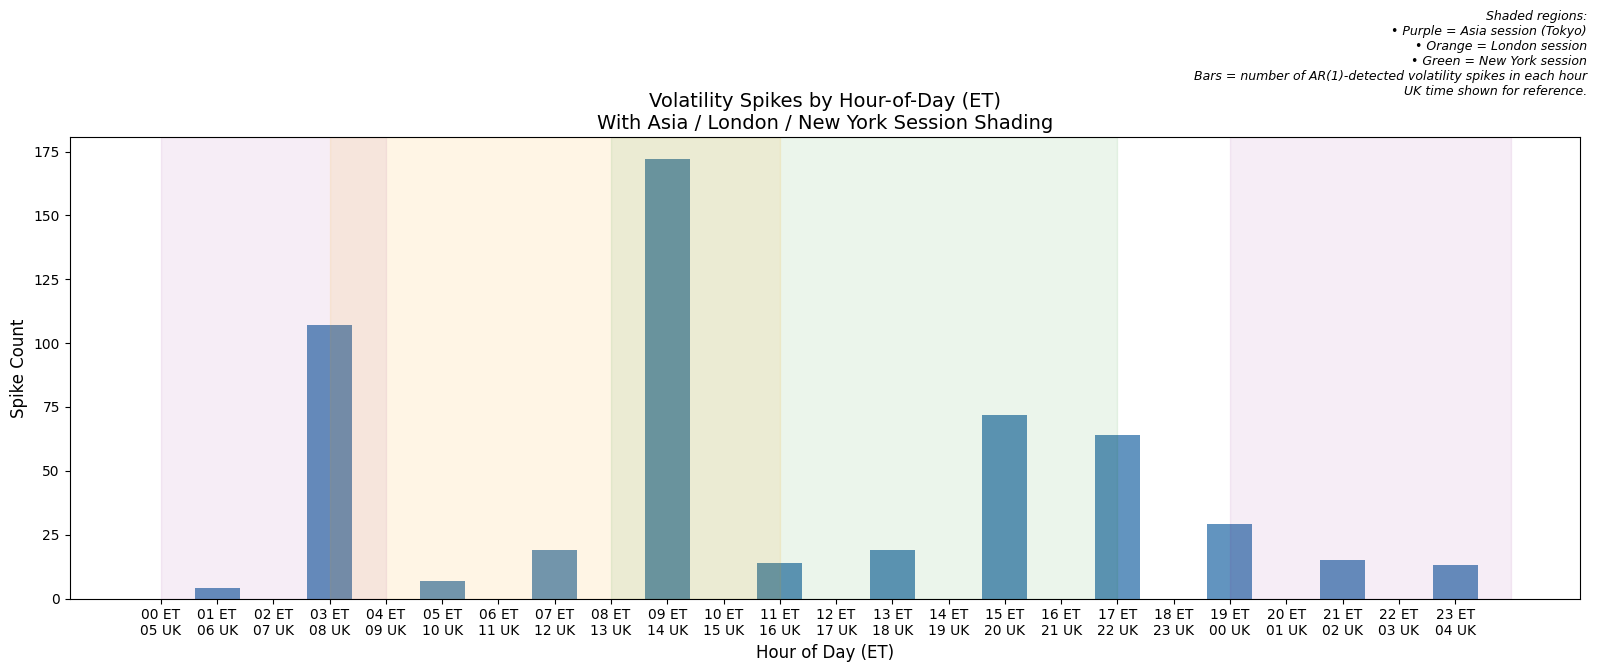

In [168]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------
# Prepare spike counts by ET hour
# -----------------------------------
df['hour'] = df.index.hour

spike_hours = (
    df[df['spike_AR1'].fillna(False)]
    .groupby('hour')
    .size()
    .reindex(range(24), fill_value=0)
)

# -----------------------------------
# Convert ET hour → UK hour
# Approximate: UK = ET + 5 hours (Winter)
# -----------------------------------
uk_hours = [(h + 5) % 24 for h in spike_hours.index]

# -----------------------------------
# Plot with session shading
# -----------------------------------
plt.figure(figsize=(16,6))

# Plot bars
plt.bar(spike_hours.index, spike_hours.values, color='steelblue', alpha=0.85, label="Spike Count")

# -----------------------------------
# Session shading (ET time)
# -----------------------------------

# Asia Session: 19:00–04:00 ET
plt.axvspan(19, 24, color='purple', alpha=0.07)  # 19–24
plt.axvspan(0, 4, color='purple', alpha=0.07)     # 00–04

# London Session: 03:00–11:00 ET
plt.axvspan(3, 11, color='orange', alpha=0.10)  

# New York Session: 08:00–17:00 ET
plt.axvspan(8, 17, color='green', alpha=0.08)

# -----------------------------------
# X-axis labels with ET + UK time
# -----------------------------------
plt.xticks(
    spike_hours.index,
    [f"{h:02d} ET\n{uk_hours[h]:02d} UK" for h in spike_hours.index],
    rotation=0
)

# -----------------------------------
# Labels & Title
# -----------------------------------
plt.xlabel("Hour of Day (ET)", fontsize=12)
plt.ylabel("Spike Count", fontsize=12)
plt.title("Volatility Spikes by Hour-of-Day (ET)\nWith Asia / London / New York Session Shading", fontsize=14)

# Legend — clean and compact
plt.figtext(
    0.995, 0.97,
    "Shaded regions:\n"
    "• Purple = Asia session (Tokyo)\n"
    "• Orange = London session\n"
    "• Green = New York session\n"
    "Bars = number of AR(1)-detected volatility spikes in each hour\n"
    "UK time shown for reference.",
    ha='right', fontsize=9, style='italic'
)

plt.tight_layout()
plt.show()


In [145]:
import numpy as np
import pandas as pd

def simple_spike_cooloff(
    df,
    z_col='z_resid',
    spike_col='spike_AR1',
    z_threshold=2.5,
    cooloff_z=1.0,
    timeframe_min=120,
):

    z = df[z_col]
    spikes = df[spike_col].fillna(False)

    episodes = []
    n = len(df)
    idx = df.index

    i = 0
    while i < n:

        # not a spike → skip
        if not spikes.iloc[i]:
            i += 1
            continue

        # --- episode start ---
        start_idx = i
        start_ts = idx[start_idx]
        start_z = z.iloc[start_idx]

        # determine direction
        direction = "up" if start_z > 0 else "down"

        # --- move forward until cool-off ---
        j = i
        while j < n:
            zj = z.iloc[j]

            # cool-off condition
            if not pd.isna(zj) and abs(zj) <= cooloff_z:
                break

            j += 1

        # if we reached end of series
        if j == n:
            end_idx = n - 1
        else:
            end_idx = j

        end_ts = idx[end_idx]
        end_z = z.iloc[end_idx]

        bars_to_cool = end_idx - start_idx + 1
        hours_to_cool = bars_to_cool * (timeframe_min / 60)

        episodes.append({
            'start': start_ts,
            'start_z': start_z,
            'direction': direction,
            'end': end_ts,
            'end_z': end_z,
            'bars_to_cool': bars_to_cool,
            'hours_to_cool': hours_to_cool,
        })

        # continue after the episode
        i = end_idx + 1

    return pd.DataFrame(episodes)


# -----------------------
# RUN
# -----------------------

episodes_simple = simple_spike_cooloff(
    df,
    z_col='z_resid',
    spike_col='spike_AR1',
    z_threshold=2.5,
    cooloff_z=1.0,
    timeframe_min=120
)

print("Total episodes:", len(episodes_simple))
print(episodes_simple.head(10))


Total episodes: 491
                start   start_z direction                 end     end_z  \
0 2012-01-25 13:59:00  2.751129        up 2012-01-25 15:59:00  0.602984   
1 2012-02-03 09:59:00  3.318402        up 2012-02-03 11:59:00 -0.672480   
2 2012-02-08 19:59:00  2.686301        up 2012-02-08 21:59:00 -0.600189   
3 2012-02-09 09:59:00  2.740636        up 2012-02-09 11:59:00 -0.116481   
4 2012-02-15 17:59:00 -2.700431      down 2012-02-15 21:59:00  0.048839   
5 2012-02-20 21:59:00  3.663552        up 2012-02-20 23:59:00 -0.546215   
6 2012-02-29 11:59:00  2.917322        up 2012-02-29 13:59:00 -0.999623   
7 2012-03-02 03:59:00  2.723570        up 2012-03-02 05:59:00  0.009291   
8 2012-03-13 15:59:00  3.129028        up 2012-03-13 19:59:00  0.046568   
9 2012-04-03 15:59:00  3.898880        up 2012-04-03 19:59:00  0.797771   

   bars_to_cool  hours_to_cool  
0             2            4.0  
1             2            4.0  
2             2            4.0  
3             2       

C:\Users\phani\AppData\Local\Temp\ipykernel_24880\1992451069.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  spikes = df[spike_col].fillna(False)


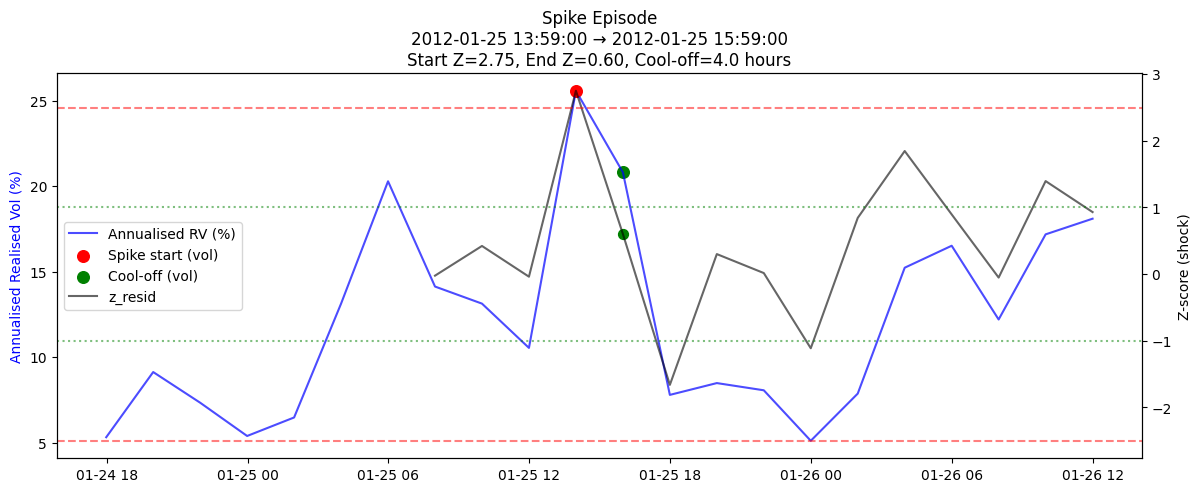

In [151]:
import matplotlib.pyplot as plt

df['vol_ann_pct'] = df['RVol_120min_Close-to-Close']

def plot_episode_with_vol(df, episode, window=10):
    start = episode['start']
    end = episode['end']

    idx = df.index
    start_pos = idx.get_loc(start)
    end_pos  = idx.get_loc(end)

    lo = max(0, start_pos - window)
    hi = min(len(df)-1, end_pos + window)

    sub = df.iloc[lo:hi+1]

    fig, ax1 = plt.subplots(figsize=(14,5))

    # ------------------------
    # 1) Plot annualised realized volatility (left axis)
    # ------------------------
    ax1.plot(sub.index, sub['vol_ann_pct'], color='blue', label='Annualised RV (%)', alpha=0.7)
    ax1.set_ylabel("Annualised Realised Vol (%)", color='blue')

    # mark spike start & end on vol
    ax1.scatter(start, df.loc[start, 'vol_ann_pct'], color='red', s=70, label='Spike start (vol)')
    ax1.scatter(end, df.loc[end, 'vol_ann_pct'], color='green', s=70, label='Cool-off (vol)')

    # ------------------------
    # 2) Plot z-score on second axis
    # ------------------------
    ax2 = ax1.twinx()
    ax2.plot(sub.index, sub['z_resid'], color='black', label='z_resid', alpha=0.6)
    ax2.set_ylabel("Z-score (shock)", color='black')

    # threshold lines
    ax2.axhline(2.5, color='red', linestyle='--', alpha=0.5)
    ax2.axhline(-2.5, color='red', linestyle='--', alpha=0.5)
    ax2.axhline(1.0, color='green', linestyle=':', alpha=0.5)
    ax2.axhline(-1.0, color='green', linestyle=':', alpha=0.5)

    # start + end markers on z-score
    ax2.scatter(start, df.loc[start, 'z_resid'], color='red', s=50)
    ax2.scatter(end, df.loc[end, 'z_resid'], color='green', s=50)

    # title
    plt.title(f"Spike Episode\n{start} → {end}\n"
              f"Start Z={episode['start_z']:.2f}, End Z={episode['end_z']:.2f}, "
              f"Cool-off={episode['hours_to_cool']:.1f} hours")

    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    plt.legend(lines_1 + lines_2, labels_1 + labels_2)

    plt.show()

plot_episode_with_vol(df, episodes_simple.iloc[0])



In [ ]:
'''                                                 Heterogeneous Autoregression - HAR
today’s volatility = average volatility of recent short/medium/long windows (e.g., yesterday, last week, last month).
D = 12 bars (≈ 1 day), W = 60 bars (≈ 1 week), M = 264 bars (≈ 1 month).
idea : Tomorrow’s volatility is partly like today’s, partly like the last week, and partly like the last month'''


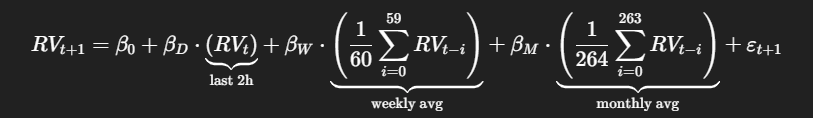

In [160]:
from IPython.display import Image, display

display(Image(filename=r"C:\Users\phani\Desktop\HAR.png"))


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

df = df.copy()

# ------------------------------------------------------------
# 1. Ensure log-vol exists
# ------------------------------------------------------------
# If your realised vol is annualised percent:
# df['RVol_120min_Close-to-Close'] = ...

# Convert annualised % → fraction → 2h vol → log
if 'logv' not in df.columns:
    rv_ann = pd.to_numeric(df['RVol_120min_Close-to-Close'], errors='coerce') / 100.0
    PERYEAR = 4380
    df['vol_2h'] = rv_ann / np.sqrt(PERYEAR)
    df['logv'] = np.log(df['vol_2h'].clip(lower=1e-12))

# ------------------------------------------------------------
# 2. Build AR(1)
# ------------------------------------------------------------
x = df['logv']
x_lag = x.shift(1)
mask = (~x.isna()) & (~x_lag.isna())

X = sm.add_constant(x_lag[mask])
y = x[mask]

model = sm.OLS(y, X).fit()

df['pred_logv_ar'] = model.predict(sm.add_constant(x_lag))
df['resid_ar']     = df['logv'] - df['pred_logv_ar']

# ------------------------------------------------------------
# 3. z-score of residuals
# ------------------------------------------------------------
resid_std = df['resid_ar'].rolling(500, min_periods=50).std()
df['z_resid_ar'] = df['resid_ar'] / resid_std

# ------------------------------------------------------------
# 4. Optional: AR(1) spikes
# ------------------------------------------------------------
df['spike_AR1'] = df['z_resid_ar'].abs() > 2.5

print(model.summary())
print("AR1 spikes detected:", df['spike_AR1'].sum())


                            OLS Regression Results                            
Dep. Variable:                   logv   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     3605.
Date:                Sat, 15 Nov 2025   Prob (F-statistic):               0.00
Time:                        19:04:26   Log-Likelihood:                -18952.
No. Observations:               28379   AIC:                         3.791e+04
Df Residuals:                   28375   BIC:                         3.795e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2750      0.070     -3.945      0.0

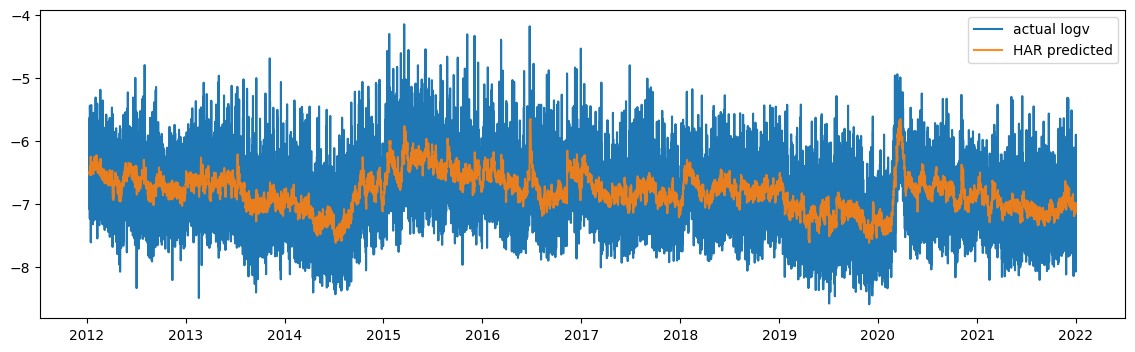

In [162]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,4))
plt.plot(har_out.index, har_out['logv'], label='actual logv')
plt.plot(har_out.index, har_out['logv_hat'], label='HAR predicted', alpha=0.9)
plt.legend(); plt.show()


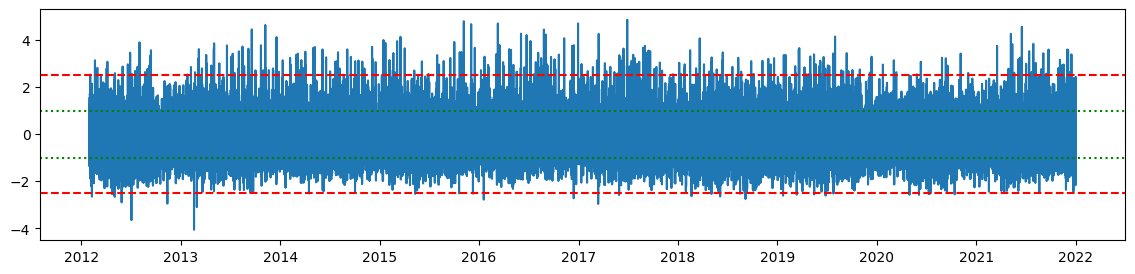

In [163]:
plt.figure(figsize=(14,3))
plt.plot(har_out.index, har_out['z_resid'])
plt.axhline(Z_THRESHOLD, color='r', linestyle='--'); plt.axhline(-Z_THRESHOLD, color='r', linestyle='--')
plt.axhline(COOLOFF_Z, color='g', linestyle=':'); plt.axhline(-COOLOFF_Z, color='g', linestyle=':')
plt.show()


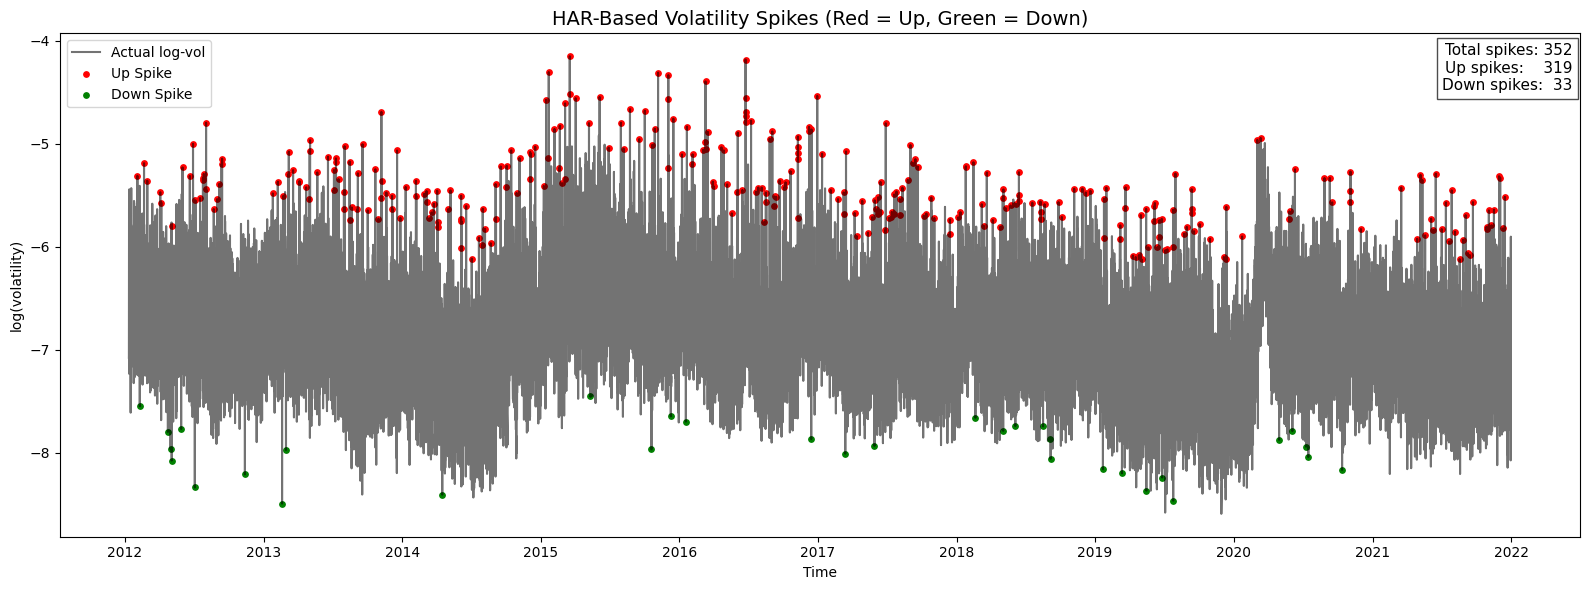

In [165]:
import matplotlib.pyplot as plt

def plot_har_spikes_with_counts(har_out, z_threshold=2.5):
    
    # ------------------------
    # Compute counts
    # ------------------------
    total_spikes = har_out['spike_HAR'].sum()
    up_spikes = ((har_out['spike_HAR']) & (har_out['z_resid'] > 0)).sum()
    down_spikes = ((har_out['spike_HAR']) & (har_out['z_resid'] < 0)).sum()

    # ------------------------
    # Plot
    # ------------------------
    plt.figure(figsize=(16,6))

    # 1. actual log-vol
    plt.plot(
        har_out.index, 
        har_out['logv'], 
        label='Actual log-vol', 
        color='black', 
        alpha=0.55
    )

    # 2. Up spikes (red dots)
    up_mask = (har_out['spike_HAR']) & (har_out['z_resid'] > 0)
    plt.scatter(
        har_out.index[up_mask],
        har_out['logv'][up_mask],
        color='red',
        s=15,
        label='Up Spike'
    )

    # 3. Down spikes (green dots)
    down_mask = (har_out['spike_HAR']) & (har_out['z_resid'] < 0)
    plt.scatter(
        har_out.index[down_mask],
        har_out['logv'][down_mask],
        color='green',
        s=15,
        label='Down Spike'
    )

    # ------------------------
    # Nice annotation box
    # ------------------------
    textstr = (
        f"Total spikes: {total_spikes}\n"
        f"Up spikes:    {up_spikes}\n"
        f"Down spikes:  {down_spikes}"
    )

    plt.gca().text(
        0.995, 0.98, textstr,
        transform=plt.gca().transAxes,
        fontsize=11,
        va='top', ha='right',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.7)
    )

    # Labels
    plt.title("HAR-Based Volatility Spikes (Red = Up, Green = Down)", fontsize=14)
    plt.xlabel("Time")
    plt.ylabel("log(volatility)")

    plt.legend()
    plt.tight_layout()
    plt.show()


# --- run it ---
plot_har_spikes_with_counts(har_out)


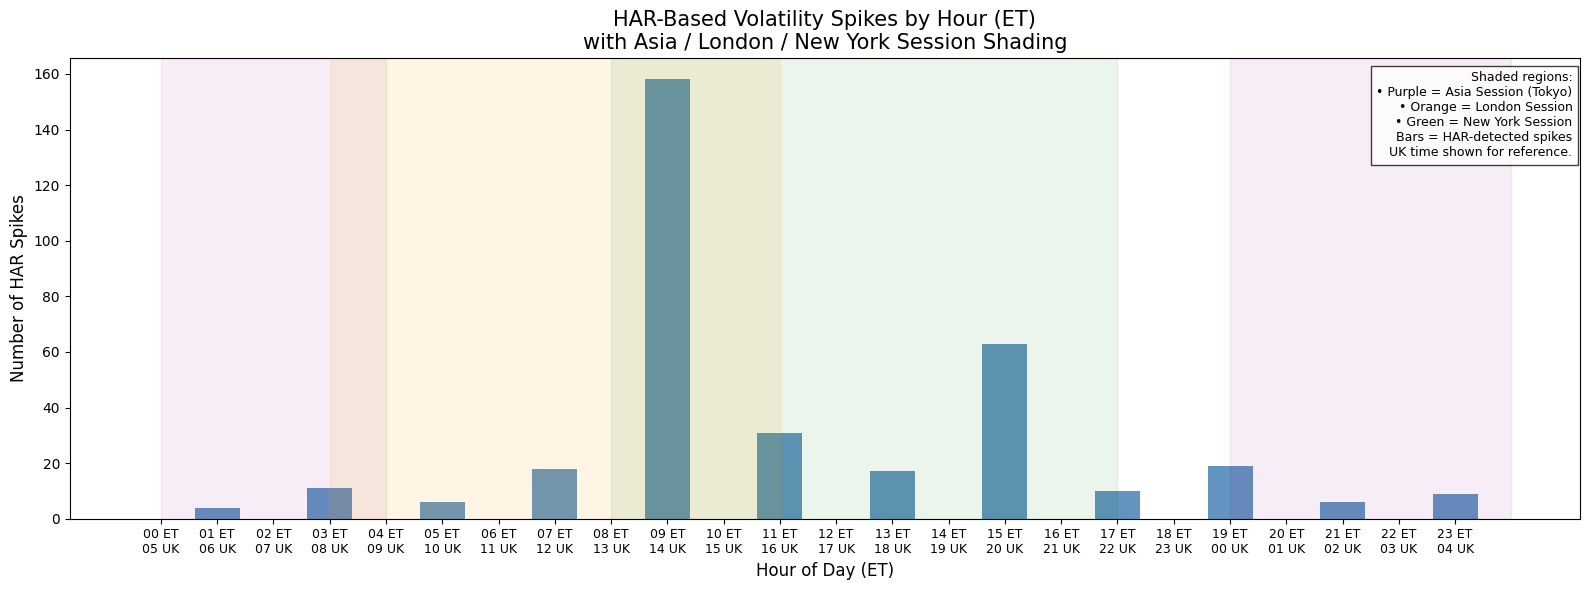

In [170]:
# ---------------------------------------------------
# 1. Extract hour-of-day for HAR spike bars
# ---------------------------------------------------
har_out['hour'] = har_out.index.hour

# Count spikes per hour (ET timezone)
har_spike_hours = (
    har_out[har_out['spike_HAR'].fillna(False)]
    .groupby('hour')
    .size()
    .reindex(range(24), fill_value=0)
)

# Convert ET → UK for display
uk_hours = [(h + 5) % 24 for h in har_spike_hours.index]  # approx ET+5


# ---------------------------------------------------
# 2. Plot with shading
# ---------------------------------------------------
plt.figure(figsize=(16,6))

# Blue bars
plt.bar(
    har_spike_hours.index,
    har_spike_hours.values,
    color='steelblue',
    alpha=0.85,
    label="HAR spike count"
)


# ---------------------------------------------------
# Session shading (ET)
# ---------------------------------------------------

# Asia Session: 19:00–04:00 ET
plt.axvspan(19, 24, color='purple', alpha=0.07)
plt.axvspan(0, 4, color='purple', alpha=0.07)

# London Session: 03:00–11:00 ET
plt.axvspan(3, 11, color='orange', alpha=0.10)

# New York Session: 08:00–17:00 ET
plt.axvspan(8, 17, color='green', alpha=0.08)


# ---------------------------------------------------
# X-axis labels (ET hours with UK hours below)
# ---------------------------------------------------
plt.xticks(
    har_spike_hours.index,
    [f"{h:02d} ET\n{uk_hours[h]:02d} UK" for h in har_spike_hours.index],
    fontsize=9
)


# ---------------------------------------------------
# Title, labels, legend text
# ---------------------------------------------------
plt.title("HAR-Based Volatility Spikes by Hour (ET)\nwith Asia / London / New York Session Shading",
          fontsize=15)

plt.xlabel("Hour of Day (ET)", fontsize=12)
plt.ylabel("Number of HAR Spikes", fontsize=12)

# Legend box as text (top-right)
plt.gca().text(
    0.995, 0.97,
    "Shaded regions:\n"
    "• Purple = Asia Session (Tokyo)\n"
    "• Orange = London Session\n"
    "• Green = New York Session\n"
    "Bars = HAR-detected spikes\n"
    "UK time shown for reference.",
    ha='right', va='top',
    fontsize=9,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.75),
    transform=plt.gca().transAxes
)

plt.tight_layout()
plt.show()


In [171]:
def extract_har_cooloff(har_out, z_col='z_resid', spike_col='spike_HAR',
                        spike_z=2.5, cool_z=1.0, timeframe_min=120):

    z = har_out[z_col]
    spikes = har_out[spike_col].fillna(False)
    idx = har_out.index
    n = len(har_out)

    episodes = []
    i = 0

    while i < n:
        if not spikes.iloc[i]:
            i += 1
            continue

        # spike detected
        start_idx = i
        start_time = idx[start_idx]
        start_z = z.iloc[start_idx]
        direction = "up" if start_z > 0 else "down"

        # walk forward to find cool-off
        j = i
        while j < n:
            if abs(z.iloc[j]) <= cool_z:
                break
            j += 1

        end_idx = j if j < n else n-1
        end_time = idx[end_idx]
        end_z = z.iloc[end_idx]

        bars = end_idx - start_idx + 1
        hours = bars * (timeframe_min / 60)

        episodes.append({
            "start": start_time,
            "start_z": float(start_z),
            "direction": direction,
            "end": end_time,
            "end_z": float(end_z),
            "bars_to_cool": int(bars),
            "hours_to_cool": float(hours)
        })

        i = end_idx + 1

    return pd.DataFrame(episodes)


# ---- RUN IT ----
episodes_har_simple = extract_har_cooloff(har_out)

print("Cool-off episodes detected:", len(episodes_har_simple))
episodes_har_simple.head(10)


Cool-off episodes detected: 319


,start,start_z,direction,end,end_z,bars_to_cool,hours_to_cool
0,2012-02-03 09:59:00,2.524208,up,2012-02-03 11:59:00,0.754312,2,4.0
1,2012-02-09 17:59:00,-2.655016,down,2012-02-09 19:59:00,-0.751365,2,4.0
2,2012-02-20 21:59:00,3.130657,up,2012-02-21 01:59:00,-0.101291,3,6.0
3,2012-02-29 11:59:00,2.809417,up,2012-02-29 13:59:00,0.755852,2,4.0
4,2012-04-03 15:59:00,2.785416,up,2012-04-03 19:59:00,-0.266999,3,6.0
5,2012-04-06 09:59:00,3.066935,up,2012-04-06 11:59:00,-0.614342,2,4.0
6,2012-04-23 19:59:00,-2.544748,down,2012-04-23 21:59:00,-0.234037,2,4.0
7,2012-04-30 19:59:00,-2.602288,down,2012-05-01 01:59:00,0.330494,4,8.0
8,2012-05-03 19:59:00,-2.660504,down,2012-05-03 21:59:00,-0.560397,2,4.0
9,2012-05-04 09:59:00,2.585581,up,2012-05-04 13:59:00,0.398936,3,6.0


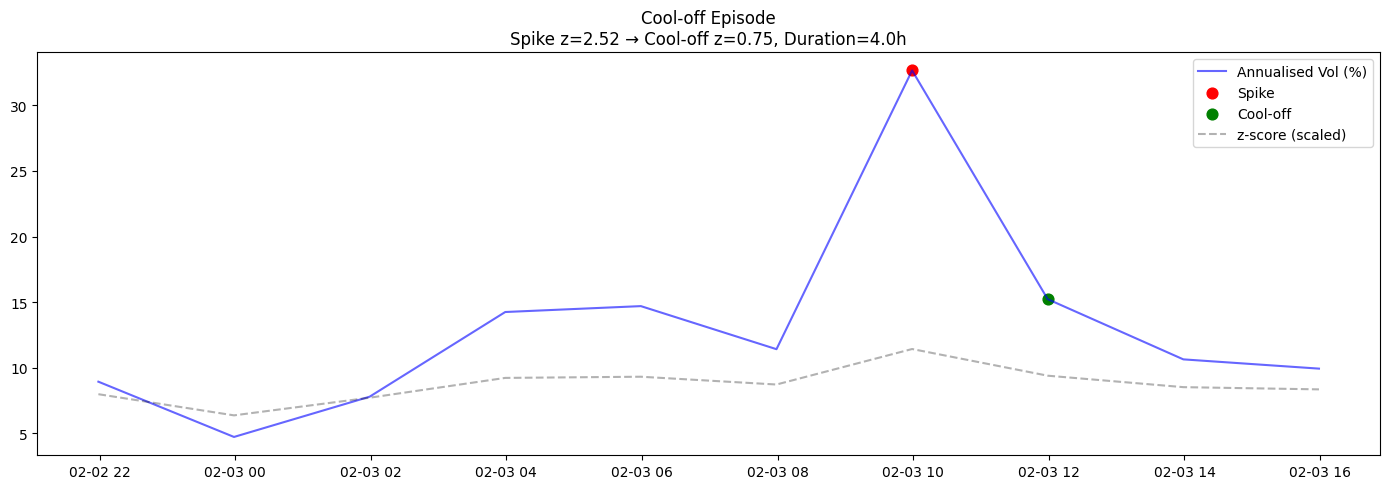

In [172]:
def plot_one_cooloff(har_out, ep, z_col='z_resid', vol_col='vol_ann_pct'):
    s = ep['start']; e = ep['end']
    mask = (har_out.index >= s - pd.Timedelta(hours=12)) & (har_out.index <= e + pd.Timedelta(hours=12))

    plt.figure(figsize=(14,5))

    # 1. Annualised volatility line
    plt.plot(har_out.index[mask], har_out[vol_col][mask],
             color='blue', alpha=0.6, label='Annualised Vol (%)')

    # 2. Scatter at spike start
    plt.scatter(s, har_out.loc[s, vol_col], color='red', s=60, label='Spike')

    # 3. Scatter at cool-off end
    plt.scatter(e, har_out.loc[e, vol_col], color='green', s=60, label='Cool-off')

    # 4. z-score plot
    z = har_out[z_col][mask]
    plt.plot(har_out.index[mask], z * z.std() + har_out[vol_col].mean(),
             color='black', linestyle='--', alpha=0.3, label='z-score (scaled)')

    # 5. Title
    plt.title(
        f"Cool-off Episode\n"
        f"Spike z={ep['start_z']:.2f} → Cool-off z={ep['end_z']:.2f}, "
        f"Duration={ep['hours_to_cool']:.1f}h"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


# ---- plot the first episode ----
plot_one_cooloff(har_out, episodes_har_simple.iloc[0])


In [176]:
'''Hybrid Detector - ALL in one
1) AR1 detector
2) HAR detector
3) Jump of 147%'''

'Hybrid Detector - ALL in one\n1) AR1 detector\n2) HAR detector\n3) Jump of 147%'

AR spikes:   552
HAR spikes:  379
ABS spikes:  1525
HYBRID:      1668

Last 8 rows:
                       vol_2h      logv  pred_logv_ar  z_resid_ar  \
EndDateTime                                                         
2021-12-31 01:59:00  0.000715 -7.243550     -7.649852    1.022335   
2021-12-31 03:59:00  0.001376 -6.588877     -7.101996    1.290052   
2021-12-31 05:59:00  0.001340 -6.615388     -6.669696    0.136598   
2021-12-31 07:59:00  0.001398 -6.572799     -6.687202    0.287815   
2021-12-31 09:59:00  0.001904 -6.263969     -6.659080    0.993883   
2021-12-31 11:59:00  0.002734 -5.901892     -6.455150    1.391345   
2021-12-31 13:59:00  0.000767 -7.173398     -6.216061   -2.402450   
2021-12-31 15:59:00  0.000599 -7.420399     -7.055672   -0.910877   

                     pred_logv_har  z_resid_har  spike_ar  spike_har  \
EndDateTime                                                            
2021-12-31 01:59:00      -7.135285    -0.241078     False      False   
2021-12-3

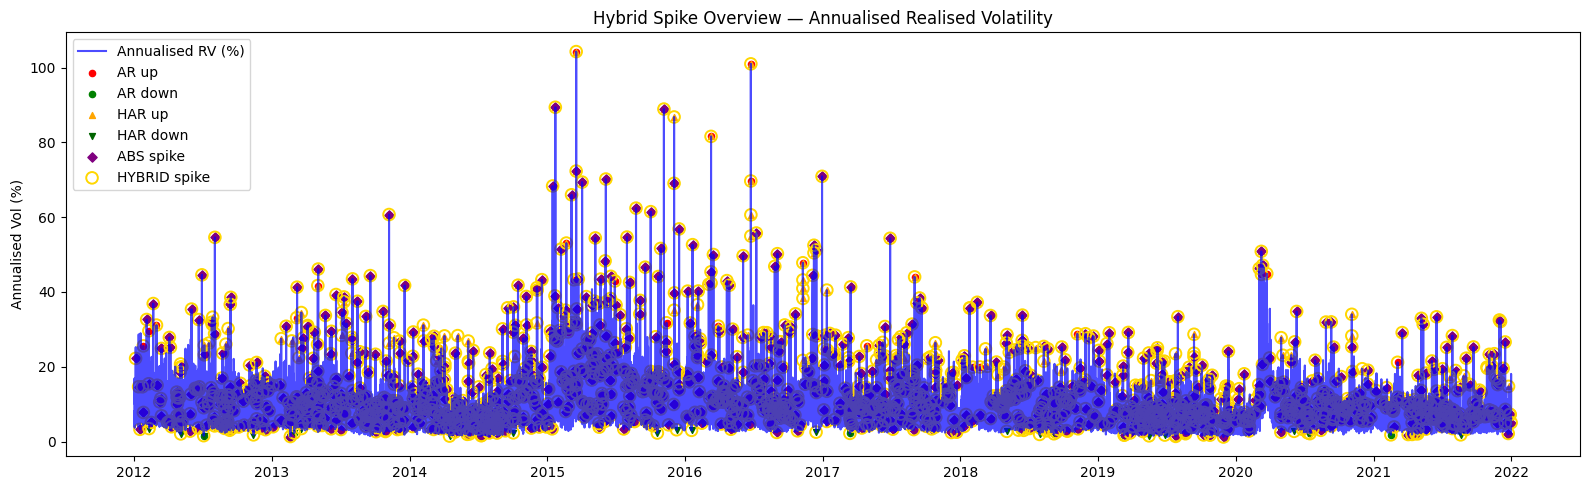

In [186]:
# ============================
# HYBRID SPIKE PIPELINE (FULL)
# ============================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ---------------------------
# 0. CONFIG / HYPERPARAMETERS
# ---------------------------
PERYEAR = 4380               
AR_Z_THR = 2.5               
HAR_Z_THR = 2.5               

# ⭐ CORRECT ABS THRESHOLDS (your 149.6% logic)
ABS_UP_FACTOR = 2.496     # +149.6% explosion
ABS_DOWN_FACTOR = 0.401   # -59.9% collapse

ROLL_STD_AR = 500
ROLL_STD_HAR = 1500

# HAR windows (in 2h bars)
D_BARS = 12
W_BARS = 60
M_BARS = 264

# ---------------------------
# 1. LOAD / PREP dataframe
# ---------------------------
if 'CC_120m_rvol' in globals():
    df = CC_120m_rvol.copy()
elif 'df' in globals():
    df = df.copy()
else:
    raise RuntimeError("Provide `CC_120m_rvol` or `df`.")

# ensure datetime index
if not isinstance(df.index, pd.DatetimeIndex):
    if 'DateTime' in df.columns:
        df['DateTime'] = pd.to_datetime(df['DateTime'])
        df = df.set_index('DateTime')
    elif 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')
    else:
        raise RuntimeError("Dataframe must have a DatetimeIndex or DateTime/date column.")

df = df.sort_index()

# ---------------------------
# 2. PREPARE log-vol series
# ---------------------------
rv_ann = pd.to_numeric(df['RVol_120min_Close-to-Close'], errors='coerce') / 100.0

# per-2h vol (fraction)
df['vol_2h'] = rv_ann / np.sqrt(PERYEAR)

# log-vol used for modeling
df['logv'] = np.log(df['vol_2h'].clip(lower=1e-12))

# annualised % (nice for plots)
df['vol_ann_pct'] = df['vol_2h'] * np.sqrt(PERYEAR) * 100.0

# ---------------------------
# 3. AR(1) MODEL
# ---------------------------
x = df['logv']
x_lag = x.shift(1)
mask = (~x.isna()) & (~x_lag.isna())

X_ar = sm.add_constant(x_lag[mask])
y_ar = x[mask]
ar_model = sm.OLS(y_ar, X_ar).fit()

df['pred_logv_ar'] = ar_model.predict(sm.add_constant(x_lag))
df['resid_ar'] = df['logv'] - df['pred_logv_ar']

df['resid_ar_sd'] = df['resid_ar'].rolling(
    ROLL_STD_AR, min_periods=max(20, ROLL_STD_AR//10)
).std().shift(1)

df['z_resid_ar'] = df['resid_ar'] / df['resid_ar_sd']
df['spike_ar'] = df['z_resid_ar'].abs() > AR_Z_THR

# ---------------------------
# 4. HAR MODEL
# ---------------------------
def build_har_X(logv):
    D = logv.rolling(D_BARS, min_periods=max(3, D_BARS//3)).mean().shift(1)
    W = logv.rolling(W_BARS, min_periods=max(5, W_BARS//3)).mean().shift(1)
    M = logv.rolling(M_BARS, min_periods=max(10, M_BARS//3)).mean().shift(1)
    X = pd.concat([D, W, M], axis=1)
    X.columns = ['D','W','M']
    return X

X_har = build_har_X(df['logv'])
panel = pd.concat([df['logv'], X_har], axis=1).dropna()

y_har = panel['logv']
Xmat_har = sm.add_constant(panel[['D','W','M']])
har_model = sm.OLS(y_har, Xmat_har).fit()

df.loc[panel.index, 'pred_logv_har'] = har_model.predict(Xmat_har)
df['resid_har'] = df['logv'] - df['pred_logv_har']

df['resid_har_sd'] = df['resid_har'].rolling(
    ROLL_STD_HAR, min_periods=max(50, ROLL_STD_HAR//10)
).std().shift(1)

df['z_resid_har'] = df['resid_har'] / df['resid_har_sd']
df['spike_har'] = df['z_resid_har'].abs() > HAR_Z_THR

# ---------------------------
# 5. ⭐ CORRECT ABS SPIKE DETECTOR
# ---------------------------
# Upward spike: vol_now > 2.496 * vol_prev
df['spike_abs_up'] = df['vol_2h'] > df['vol_2h'].shift(1) * ABS_UP_FACTOR

# Downward spike: vol_now < 0.401 * vol_prev
df['spike_abs_down'] = df['vol_2h'] < df['vol_2h'].shift(1) * ABS_DOWN_FACTOR

df['spike_abs'] = df['spike_abs_up'] | df['spike_abs_down']

# diagnostics
df['pct_vs_prev'] = (df['vol_2h'] / df['vol_2h'].shift(1) - 1.0) * 100.0

# ---------------------------
# 6. HYBRID FLAG (OR of all)
# ---------------------------
df['spike_hybrid'] = df[['spike_ar', 'spike_har', 'spike_abs']].any(axis=1)
df['direction'] = np.where(df['resid_ar'] > 0, 'up', 'down')

# ---------------------------
# 7. DIAGNOSTICS
# ---------------------------
print("AR spikes:  ", df['spike_ar'].sum())
print("HAR spikes: ", df['spike_har'].sum())
print("ABS spikes: ", df['spike_abs'].sum())
print("HYBRID:     ", df['spike_hybrid'].sum())

print("\nLast 8 rows:")
print(df[['vol_2h','logv','pred_logv_ar','z_resid_ar',
          'pred_logv_har','z_resid_har','spike_ar','spike_har',
          'spike_abs','spike_hybrid']].tail(8))

# ---------------------------
# 8. PLOT: Hybrid Overview
# ---------------------------
def plot_hybrid_overview(df):

    plt.figure(figsize=(16,5))
    t = df.index

    # main vol series
    plt.plot(t, df['vol_ann_pct'], color='blue', alpha=0.7, label='Annualised RV (%)')

    # AR spikes
    ar_up = df['spike_ar'] & (df['resid_ar'] > 0)
    ar_dn = df['spike_ar'] & (df['resid_ar'] < 0)
    plt.scatter(t[ar_up], df['vol_ann_pct'][ar_up], color='red', s=20, label='AR up')
    plt.scatter(t[ar_dn], df['vol_ann_pct'][ar_dn], color='green', s=20, label='AR down')

    # HAR spikes (orange up, dark green down)
    har_up = df['spike_har'] & (df['resid_har'] > 0)
    har_dn = df['spike_har'] & (df['resid_har'] < 0)
    plt.scatter(t[har_up], df['vol_ann_pct'][har_up], color='orange', marker='^', s=18, label='HAR up')
    plt.scatter(t[har_dn], df['vol_ann_pct'][har_dn], color='darkgreen', marker='v', s=18, label='HAR down')

    # ABS spikes (purple)
    plt.scatter(t[df['spike_abs']], df['vol_ann_pct'][df['spike_abs']], 
                color='purple', marker='D', s=22, label='ABS spike')

    # HYBRID spikes (yellow circle outline)
    plt.scatter(t[df['spike_hybrid']], df['vol_ann_pct'][df['spike_hybrid']],
                facecolors='none', edgecolors='gold', s=70, linewidths=1.4,
                label='HYBRID spike')

    plt.title("Hybrid Spike Overview — Annualised Realised Volatility")
    plt.ylabel("Annualised Vol (%)")
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

plot_hybrid_overview(df)

# persist
CC_120m_rvol = df.copy()
